# NAFNet-GoPro-width32 — DIMER guided notebook: image deblurring and restoration fine-tuning (standalone)

[![GitHub](https://img.shields.io/badge/GitHub-181717?style=flat&logo=github&logoColor=white)](https://github.com/kurtvalcorza/nafnet-deblurring-pipeline) [![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/kurtvalcorza/nafnet-deblurring-pipeline/blob/main/tutorials/nafnet_deblurring_colab.ipynb) [![Upstream](https://img.shields.io/badge/Upstream-megvii--research%2FNAFNet-181717?style=flat&logo=github&logoColor=white)](https://github.com/megvii-research/NAFNet) [![License](https://img.shields.io/badge/License-MIT%20%2B%20Apache--2.0-blue.svg)](https://github.com/megvii-research/NAFNet/blob/main/LICENSE)

**Profile:** `E2E`  
**Mode:** `GUIDED`  
**Notebook specification:** DIMER Notebook Specification 2.2 — **standalone** (§4)  
**Capability:** single-image deblurring with a 17.1 M-parameter NAFNet (GoPro-trained, width 32), PSNR/SSIM evaluation against classical baselines, and bounded restoration fine-tuning to a new blur distribution

**This notebook is standalone.** Section 2 carries the repository's package (4 modules under `src/nafnet_deblurring_pipeline/`, at revision `31db8bb39122`), the upstream NAFNet architecture files verbatim (`megvii-research/NAFNet` at `2b4af71ebe09`), the stage runner, the hash-locked requirements (38 packages), the pinned checkpoint manifest and the licences, and verifies every carried file against its SHA-256 before use, so the notebook keeps working after export even if the repository changes or disappears. Nothing is installed into the notebook kernel: a pinned `uv` (checked by size and SHA-256) builds an isolated Python environment from the lock with `--require-hashes`, and every stage runs there in its own process, so the hosted runtime's own packages are never replaced and no restart is needed. Its only external dependencies are PyPI, the managed CPython build that `uv` downloads, and one 68.7 MB checkpoint fetched from a Hugging Face mirror and refused unless its size and SHA-256 equal the pinned values. The sample photographs ship inside a hash-locked wheel, so no data download is needed. It was generated by `tools/build_notebook.py` (build_notebook.py/3.0-nafnet); edit the repository and regenerate rather than editing cells.

**Run all:** Selecting **Run all** in a fresh Linux runtime (a Colab or Kaggle **T4 GPU** is the documented runtime; a CPU-only runtime also completes, more slowly) builds an isolated Python environment from the carried hash-locked requirements (torch, numpy, pillow, safetensors, scikit-image and their dependencies) without touching the notebook kernel's own packages, then runs each stage below in its own process: it fetches the 68.7 MB NAFNet-GoPro-width32 checkpoint from a Hugging Face mirror and refuses it unless its size and SHA-256 equal the pinned values, unpickles it once with `weights_only=True` and converts it to safetensors; builds a sample of 60 blurred/sharp pairs from eleven public-domain photographs with seeded synthetic motion blur, validates it and splits it by photograph (48 training / 12 test pairs); scores the blurred input, unsharp masking, oracle Wiener deconvolution and the pretrained network on the test pairs with PSNR and SSIM; fine-tunes the decoder half of the network for 300 steps; scores the exported safetensors artifact in a fresh process beside every baseline; reloads it in a second fresh process and checks that it reproduces the trained model; and deblurs two new images. The default path needs no repository clone, no DIMER worker or service, no credential, no upload dialog, no configuration edit and no runtime restart (NOTEBOOK_SPEC 2.2 §5). Its duration on a T4 has not been recorded yet; see the Prerequisites for what has been measured.

**Bring Your Own Data:** After the canonical path completes, set `USE_BYOD = True` in Section 10 to run the same stages on your own images, supplied as a zip (or a directory already in the runtime, via `BYOD_PATH`). With `sharp/` and `blurred/` folders whose files share a name (paired data, at least four pairs from different scenes) the BYOD branch validates, splits by image, scores the same baselines, fine-tunes from the pretrained weights, evaluates, exports and reloads its own artifact and writes PNGs, a metrics CSV and a JSON record. With blurred images only (unpaired data) it validates them and deblurs them with the pretrained and the adapted model; no PSNR or SSIM is possible without a reference. The schema, ceilings and privacy guidance are stated in the Prerequisites and in Section 10; uploaded files stay inside this runtime. BYOD is optional and never part of the default path.

NAFNet (Chen et al., 2022) is a U-shaped convolutional network for image restoration built without nonlinear activation functions: each block uses layer normalisation, depthwise convolution, a *SimpleGate* (one half of the channels multiplies the other) and a simplified channel attention. The checkpoint used here was trained by the authors on the GoPro dataset, whose blurred images are averages of consecutive frames from a moving handheld camera. The network takes a blurred RGB image and returns a restored image of the same size; it predicts a residual that is added to its input.

Two properties shape this notebook. **Restoration has a reference only when you make the blur yourself**, so the sample degrades sharp photographs with known synthetic motion blur and the metrics compare against the sharp originals; a real blurred photograph (Section 8) has no reference and gets no metric. **A model trained on one blur distribution meets another here**: GoPro blur comes from real camera motion, the sample's blur from straight-line kernels plus noise, and the bounded fine-tuning in Section 6 adapts the decoder half of the network to that new distribution. Every number is tutorial evidence on synthetic data, not a benchmark.

**Learning objectives:** by the end of this notebook you will be able to —

1. **Explain** how a blurred/sharp pair is synthesised (motion kernel, noise, quantisation) and why the split is drawn by photograph rather than by crop (Section 4).
2. **Diagnose** an invalid input from a validation refusal before any model runs (Section 4).
3. **Interpret** PSNR and SSIM, and **compare** a deep network with the blurred input, a blind classical filter and a non-blind oracle (Section 5).
4. **Identify** which parameters a bounded fine-tuning trains and which it freezes, and **explain** why the training loss is not evidence of quality (Section 6).
5. **Compare** the adapted and the pretrained model on identical held-out pairs and **distinguish** a paired gain from a re-draw of randomness (Section 7).
6. **Verify** that an exported artifact, reloaded from files, reproduces the trained model, and **explain** why a real blurred photograph gets no PSNR (Section 8).
7. **Predict**, run and **explain** the effect of changing one thing, the trainable scope, in an optional activity (Section 9).
8. **Apply** the same workflow to your own paired or unpaired images (Section 10) and **write** an evidence-based conclusion (Conclusion).

**This notebook does not demonstrate:** the other NAFNet checkpoints (SIDD denoising, REDS, width 64, NAFSSR stereo super-resolution), training from scratch, the GoPro benchmark itself (its numbers in the upstream README are not reproduced or quoted as notebook measurements), real-blur evaluation with ground truth, video deblurring, defocus or spatially varying blur models, perceptual metrics (LPIPS, FID) and human rating. The repository exposes none of these.

## How to use this notebook

**Who this notebook is for.** Learners who can open a hosted notebook (Google Colab or Jupyter), run cells in order and read short Python, and who want to see how an image-restoration network is evaluated honestly and adapted to new data. No prior experience with deblurring is assumed: each term is explained where it is first needed, and the glossary below collects them. A T4 GPU is the documented runtime; a CPU-only runtime completes but the fine-tuning stages take longer. The **Prerequisites** give the details.

**Running it.** In Colab, choose *Runtime → Change runtime type → T4 GPU*, then *Runtime → Run all*. The default path needs no edit, no upload, no account, no token and no runtime restart. Sections 1–3 build an isolated environment from hash-locked packages and fetch the checkpoint, so they take the longest before any model runs; read ahead while they finish, or run the notebook one cell at a time with *Shift + Enter*.

**Where the code runs.** The notebook kernel installs nothing and imports no model library. Each learner cell calls `run_stage('…')`, which runs one stage of the carried stage runner in its own process with the isolated environment's Python, streams what it prints, and stops the notebook with the stage's own error message if it fails. Stages hand results to each other only through files in the run directory — the verified checkpoint, the dataset digest, JSON records and the exported artifact — and memory is released when each stage ends.

**Two kinds of cell.** *Learner cells* (Sections 4–10) are the machine-learning workflow; each runs one stage and prints compact dictionaries and a comparison image for you to read. *Infrastructure cells* (Sections 1–3: the runtime check, the carried code, the isolated install and the checkpoint staging) are collapsed and titled **Infrastructure**. You may run them without studying their implementation: they exist for reproducibility and provenance, not as prerequisite machine-learning knowledge. Open one with *Show code* if you are curious.

**Form controls.** Some learner cells start with fields that Colab renders as a form: `STEPS`, `LEARNING_RATE`, `BATCH_SIZE` and `TRAINABLE_SCOPE` (Section 6); `RUN_ACTIVITY` and `ACTIVITY_SCOPE` (Section 9); and `USE_BYOD`, `BYOD_PATH` and `BYOD_STEPS` (Section 10). Leave them at their defaults for the first run: the notes and sample answers describe the default path.

**Section tags.** Each numbered heading carries one tag. **[Concept]** — what the model does and why. **[Evaluation practice]** — how the evidence is produced and how to read it. **[Engineering]** — reproducibility, provenance and packaging.

**Predict, then check.** Before each principal result a **Predict before running** prompt asks you to commit to an expectation; after it, **What to notice** describes normal output and a collapsed **Check your reasoning** answer follows each checkpoint. Write your own answer first, then open it. Exact numbers vary with the runtime (GPU or CPU) and the library versions, so the notes describe the shape of a normal result rather than fixed values.

## The task: Input → Model/System → Output

| Stage | Input | Model / system | Output |
|---|---|---|---|
| **Restoration** | a blurred RGB image (uint8, H × W × 3) | NAFNet-GoPro-width32: intro convolution → 4 encoder levels → middle block → 4 decoder levels with skip connections → ending convolution, plus the input (a residual) | a restored RGB image of the same size |
| **Adaptation** | blurred/sharp training pairs | random 256 × 256 crops through the network; the PSNR loss updates only the decoder half (upsampling layers, decoder blocks, ending convolution) | a safetensors artifact with a manifest |
| **Evaluation** | held-out blurred/sharp pairs from photographs never used in training | the blurred input, unsharp masking, oracle Wiener deconvolution, the pretrained and the adapted network | PSNR (dB) and SSIM per pair and on average |

The network never sees the blur kernel. Only the Wiener baseline is given the true kernel, as an oracle no real deblurrer has.

## Roadmap

| Section | Tag | What happens | What you read |
|---|---|---|---|
| 1. Check the runtime | [Engineering] | Linux, accelerator and disk checked; a fresh run directory | the accelerator |
| 2. Carry the code, install the runtime | [Engineering] | carried files verified; an isolated hash-locked environment | versions |
| 3. Pin, verify and convert the checkpoint | [Engineering] | 68.7 MB `.pth` checked, unpickled safely, converted | digests |
| 4. Sample pairs, validation and split | [Evaluation practice] | 60 synthetic pairs validated and split by photograph | split, refusals |
| 5. Baselines and the pretrained model | [Evaluation practice] | four methods scored on the test pairs | the baseline table |
| 6. Bounded fine-tuning | [Concept] | the decoder half trained for 300 steps | trainable parameters, loss |
| 7. Held-out comparison | [Evaluation practice] | adapted vs everything else on identical pairs | the principal result |
| 8. Fresh reload and new images | [Engineering] | artifact reloaded in a new process; two unseen images | reload parity |
| 9. Optional activity | [Concept] | change the trainable scope (off by default) | your comparison |
| 10. Bring your own data | [Engineering] | the same stages on your images (off by default) | your results |
| Troubleshooting | [Engineering] | common hosted-runtime failures | when something fails |
| Interpretation and conclusion | [Evaluation practice] | limits and an evidence-based conclusion | your conclusion |

**Fast path.** Short on time? Run all, then read Sections 5 and 7 and the conclusion: they carry the principal results. The canonical path ends with Section 8; Sections 9 and 10 change nothing unless you switch them on.

<details>
<summary><strong>Glossary</strong> — open when a term is unfamiliar</summary>

| Term | Meaning in this notebook |
|---|---|
| **Deblurring / restoration** | Estimating the sharp image from a degraded one. |
| **Blur kernel (point-spread function)** | The small image that describes how one point of light is smeared; a blurred image is the sharp image convolved with it. |
| **Motion blur** | Blur from movement during exposure; here a straight line of length 9..21 px at a random angle. |
| **Convolution** | Replacing each pixel by a weighted sum of its neighbours, the weights given by the kernel. |
| **Noise, quantisation** | Random per-pixel error (sigma 0.01 of the range here) and rounding to whole 8-bit values. |
| **Pair** | A blurred image and the sharp image it was made from. |
| **Crop** | A 256 × 256 window cut from a photograph; several crops come from each photograph. |
| **Split by photograph** | All crops of one photograph go to the same side of the train/test split, so test scenes are never seen in training. |
| **PSNR** | Peak signal-to-noise ratio in dB: 10·log10(255² / mean squared error). Higher is better; +1 dB ≈ 21 % less squared error. |
| **SSIM** | Structural similarity in −1..1, comparing local means, contrasts and correlations; 1 means identical structure. |
| **Identity baseline** | Using the blurred input as the answer: the floor every method must beat. |
| **Unsharp masking** | Adding back the difference between an image and a blurred copy of it; blind, cheap, does not undo motion blur. |
| **Wiener deconvolution** | Inverting a *known* blur in the frequency domain while damping noise; here given the true kernel (an oracle). |
| **NAFNet** | Nonlinear Activation Free Network: a U-shaped restoration network whose blocks use multiplication (SimpleGate) instead of activation functions. |
| **Encoder / decoder** | The half of the U that shrinks the image into features / the half that expands them back to an image. |
| **TLC (NAFNetLocal)** | Test-time local converter: replaces global average pooling by pooling over a window sized from the training crops, as in the upstream GoPro test configuration. Identical to global pooling for images up to 384 px. |
| **Pretrained** | The authors' GoPro weights, unchanged. |
| **Fine-tuning** | Continuing gradient training on new data; here only some parameters are updated (the others are *frozen*). |
| **Trainable scope** | Which parts are updated: `decoder` (default), `decoder+middle` or `all`. |
| **PSNR loss** | The upstream training loss: minus the PSNR of the batch, so lowering it raises training-batch PSNR. |
| **Paired comparison** | Two methods scored on exactly the same inputs, so differences are not random re-draws. |
| **Artifact** | The exported `model.safetensors` + `manifest.json`. |
| **safetensors / pickle** | A tensor-only file format that cannot run code / Python's object format, which can. |
| **Digest (SHA-256)** | A fingerprint of a file's bytes; a single changed byte changes it. |
| **Hash-locked environment** | A separate Python environment built from a requirements file that pins every package to one version and one set of SHA-256 digests. |
| **Stage** | One step of the workflow run as its own process by `run_stage`. |
| **BYOD** | Bring Your Own Data: an optional switch to run the same workflow on your own images. |

</details>

## Prerequisites

- **Runtime:** a fresh supported **Linux x86_64** runtime — Google Colab or Kaggle with a **T4 GPU** is the documented runtime; a CPU-only runtime also completes. The kernel's own Python version does not matter: the notebook installs nothing into it and runs every stage with CPython 3.12.12 in an isolated environment built from 38 hash-locked packages (torch 2.14.0, whose Linux wheel is the CUDA 13.0 build and also runs on a CPU). Everything runs in float32; cuDNN is set to deterministic kernels. About 9 GB of disk is needed for the isolated environment and 0.2 GB for the checkpoint and its converted copy.
- **Measured timings (estimates for your runtime):** no hosted T4 run of this notebook has been recorded yet. On the 4-core CPU container used during development, measured while it was otherwise idle, one fine-tuning step at the defaults (batch 4, 256 × 256 crops, decoder scope) of a full-width network took about 2.3 s, so the 300-step fine-tuning would take roughly 12 minutes on a comparable CPU and the optional activity as long again; a T4 is expected to be much faster. Treat these as estimates, not measurements of your run.
- **Knowledge:** basic Python and NumPy arrays (H × W × 3, uint8); what a convolution does; the idea of training by gradient descent and of a held-out test set. Image-restoration terms are explained where they are first used and collected in the glossary.
- **Weights and trust boundary:** the upstream checkpoint is a PyTorch pickle (`.pth`). The notebook refuses it unless its size and SHA-256 equal the pinned values, reads it once with `torch.load(..., weights_only=True)` (tensors and plain containers only) and converts it to safetensors; every later stage loads the safetensors file. The pinned SHA-256 comes from third-party records of the upstream Google Drive file, not from the authors; `docs/WEIGHTS.md` in the repository explains that chain and its residual trust gap. No code from the Hugging Face mirror is executed: the architecture is the upstream source carried verbatim in Section 2. NAFNet is MIT-licensed; its BasicSR-derived parts are Apache-2.0.
- **Data contract:** a record is `{id, source, blurred, sharp}` — two uint8 RGB arrays of identical size, each side 64..1024 px (larger images are refused, never resized silently); `source` groups the crops of one photograph so the split can keep them together. Greyscale is replicated to three channels and alpha is dropped, and both are reported. Validation is structural: it cannot tell whether a pair shows the same scene.
- **Sample data:** eleven photographs that ship inside the hash-locked `scikit-image` 0.26.0 wheel (public domain or CC0 according to its data documentation), each pinned by size and SHA-256 and read as a file. `skimage` is never imported. Because they are well-known test images, overlap with the data behind other models cannot be ruled out; GoPro, the checkpoint's training set, consists of video frames and does not contain them as far as its description shows.
- **Privacy:** Do not upload confidential or restricted data to a hosted runtime unless you are authorized to process it there — photographs of identifiable people, medical images, licensed stock or client material are exactly that. The default path uploads nothing, and the BYOD branch keeps your files inside this runtime; nothing is sent to any service.
- **External access:** `huggingface.co` (no account or token), to fetch the 68.7 MB `megvii-research/NAFNet` checkpoint from the mirror named in the carried manifest, accepted only at the pinned size and SHA-256; PyPI (`files.pythonhosted.org`), for the pinned `uv` wheel and the 38 hash-locked packages; and the managed CPython build (python-build-standalone) that `uv` downloads for the isolated environment. No repository clone and no credentials are required; nothing is installed from this repository.

## 1. Check the runtime · [Engineering]

> **Infrastructure.** The code cells in Sections 1–3 are collapsed. You may run them without studying their implementation; they exist for reproducibility and provenance. The learning activities start in Section 4.

**Input:** a fresh hosted runtime. **System:** checks that it is Linux x86_64 with enough free disk, reports whether a CUDA GPU is present, and creates a new run directory. **Output:** the accelerator and the directories this run will use. Each run writes to a new directory under `outputs/nafnet_deblurring/`, so an earlier export cannot be mistaken for a current result. The verified checkpoint is kept in `weights/` and reused by a later run.

In [1]:
# @title Infrastructure: check the runtime, accelerator and disk; create a fresh run directory
import hashlib
import json
import os
import platform
import shutil
import subprocess
import tempfile
import time
import uuid
from pathlib import Path

SESSION_START = time.perf_counter()
if platform.system() != 'Linux' or platform.machine() != 'x86_64':
    raise RuntimeError('This notebook needs a Linux x86_64 runtime (Google Colab or Kaggle; a T4 GPU is recommended): its locked environment is built for manylinux x86_64 wheels.')
try:
    gpu = subprocess.run(['nvidia-smi', '--query-gpu=name,memory.total', '--format=csv,noheader'], capture_output=True, text=True)
    accelerator = gpu.stdout.strip() if gpu.returncode == 0 else ''
except FileNotFoundError:
    accelerator = ''
if not accelerator:
    accelerator = 'none (CPU only)'
    print('No CUDA GPU detected. The notebook still runs on the CPU, but the fine-tuning stages take much longer (see Prerequisites). For the documented runtime choose Runtime > Change runtime type > T4 GPU before Run all.')
STEM = 'nafnet_deblurring'
ROOT = Path.cwd() / 'outputs' / STEM / uuid.uuid4().hex[:12]
ROOT.mkdir(parents=True)
WEIGHTS = Path.cwd() / 'weights'
WEIGHTS.mkdir(exist_ok=True)
ENV_ROOT = Path(tempfile.gettempdir()) / (STEM + '_env_' + ROOT.name)
staged_gib = sum(p.stat().st_size for p in WEIGHTS.rglob('*') if p.is_file()) / 1024**3
need = {'weights': max(0.0, 0.2 - staged_gib), 'environment': 9.0}
free = {'weights': shutil.disk_usage(WEIGHTS).free / 1024**3, 'environment': shutil.disk_usage(tempfile.gettempdir()).free / 1024**3}
if os.stat(WEIGHTS).st_dev == os.stat(tempfile.gettempdir()).st_dev:
    short = free['weights'] < need['weights'] + need['environment']
else:
    short = free['weights'] < need['weights'] or free['environment'] < need['environment']
if short:
    raise RuntimeError(f'Not enough free disk: need about {need} GiB, free {free} GiB. Start a fresh runtime (see Troubleshooting).')
print({'accelerator': accelerator, 'kernel_python': platform.python_version(), 'run_directory': str(ROOT), 'weights': str(WEIGHTS), 'environment': str(ENV_ROOT), 'free_gib': {k: round(v, 1) for k, v in free.items()}})

{'accelerator': 'Tesla T4, 15360 MiB', 'kernel_python': '3.13.15', 'run_directory': '/content/outputs/nafnet_deblurring/832119f9a959', 'weights': '/content/weights', 'environment': '/tmp/nafnet_deblurring_env_832119f9a959', 'free_gib': {'weights': 193.2, 'environment': 193.2}}


**Expected result:** one dictionary naming the accelerator (for example `Tesla T4, 15360 MiB`, or `none (CPU only)` with a note that fine-tuning will be slower), the kernel's Python version, the run directory, the weights directory, the isolated environment's directory and the free disk. If the cell stops with a platform or disk message, see **Troubleshooting**.

## 2. Carry the code and install the locked runtime · [Engineering]

> **Infrastructure.** The next two code cells are collapsed. The first **is** the code this notebook runs, carried so that the notebook works on its own; the second builds the environment every stage runs in.

The first cell holds, as text, the files the workflow needs: the package's four modules under `src/nafnet_deblurring_pipeline/` (identity constants and checkpoint handling, the degradation model and validation, the metrics and baselines), the three upstream architecture files `NAFNet_arch.py`, `arch_util.py` and `local_arch.py` copied verbatim from `megvii-research/NAFNet` at `2b4af71ebe098a92a75910c233a3965a3e93ede4` with the upstream licence, the stage runner `tutorial_stages.py`, the hash-locked `requirements.txt` (38 packages), the checkpoint manifest and the repository licence. It writes each file into the run directory and checks its SHA-256 against `CARRIED_HASHES`, stopping on any mismatch; the package checks the three upstream files once more against their upstream digests before executing them. The repository's parity test (`tests/test_notebook_parity.py`) fails whenever the carried text and the repository diverge, so what runs here is what the repository tests. Nothing in this cell runs a model.

In [2]:
# @title Infrastructure: write and verify the carried package, stage runner, lock and manifests
CARRIED_FILES = {'src/nafnet_deblurring_pipeline/__init__.py': '"""DIMER pipeline for NAFNet-GoPro-width32 image deblurring (megvii-research/NAFNet).\n\nImporting the package imports numpy and Pillow only; torch and safetensors are imported inside the functions that\nneed them, so validation and refusals never load a model library.\n"""\n\nfrom .metrics import (\n    METRIC_DEFINITIONS,\n    classical_outputs,\n    gradient_energy,\n    paired_difference,\n    psnr,\n    score,\n    ssim,\n    tune_unsharp,\n    tune_wiener,\n    unsharp_mask,\n    wiener_deconvolve,\n)\nfrom .pipeline import (\n    ARCH_CONFIG,\n    ARTIFACT_FORMAT,\n    CHECKPOINT_BYTES,\n    CHECKPOINT_FILE,\n    CHECKPOINT_MIRRORS,\n    CHECKPOINT_SHA256,\n    MANIFEST_NAME,\n    MODEL_ID,\n    MODEL_KEY,\n    MODEL_LICENSE,\n    MODEL_REVISION,\n    MODEL_VARIANT,\n    PARAMETER_COUNT,\n    TRAINABLE_SCOPES,\n    UPSTREAM_ARCH_SHA256,\n    DeblurPipeline,\n    convert_checkpoint,\n    fetch_checkpoint,\n    load_architecture,\n    load_manifest,\n    verify_checkpoint,\n)\nfrom .samples import (\n    INPUT_SCHEMA,\n    MAX_SIDE,\n    MIN_PAIRS,\n    MIN_SIDE,\n    SAMPLE_IMAGES,\n    build_new_data,\n    build_sample_dataset,\n    dataset_manifest,\n    degrade,\n    motion_kernel,\n    read_byod,\n    split_by_source,\n    validate_records,\n)\n\n__all__ = [\n    "ARCH_CONFIG",\n    "ARTIFACT_FORMAT",\n    "CHECKPOINT_BYTES",\n    "CHECKPOINT_FILE",\n    "CHECKPOINT_MIRRORS",\n    "CHECKPOINT_SHA256",\n    "INPUT_SCHEMA",\n    "MANIFEST_NAME",\n    "MAX_SIDE",\n    "METRIC_DEFINITIONS",\n    "MIN_PAIRS",\n    "MIN_SIDE",\n    "MODEL_ID",\n    "MODEL_KEY",\n    "MODEL_LICENSE",\n    "MODEL_REVISION",\n    "MODEL_VARIANT",\n    "PARAMETER_COUNT",\n    "SAMPLE_IMAGES",\n    "TRAINABLE_SCOPES",\n    "UPSTREAM_ARCH_SHA256",\n    "DeblurPipeline",\n    "build_new_data",\n    "build_sample_dataset",\n    "classical_outputs",\n    "convert_checkpoint",\n    "dataset_manifest",\n    "degrade",\n    "fetch_checkpoint",\n    "gradient_energy",\n    "load_architecture",\n    "load_manifest",\n    "motion_kernel",\n    "paired_difference",\n    "psnr",\n    "read_byod",\n    "score",\n    "split_by_source",\n    "ssim",\n    "tune_unsharp",\n    "tune_wiener",\n    "unsharp_mask",\n    "validate_records",\n    "verify_checkpoint",\n    "wiener_deconvolve",\n]\n', 'src/nafnet_deblurring_pipeline/pipeline.py': '"""NAFNet-GoPro-width32 deblurring: identity, checkpoint acquisition and verification, the carried upstream\narchitecture, bounded fine-tuning, inference, and a safetensors artifact with a manifest.\n\nTrust boundary. The upstream checkpoint is a PyTorch pickle (``.pth``). It is refused unless its byte size and SHA-256\nmatch the pinned values, and it is then read with ``torch.load(..., weights_only=True)``, which restricts unpickling to\ntensors and primitive containers. It is unpickled once, converted to safetensors, and every later load uses the\nsafetensors file. Path-safe handling does not make an untrusted pickle safe; the pinned digest is what limits the\nbytes that reach ``torch.load``.\n\nArchitecture. ``NAFNet_arch.py``, ``arch_util.py`` and ``local_arch.py`` are carried verbatim from\n``megvii-research/NAFNet`` at ``MODEL_REVISION`` under ``third_party/nafnet/`` and verified against\n``UPSTREAM_ARCH_SHA256`` before they are executed. They import ``basicsr.*`` by absolute name; ``load_architecture``\nregisters empty ``basicsr`` package modules and a one-function ``basicsr.utils`` shim (``get_root_logger``, used only\nby an unused helper) so that none of upstream\'s training framework, OpenCV or LMDB dependencies is needed.\n\nEvery model-library import (torch, safetensors) is inside a function body: importing this module, validating data and\nrefusing a bad request never load torch.\n"""\n# ruff: noqa: E501  -- provenance strings and refusal messages are kept on one line\n\nfrom __future__ import annotations\n\nimport hashlib\nimport json\nimport platform\nimport sys\nimport time\nimport types\nimport urllib.error\nimport urllib.request\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nimport numpy as np\n\n# ---- identity (MOD1-MOD3) -------------------------------------------------------------------------------------------\nMODEL_ID = "megvii-research/NAFNet"\nMODEL_REVISION = "2b4af71ebe098a92a75910c233a3965a3e93ede4"\nMODEL_LICENSE = "MIT"\nMODEL_KEY = "nafnet-gopro-width32"\nMODEL_VARIANT = "NAFNet-GoPro-width32"\nUPSTREAM_REPOSITORY = "https://github.com/megvii-research/NAFNet"\nUPSTREAM_CHECKPOINT_LISTING = "readme.md (Results and Pre-trained Models table), Google Drive file id 1Fr2QadtDCEXg6iwWX8OzeZLbHOx2t5Bj"\nCHECKPOINT_FILE = "NAFNet-GoPro-width32.pth"\nCHECKPOINT_BYTES = 68671121\nCHECKPOINT_SHA256 = "19394e6155d12ef6371d1d57496f87f0ec88f92bdffa27c0792690722d5d1a5c"\n# Credential-free mirrors of the exact upstream bytes, tried in order. Each is accepted only when the downloaded bytes\n# match CHECKPOINT_BYTES and CHECKPOINT_SHA256, so a mirror can never substitute a different model (MOD8).\nCHECKPOINT_MIRRORS = (\n    {"provider": "huggingface", "repository": "nyanko7/nafnet-models", "url": "https://huggingface.co/nyanko7/nafnet-models/resolve/main/NAFNet-GoPro-width32.pth"},\n    {"provider": "huggingface", "repository": "mikestealth/nafnet-models", "url": "https://huggingface.co/mikestealth/nafnet-models/resolve/main/NAFNet-GoPro-width32.pth"},\n)\nARCH_CONFIG: dict[str, Any] = {"img_channel": 3, "width": 32, "middle_blk_num": 1, "enc_blk_nums": [1, 1, 1, 28], "dec_blk_nums": [1, 1, 1, 1]}\nTLC_TRAIN_SIZE = (1, 3, 256, 256)  # NAFNetLocal (test-time local converter) as in options/test/GoPro/NAFNet-width32.yml\nPARAMETER_COUNT = 17111907\nUPSTREAM_ARCH_SHA256 = {\n    "basicsr/models/archs/NAFNet_arch.py": "01b22270cc93f1bb90c0e3e4490e98b023fcf73f8552860b4a9ee880ce5c6967",\n    "basicsr/models/archs/arch_util.py": "5a11af2e7c2d7a7b57c1fbd7e19cf0a50b4b4e8c7ae7dd203a915d7a707e7005",\n    "basicsr/models/archs/local_arch.py": "c4df2ba4d896442a0f6ec984accd6e68f31edce3afdf066add202c25a0d1af26",\n}\nMANIFEST_NAME = "dimer-base-manifest.json"\nBASE_SAFETENSORS = "model.safetensors"\nARTIFACT_FORMAT = "dimer_nafnet_restoration_artifact"\nARTIFACT_FORMAT_VERSION = 1\nARTIFACT_WEIGHTS = "model.safetensors"\nARTIFACT_MANIFEST = "manifest.json"\n# Adaptation scopes (FT5): which top-level submodules receive gradient updates; everything else is frozen.\nTRAINABLE_SCOPES: dict[str, tuple[str, ...] | None] = {\n    "decoder": ("ups", "decoders", "ending"),\n    "decoder+middle": ("ups", "decoders", "ending", "middle_blks"),\n    "all": None,\n}\nDEFAULT_ARCH_DIR = Path(__file__).resolve().parents[2] / "third_party" / "nafnet"\n\n\n# --------------------------------------------------------------------------------------------------\n# file integrity and checkpoint acquisition\n# --------------------------------------------------------------------------------------------------\n\n\ndef sha256_file(path: Path) -> str:\n    digest = hashlib.sha256()\n    with Path(path).open("rb") as handle:\n        for block in iter(lambda: handle.read(1 << 20), b""):\n            digest.update(block)\n    return digest.hexdigest()\n\n\ndef load_manifest(path: Path) -> dict[str, Any]:\n    """Parse a snapshot manifest strictly (duplicate keys refused) and check it names the pinned identity."""\n\n    def no_duplicates(pairs):\n        keys = [k for k, _ in pairs]\n        if len(keys) != len(set(keys)):\n            raise ValueError(f"{path.name}: duplicate keys {sorted({k for k in keys if keys.count(k) > 1})}")\n        return dict(pairs)\n\n    manifest = json.loads(Path(path).read_text(encoding="utf-8"), object_pairs_hook=no_duplicates)\n    expected = {"modelId": MODEL_ID, "revision": MODEL_REVISION, "modelKey": MODEL_KEY, "license": MODEL_LICENSE}\n    for key, value in expected.items():\n        if manifest.get(key) != value:\n            raise ValueError(f"{path.name}: {key} {manifest.get(key)!r} != pinned {value!r}")\n    files = manifest.get("files", [])\n    if [f.get("path") for f in files] != [CHECKPOINT_FILE] or files[0].get("bytes") != CHECKPOINT_BYTES or files[0].get("sha256") != CHECKPOINT_SHA256:\n        raise ValueError(f"{path.name}: the file entry does not match the pinned checkpoint {CHECKPOINT_FILE} ({CHECKPOINT_BYTES} bytes, sha256 {CHECKPOINT_SHA256[:16]}…)")\n    return manifest\n\n\ndef verify_checkpoint(path: Path) -> dict[str, Any]:\n    """Size and SHA-256 of the checkpoint against the pins (INT1-INT6). Raises ValueError naming the file."""\n    path = Path(path)\n    if not path.is_file():\n        raise FileNotFoundError(f"{path} is missing: run the weights stage first")\n    size = path.stat().st_size\n    if size != CHECKPOINT_BYTES:\n        raise ValueError(f"{path.name}: size {size} != manifest {CHECKPOINT_BYTES}")\n    digest = sha256_file(path)\n    if digest != CHECKPOINT_SHA256:\n        raise ValueError(f"{path.name}: sha256 {digest} != manifest {CHECKPOINT_SHA256}")\n    return {"file": path.name, "bytes": size, "sha256": digest}\n\n\ndef fetch_checkpoint(weights_dir: Path, *, allow_download: bool = True, attempts: int = 3) -> dict[str, Any]:\n    """Make ``weights_dir/CHECKPOINT_FILE`` hold the pinned bytes, downloading from the mirrors only when absent.\n\n    A download is written to ``*.part`` and renamed only after its size and SHA-256 match; a mismatching mirror is\n    reported and the next mirror is tried for the *same* pinned bytes. Nothing unverified is ever left in place."""\n    weights_dir = Path(weights_dir)\n    weights_dir.mkdir(parents=True, exist_ok=True)\n    target = weights_dir / CHECKPOINT_FILE\n    if target.is_file():\n        return {**verify_checkpoint(target), "fetched": False, "source": "already staged"}\n    if not allow_download:\n        raise FileNotFoundError(f"{target} is absent and downloads are disabled")\n    failures = []\n    for mirror in CHECKPOINT_MIRRORS:\n        part = target.with_suffix(".part")\n        for attempt in range(attempts):\n            try:\n                request = urllib.request.Request(mirror["url"], headers={"User-Agent": "dimer-nafnet-tutorial"})\n                with urllib.request.urlopen(request, timeout=120) as response, part.open("wb") as out:\n                    while block := response.read(1 << 20):\n                        out.write(block)\n                        if out.tell() > CHECKPOINT_BYTES:\n                            break\n                break\n            except (urllib.error.URLError, TimeoutError, ConnectionError) as exc:\n                part.unlink(missing_ok=True)\n                if attempt == attempts - 1:\n                    failures.append(f"{mirror[\'repository\']}: {type(exc).__name__}: {exc}")\n                else:\n                    time.sleep(2**attempt)\n        if not part.is_file():\n            continue\n        size, digest = part.stat().st_size, sha256_file(part)\n        if size == CHECKPOINT_BYTES and digest == CHECKPOINT_SHA256:\n            part.replace(target)\n            return {"file": target.name, "bytes": size, "sha256": digest, "fetched": True, "source": mirror["url"]}\n        part.unlink(missing_ok=True)\n        failures.append(f"{mirror[\'repository\']}: got {size} bytes with sha256 {digest}, pinned {CHECKPOINT_BYTES} / {CHECKPOINT_SHA256}")\n    raise RuntimeError("no mirror delivered the pinned checkpoint bytes (refusing any other file): " + "; ".join(failures))\n\n\n# --------------------------------------------------------------------------------------------------\n# carried upstream architecture\n# --------------------------------------------------------------------------------------------------\n\n\ndef load_architecture(arch_dir: Path | None = None) -> types.ModuleType:\n    """Execute the verbatim upstream ``NAFNet_arch`` (and its two local dependencies) after verifying each file\'s\n    SHA-256; returns the module, which defines ``NAFNet`` and ``NAFNetLocal``."""\n    import importlib.util\n\n    arch_dir = Path(arch_dir or DEFAULT_ARCH_DIR)\n    if "basicsr.models.archs.NAFNet_arch" in sys.modules:\n        module = sys.modules["basicsr.models.archs.NAFNet_arch"]\n        if getattr(module, "__dimer_arch_dir__", None) == str(arch_dir):\n            return module\n    for rel, expected in UPSTREAM_ARCH_SHA256.items():\n        path = arch_dir / rel\n        if not path.is_file():\n            raise FileNotFoundError(f"carried upstream file {rel} is missing under {arch_dir}")\n        digest = sha256_file(path)\n        if digest != expected:\n            raise ValueError(f"carried upstream file {rel}: sha256 {digest} != pinned {expected} (megvii-research/NAFNet@{MODEL_REVISION[:7]})")\n    import logging\n\n    for name in ("basicsr", "basicsr.models", "basicsr.models.archs"):\n        package = types.ModuleType(name)\n        package.__path__ = [str(arch_dir / name.replace(".", "/"))]\n        sys.modules[name] = package\n    shim = types.ModuleType("basicsr.utils")\n    shim.get_root_logger = logging.getLogger  # the only name arch_util imports from basicsr.utils\n    sys.modules["basicsr.utils"] = shim\n    module = None\n    for stem in ("arch_util", "local_arch", "NAFNet_arch"):\n        name = f"basicsr.models.archs.{stem}"\n        spec = importlib.util.spec_from_file_location(name, arch_dir / "basicsr" / "models" / "archs" / f"{stem}.py")\n        assert spec and spec.loader\n        module = importlib.util.module_from_spec(spec)\n        sys.modules[name] = module\n        spec.loader.exec_module(module)\n    module.__dimer_arch_dir__ = str(arch_dir)\n    return module\n\n\ndef build_network(config: Mapping[str, Any] = ARCH_CONFIG, *, tlc_train_size: Sequence[int] = TLC_TRAIN_SIZE, arch_dir: Path | None = None, seed: int = 0):\n    """``NAFNetLocal`` with the upstream GoPro test settings. Its construction runs one forward pass on a seeded random\n    tensor to size the local pooling windows (upstream behaviour); the global RNG state is restored afterwards."""\n    import torch\n\n    arch = load_architecture(arch_dir)\n    state = torch.random.get_rng_state()\n    torch.manual_seed(seed)\n    try:\n        net = arch.NAFNetLocal(train_size=tuple(tlc_train_size), fast_imp=False, **dict(config))\n    finally:\n        torch.random.set_rng_state(state)\n    return net\n\n\n# --------------------------------------------------------------------------------------------------\n# checkpoint reading and conversion\n# --------------------------------------------------------------------------------------------------\n\n\ndef read_checkpoint_state(path: Path) -> dict[str, Any]:\n    """Verify, then unpickle with ``weights_only=True``; return the ``params`` state dict (tensors only)."""\n    import torch\n\n    verify_checkpoint(path)\n    source = str(path)\n    payload = torch.load(source, map_location="cpu", weights_only=True)\n    if not isinstance(payload, dict) or "params" not in payload:\n        raise ValueError(f"{Path(path).name}: expected a dict with a \'params\' state dict, found keys {sorted(payload)[:5] if isinstance(payload, dict) else type(payload).__name__}")\n    state = payload["params"]\n    bad = [k for k, v in state.items() if not isinstance(v, torch.Tensor)]\n    if bad:\n        raise ValueError(f"{Path(path).name}: non-tensor entries in the state dict: {bad[:5]}")\n    return dict(state)\n\n\ndef save_state(state: Mapping[str, Any], path: Path, metadata: Mapping[str, str] | None = None) -> dict[str, Any]:\n    """Write a float state dict as safetensors (contiguous CPU tensors, sorted keys); return bytes, digest, tensors."""\n    from safetensors.torch import save_file\n\n    tensors = {k: v.detach().to("cpu").contiguous() for k, v in sorted(state.items())}\n    # one metadata key holding sorted JSON: safetensors does not order several metadata keys, which would make the\n    # file bytes (and so the digest) differ between otherwise identical saves\n    save_file(tensors, str(path), metadata={"dimer": json.dumps(dict(metadata or {}), sort_keys=True)})\n    return {"file": Path(path).name, "bytes": Path(path).stat().st_size, "sha256": sha256_file(Path(path)), "tensors": len(tensors), "parameters": int(sum(t.numel() for t in tensors.values()))}\n\n\ndef load_state(path: Path, expected_sha256: str | None = None) -> dict[str, Any]:\n    from safetensors.torch import load_file\n\n    if expected_sha256 is not None:\n        digest = sha256_file(Path(path))\n        if digest != expected_sha256:\n            raise ValueError(f"{Path(path).name}: sha256 {digest} != recorded {expected_sha256}")\n    return load_file(str(path))\n\n\ndef convert_checkpoint(checkpoint: Path, out: Path, *, arch_dir: Path | None = None, device: str = "cpu") -> dict[str, Any]:\n    """``.pth`` → safetensors (DER1-DER7): strict load into the carried architecture, save, reload the safetensors into a\n    second network and compare outputs on a seeded input. Returns the derived file record and the comparison."""\n    import torch\n\n    state = read_checkpoint_state(checkpoint)\n    reference = build_network(arch_dir=arch_dir)\n    reference.load_state_dict(state, strict=True)\n    n_params = sum(p.numel() for p in reference.parameters())\n    if n_params != PARAMETER_COUNT:\n        raise ValueError(f"the checkpoint loads {n_params} parameters, expected {PARAMETER_COUNT}")\n    record = save_state(state, out, metadata={"source_sha256": CHECKPOINT_SHA256, "model_id": MODEL_ID, "revision": MODEL_REVISION, "variant": MODEL_VARIANT})\n    derived = build_network(arch_dir=arch_dir)\n    derived.load_state_dict(load_state(out, record["sha256"]), strict=True)\n    probe = torch.rand((1, 3, 64, 64), generator=torch.Generator().manual_seed(0))\n    with torch.no_grad():\n        reference.to(device).eval()\n        derived.to(device).eval()\n        diff = float((reference(probe.to(device)) - derived(probe.to(device))).abs().max())\n    if diff != 0.0:\n        raise ValueError(f"the safetensors conversion changed the output (max |diff| {diff}); refusing it")\n    return {**record, "derived_from_sha256": CHECKPOINT_SHA256, "conversion": f"safetensors save_file (torch {torch.__version__})", "max_abs_output_diff": diff}\n\n\n# --------------------------------------------------------------------------------------------------\n# the pipeline\n# --------------------------------------------------------------------------------------------------\n\n\ndef to_tensor(images: Sequence[np.ndarray]):\n    import torch\n\n    batch = np.stack([np.asarray(im, dtype=np.float32) / 255.0 for im in images]).transpose(0, 3, 1, 2)\n    return torch.from_numpy(np.ascontiguousarray(batch))\n\n\ndef to_uint8(tensor) -> list[np.ndarray]:\n    array = tensor.detach().clamp(0, 1).mul(255.0).round().to("cpu").numpy().astype(np.uint8)\n    return [a.transpose(1, 2, 0).copy() for a in array]\n\n\ndef psnr_loss(pred, target):\n    """Upstream ``PSNRLoss`` (loss_weight 1, mean): ``10/ln(10) * mean_b log(mse_b + 1e-8)`` = minus the batch-mean PSNR\n    on [0, 1] images, so a lower loss means a higher training-batch PSNR."""\n    import torch\n\n    return (10.0 / np.log(10.0)) * torch.log(((pred - target) ** 2).mean(dim=(1, 2, 3)) + 1e-8).mean()\n\n\ndef runtime_versions() -> dict[str, Any]:\n    import numpy\n    import safetensors\n    import torch\n\n    return {\n        "python": platform.python_version(),\n        "torch": torch.__version__,\n        "numpy": numpy.__version__,\n        "safetensors": safetensors.__version__,\n        "cuda": torch.cuda.is_available(),\n        "device_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else platform.processor() or "cpu",\n    }\n\n\ndef set_determinism(seed: int) -> None:\n    import torch\n\n    torch.manual_seed(seed)\n    np.random.seed(seed % (2**32))\n    torch.backends.cudnn.deterministic = True\n    torch.backends.cudnn.benchmark = False\n\n\nclass DeblurPipeline:\n    """A NAFNetLocal network plus the identity of the weights it holds."""\n\n    def __init__(self, net: Any, *, device: str, config: Mapping[str, Any], weights: Mapping[str, Any], tlc_train_size: Sequence[int] = TLC_TRAIN_SIZE) -> None:\n        self.net = net.to(device).eval()\n        self.device = device\n        self.config = dict(config)\n        self.weights = dict(weights)\n        self.tlc_train_size = tuple(tlc_train_size)\n        self.adaptation: dict[str, Any] | None = None\n\n    # ---- construction --------------------------------------------------------------------------------------------\n    @classmethod\n    def from_base(cls, base_safetensors: Path, *, expected_sha256: str, device: str = "cpu", arch_dir: Path | None = None) -> DeblurPipeline:\n        """The pretrained model from the verified, converted safetensors file (never from the pickle)."""\n        net = build_network(arch_dir=arch_dir)\n        net.load_state_dict(load_state(base_safetensors, expected_sha256), strict=True)\n        return cls(net, device=device, config=ARCH_CONFIG, weights={"kind": "pretrained", "file": Path(base_safetensors).name, "sha256": expected_sha256, "derived_from_sha256": CHECKPOINT_SHA256})\n\n    @classmethod\n    def from_config(cls, config: Mapping[str, Any], *, seed: int = 0, device: str = "cpu", tlc_train_size: Sequence[int] = (1, 3, 64, 64), arch_dir: Path | None = None) -> DeblurPipeline:\n        """A randomly initialised network of any size (offline tests use a tiny width)."""\n        import torch\n\n        torch.manual_seed(seed)\n        net = build_network(config, tlc_train_size=tlc_train_size, arch_dir=arch_dir, seed=seed)\n        return cls(net, device=device, config=config, weights={"kind": "random-init", "seed": seed}, tlc_train_size=tlc_train_size)\n\n    # ---- inference -----------------------------------------------------------------------------------------------\n    def restore(self, images: Sequence[np.ndarray]) -> list[np.ndarray]:\n        """Deblur uint8 RGB images one at a time (any size within the validated ceilings); uint8 outputs, same size."""\n        import torch\n\n        outputs = []\n        self.net.eval()\n        with torch.no_grad():\n            for image in images:\n                outputs += to_uint8(self.net(to_tensor([image]).to(self.device)))\n        return outputs\n\n    def restore_float(self, image: np.ndarray):\n        """The unrounded float output for one image (used for reload equivalence)."""\n        import torch\n\n        self.net.eval()\n        with torch.no_grad():\n            return self.net(to_tensor([image]).to(self.device)).clamp(0, 1).to("cpu").numpy()[0]\n\n    # ---- adaptation ----------------------------------------------------------------------------------------------\n    def set_trainable(self, scope: str) -> dict[str, int]:\n        if scope not in TRAINABLE_SCOPES:\n            raise ValueError(f"unknown trainable scope {scope!r}; choose one of {sorted(TRAINABLE_SCOPES)}")\n        modules = TRAINABLE_SCOPES[scope]\n        trainable = total = 0\n        for name, param in self.net.named_parameters():\n            param.requires_grad = modules is None or name.split(".", 1)[0] in modules\n            total += param.numel()\n            trainable += param.numel() if param.requires_grad else 0\n        return {"trainable_parameters": trainable, "total_parameters": total, "frozen_parameters": total - trainable}\n\n    def finetune(self, train: Sequence[Mapping[str, Any]], *, steps: int, lr: float, batch_size: int, patch: int, scope: str, seed: int, log_every: int = 25) -> dict[str, Any]:\n        """Bounded gradient fine-tuning with the upstream PSNR loss on random ``patch``-px crops (with the 8 flips and\n        rotations as augmentation) of the training pairs. Mutates ``self.net``; callers start from the verified base."""\n        import torch\n\n        if not 1 <= steps <= 5000:\n            raise ValueError(f"steps must be within 1..5000, got {steps}")\n        if not 1 <= batch_size <= 32:\n            raise ValueError(f"batch_size must be within 1..32, got {batch_size}")\n        if not 0 < lr <= 1e-2:\n            raise ValueError(f"lr must be within (0, 1e-2], got {lr}")\n        small = [r["id"] for r in train if min(r["blurred"].shape[:2]) < patch]\n        if small:\n            raise ValueError(f"training pairs smaller than the {patch} px patch: {small[:5]}")\n        set_determinism(seed)\n        counts = self.set_trainable(scope)\n        params = [p for p in self.net.parameters() if p.requires_grad]\n        optimiser = torch.optim.AdamW(params, lr=lr, betas=(0.9, 0.9), weight_decay=0.0)\n        rng = np.random.default_rng(seed)\n        history = []\n        started = time.perf_counter()\n        self.net.train()\n        running = []\n        for step in range(1, steps + 1):\n            blurred, sharp = [], []\n            for index in rng.integers(0, len(train), size=batch_size):\n                record = train[int(index)]\n                h, w = record["blurred"].shape[:2]\n                y, x = int(rng.integers(0, h - patch + 1)), int(rng.integers(0, w - patch + 1))\n                k, flip = int(rng.integers(0, 4)), bool(rng.integers(0, 2))\n                pair = []\n                for array in (record["blurred"], record["sharp"]):\n                    crop = np.rot90(array[y : y + patch, x : x + patch], k)\n                    pair.append(np.ascontiguousarray(crop[:, ::-1] if flip else crop))\n                blurred.append(pair[0])\n                sharp.append(pair[1])\n            inputs, targets = to_tensor(blurred).to(self.device), to_tensor(sharp).to(self.device)\n            optimiser.zero_grad(set_to_none=True)\n            loss = psnr_loss(self.net(inputs), targets)\n            if not torch.isfinite(loss):\n                raise FloatingPointError(f"non-finite training loss at step {step}; lower the learning rate")\n            loss.backward()\n            optimiser.step()\n            running.append(loss.item())\n            if step % log_every == 0 or step == steps:\n                entry = {"step": step, "loss": round(float(np.mean(running)), 4), "train_batch_psnr_db": round(-float(np.mean(running)), 2), "seconds": round(time.perf_counter() - started, 1)}\n                history.append(entry)\n                print(entry, flush=True)\n                running = []\n        self.net.eval()\n        for param in self.net.parameters():\n            param.requires_grad = True\n        self.adaptation = {\n            "method": "gradient fine-tuning of a parameter subset (no adapter, no PEFT)",\n            "scope": scope,\n            "trainable_modules": list(TRAINABLE_SCOPES[scope] or ("all",)),\n            **counts,\n            "optimizer": "AdamW(betas=(0.9, 0.9), weight_decay=0)",\n            "loss": "PSNRLoss (upstream), on [0, 1] RGB",\n            "lr": lr,\n            "steps": steps,\n            "batch_size": batch_size,\n            "patch": patch,\n            "augmentation": "random crop + 8 flips/rotations, seeded",\n            "seed": seed,\n            "precision": "float32",\n            "device": self.device,\n            "train_pairs": len(train),\n            "seconds": round(time.perf_counter() - started, 1),\n            "history": history,\n        }\n        self.weights = {"kind": "adapted", "base": self.weights}\n        return self.adaptation\n\n    # ---- artifact ------------------------------------------------------------------------------------------------\n    def save_artifact(self, directory: Path, *, metadata: Mapping[str, Any]) -> dict[str, Any]:\n        """``model.safetensors`` (the full adapted state dict) + ``manifest.json`` with identity, base digests,\n        architecture, adaptation configuration and the caller\'s metadata (ART1-ART8)."""\n        directory = Path(directory)\n        directory.mkdir(parents=True, exist_ok=True)\n        record = save_state(self.net.state_dict(), directory / ARTIFACT_WEIGHTS, metadata={"format": ARTIFACT_FORMAT, "model_id": MODEL_ID, "revision": MODEL_REVISION})\n        manifest = {\n            "format": ARTIFACT_FORMAT,\n            "formatVersion": ARTIFACT_FORMAT_VERSION,\n            "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "variant": MODEL_VARIANT, "key": MODEL_KEY, "license": MODEL_LICENSE},\n            "base": {"checkpoint_file": CHECKPOINT_FILE, "checkpoint_sha256": CHECKPOINT_SHA256, "checkpoint_bytes": CHECKPOINT_BYTES, "weights": self.weights.get("base", self.weights)},\n            "architecture": {"class": "NAFNetLocal", "config": self.config, "tlc_train_size": list(self.tlc_train_size), "upstream_files_sha256": dict(UPSTREAM_ARCH_SHA256)},\n            "weights": record,\n            "files": [ARTIFACT_WEIGHTS, ARTIFACT_MANIFEST],\n            "serialization": {"type": "safetensors", "code_capable": False},\n            "adaptation": self.adaptation,\n            **dict(metadata),\n        }\n        (directory / ARTIFACT_MANIFEST).write_text(json.dumps(manifest, indent=2, sort_keys=False), encoding="utf-8")\n        return manifest\n\n    @classmethod\n    def from_artifact(cls, directory: Path, *, device: str = "cpu", arch_dir: Path | None = None) -> DeblurPipeline:\n        """Verify the manifest (format, identity, file list, weight bytes and SHA-256) **before** deserialising, then\n        build the network from the recorded architecture and load the weights strictly."""\n        directory = Path(directory)\n        manifest_path = directory / ARTIFACT_MANIFEST\n        if not manifest_path.is_file():\n            raise FileNotFoundError(f"{manifest_path} is missing")\n\n        def no_duplicates(pairs):\n            keys = [k for k, _ in pairs]\n            if len(keys) != len(set(keys)):\n                raise ValueError(f"{ARTIFACT_MANIFEST}: duplicate keys")\n            return dict(pairs)\n\n        manifest = json.loads(manifest_path.read_text(encoding="utf-8"), object_pairs_hook=no_duplicates)\n        if (manifest.get("format"), manifest.get("formatVersion")) != (ARTIFACT_FORMAT, ARTIFACT_FORMAT_VERSION):\n            raise ValueError(f"unsupported artifact format {manifest.get(\'format\')!r} v{manifest.get(\'formatVersion\')}")\n        model = manifest.get("model", {})\n        if (model.get("id"), model.get("revision")) != (MODEL_ID, MODEL_REVISION):\n            raise ValueError(f"artifact names {model.get(\'id\')}@{model.get(\'revision\')}, expected {MODEL_ID}@{MODEL_REVISION}")\n        present = sorted(p.name for p in directory.iterdir())\n        if present != sorted(manifest["files"]):\n            raise ValueError(f"artifact directory holds {present}, manifest lists {sorted(manifest[\'files\'])}; unexpected or missing files")\n        weights = directory / manifest["weights"]["file"]\n        if weights.stat().st_size != manifest["weights"]["bytes"]:\n            raise ValueError(f"{weights.name}: size {weights.stat().st_size} != manifest {manifest[\'weights\'][\'bytes\']}")\n        architecture = manifest["architecture"]\n        if architecture.get("upstream_files_sha256") != UPSTREAM_ARCH_SHA256:\n            raise ValueError("artifact was built with different upstream architecture files")\n        state = load_state(weights, manifest["weights"]["sha256"])\n        net = build_network(architecture["config"], tlc_train_size=architecture["tlc_train_size"], arch_dir=arch_dir)\n        net.load_state_dict(state, strict=True)\n        pipe = cls(net, device=device, config=architecture["config"], weights={"kind": "artifact", "sha256": manifest["weights"]["sha256"]}, tlc_train_size=architecture["tlc_train_size"])\n        pipe.adaptation = manifest.get("adaptation")\n        pipe.manifest = manifest\n        return pipe\n\n\ndef default_device() -> str:\n    import torch\n\n    return "cuda" if torch.cuda.is_available() else "cpu"\n', 'src/nafnet_deblurring_pipeline/samples.py': '"""Sample data, the synthetic degradation model, validation, splitting and BYOD loading.\n\nnumpy + Pillow only: nothing in this module imports a model library, so every refusal happens before torch loads.\n\nDefault sample\n    Eleven public-domain / CC0 photographs that ship inside the hash-locked ``scikit-image`` wheel (``skimage/data``),\n    each pinned here by byte size and SHA-256 and read as files (``skimage`` itself is never imported). Sharp crops are\n    degraded with seeded linear motion blur plus Gaussian noise and 8-bit quantisation. The split is drawn **by source\n    photograph**, so no photograph contributes crops to both training and test (SPL5).\n\nDegradation model (the tutorial\'s "domain")\n    ``blurred = quantise(clip(sharp ⊛ k_{L,θ} + n))`` with ``k_{L,θ}`` an anti-aliased line of length ``L`` px at angle\n    ``θ``, ``n ~ N(0, σ²)`` per pixel and channel, and reflect padding at the image border. The convolution is applied to\n    the whole photograph before cropping, so the crops contain no border artefact.\n\nBYOD\n    A zip or directory with ``sharp/`` and ``blurred/`` folders whose files are matched by stem (paired mode: the full\n    validate → split → baselines → adapt → evaluate → export → reload → infer sequence), or with blurred images only\n    (unpaired mode: validate → infer, no metric because there is no reference).\n"""\n# ruff: noqa: E501  -- refusal messages name the record and the rule in full; they are kept on one line\n\nfrom __future__ import annotations\n\nimport hashlib\nimport importlib.util\nimport io\nimport json\nimport stat\nimport zipfile\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path, PurePosixPath\nfrom typing import Any\n\nimport numpy as np\nfrom PIL import Image, UnidentifiedImageError\n\nSAMPLE_PACKAGE = "scikit-image"\nSAMPLE_PACKAGE_VERSION = "0.26.0"\nSAMPLE_SEED = 2022\nCROP = 256\nTRAIN_CROPS_PER_IMAGE = 8\nTEST_CROPS_PER_IMAGE = 4\nBLUR_LENGTH_PX = (9, 21)\nBLUR_ANGLE_DEG = (0.0, 180.0)\nNOISE_SIGMA = 0.01  # in [0, 1] units, i.e. about 2.55 grey levels\n# Every photograph: file inside skimage/data, exact bytes, SHA-256 of those bytes, licence as stated in the\n# scikit-image 0.26.0 data docstrings, and its role. Greyscale photographs are replicated to three channels.\nSAMPLE_IMAGES: dict[str, dict[str, Any]] = {\n    "chelsea": {"file": "chelsea.png", "bytes": 240512, "sha256": "596aa1e7cb875eb79f437e310381d26b338a81c2da23439704a73c4651e8c4bb", "license": "CC0 (photographer Stefan van der Walt)", "role": "train"},\n    "coffee": {"file": "coffee.png", "bytes": 466706, "sha256": "cc02f8ca188b167c775a7101b5d767d1e71792cf762c33d6fa15a4599b5a8de7", "license": "CC0 (photographer Rachel Michetti)", "role": "train"},\n    "immunohistochemistry": {"file": "ihc.png", "bytes": 477916, "sha256": "f8dd1aa387ddd1f49d8ad13b50921b237df8e9b262606d258770687b0ef93cef", "license": "no known copyright restrictions (CMMI)", "role": "train"},\n    "brick": {"file": "brick.png", "bytes": 106634, "sha256": "7966caf324f6ba843118d98f7a07746d22f6a343430add0233eca5f6eaaa8fcf", "license": "CC0 (CC0Textures)", "role": "train"},\n    "grass": {"file": "grass.png", "bytes": 217893, "sha256": "b6b6022426b38936c43a4ac09635cd78af074e90f42ffa8227ac8b7452d39f89", "license": "CC0 (linolafett)", "role": "train"},\n    "camera": {"file": "camera.png", "bytes": 139512, "sha256": "b0793d2adda0fa6ae899c03989482bff9a42d3d5690fc7e3648f2795d730c23a", "license": "CC0 (photographer Lav Varshney)", "role": "train"},\n    "astronaut": {"file": "astronaut.png", "bytes": 791555, "sha256": "88431cd9653ccd539741b555fb0a46b61558b301d4110412b5bc28b5e3ea6cb5", "license": "public domain (NASA)", "role": "test"},\n    "rocket": {"file": "rocket.jpg", "bytes": 112525, "sha256": "c2dd0de7c538df8d111e479619b129464d0269d0ae5fd18ca91d33a7fdfea95c", "license": "public domain (SpaceX)", "role": "test"},\n    "gravel": {"file": "gravel.png", "bytes": 194247, "sha256": "c48615b451bf1e606fbd72c0aa9f8cc0f068ab7111ef7d93bb9b0f2586440c12", "license": "CC0 (CC0Textures)", "role": "test"},\n    "text": {"file": "text.png", "bytes": 42704, "sha256": "bd84aa3a6e3c9887850d45d606c96b2e59433fbef50338570b63c319e668e6d1", "license": "public domain (Wikipedia)", "role": "new-paired"},\n    "clock_motion": {"file": "clock_motion.png", "bytes": 58784, "sha256": "f029226b28b642e80113d86622e9b215ee067a0966feaf5e60604a1e05733955", "license": "public domain (photographer Stefan van der Walt)", "role": "new-unpaired"},\n}\n# The new paired image is degraded with one fixed kernel so that every run scores the same input.\nNEW_DATA_KERNEL = {"length_px": 15, "angle_deg": 30.0}\nNEW_DATA_SEED = 7\n\n# Operational ceilings (VAL6), shared by the sample and BYOD paths.\nMIN_SIDE = 64\nMAX_SIDE = 1024\nMAX_IMAGES = 200\nMIN_PAIRS = 4\nMAX_ARCHIVE_BYTES = 512 * 1024**2\nMAX_MEMBER_BYTES = 64 * 1024**2\nIMAGE_SUFFIXES = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")\nINPUT_SCHEMA = {\n    "record": "{id, source, blurred, sharp} with blurred/sharp uint8 RGB arrays of identical shape H x W x 3 (sharp is None for unpaired inference)",\n    "sides": f"{MIN_SIDE}..{MAX_SIDE} px on each side; larger images are refused, never resized silently",\n    "count": f"paired: {MIN_PAIRS}..{MAX_IMAGES} pairs from at least 2 distinct sources; unpaired: 1..{MAX_IMAGES} images",\n    "colour": "RGB; greyscale is replicated to 3 channels and an alpha channel is dropped (both reported)",\n    "byod_layout": "a zip or directory with sharp/ and blurred/ folders, files matched by stem (paired), or blurred images only (unpaired)",\n    "validation": "structural only: nothing checks that a pair shows the same scene or that the blur is motion blur",\n}\n\n\n# --------------------------------------------------------------------------------------------------\n# sample photographs\n# --------------------------------------------------------------------------------------------------\n\n\ndef skimage_data_dir() -> Path:\n    """``skimage/data`` of the installed scikit-image wheel, located without importing scikit-image."""\n    spec = importlib.util.find_spec("skimage")\n    if spec is None or not spec.submodule_search_locations:\n        raise RuntimeError(f"the sample photographs ship inside {SAMPLE_PACKAGE}=={SAMPLE_PACKAGE_VERSION}, which is not installed in this environment")\n    return Path(next(iter(spec.submodule_search_locations))) / "data"\n\n\ndef sha256_bytes(data: bytes) -> str:\n    return hashlib.sha256(data).hexdigest()\n\n\ndef to_rgb(image: Image.Image) -> tuple[np.ndarray, str | None]:\n    """A uint8 RGB array and a note describing any colour conversion (None when the image was already RGB)."""\n    mode = image.mode\n    if mode == "RGB":\n        return np.asarray(image, dtype=np.uint8).copy(), None\n    if mode in ("L", "I;16", "I", "F", "1", "P", "LA", "RGBA", "CMYK", "YCbCr"):\n        note = {"L": "greyscale replicated to RGB", "LA": "greyscale replicated to RGB, alpha dropped", "RGBA": "alpha channel dropped", "P": "palette expanded to RGB", "1": "bilevel expanded to RGB"}.get(mode, f"{mode} converted to RGB")\n        if mode in ("I;16", "I", "F"):\n            raise ValueError(f"{mode} images (16-bit or float) are not supported; save the image as 8-bit RGB")\n        return np.asarray(image.convert("RGB"), dtype=np.uint8).copy(), note\n    raise ValueError(f"image mode {mode} is not supported; save the image as 8-bit RGB")\n\n\ndef load_sample_image(name: str, data_dir: Path | None = None) -> np.ndarray:\n    """One pinned sample photograph as a uint8 RGB array; refused on any byte-size or SHA-256 mismatch."""\n    entry = SAMPLE_IMAGES[name]\n    path = (data_dir or skimage_data_dir()) / entry["file"]\n    if not path.is_file():\n        raise FileNotFoundError(f"sample photograph {entry[\'file\']} is missing from {path.parent} ({SAMPLE_PACKAGE}=={SAMPLE_PACKAGE_VERSION} expected)")\n    data = path.read_bytes()\n    if len(data) != entry["bytes"] or sha256_bytes(data) != entry["sha256"]:\n        raise ValueError(f"sample photograph {entry[\'file\']}: {len(data)} bytes with sha256 {sha256_bytes(data)[:16]}… != pinned {entry[\'bytes\']} bytes / {entry[\'sha256\'][:16]}…")\n    with Image.open(io.BytesIO(data)) as image:\n        array, _note = to_rgb(image)\n    return array\n\n\n# --------------------------------------------------------------------------------------------------\n# degradation model\n# --------------------------------------------------------------------------------------------------\n\n\ndef motion_kernel(length_px: float, angle_deg: float) -> np.ndarray:\n    """A normalised, anti-aliased linear motion-blur kernel (odd square size >= length)."""\n    if not 1 <= length_px <= 63:\n        raise ValueError(f"motion length must be within 1..63 px, got {length_px}")\n    size = int(np.ceil(length_px)) | 1\n    kernel = np.zeros((size, size), dtype=np.float64)\n    centre = (size - 1) / 2.0\n    theta = np.deg2rad(angle_deg)\n    samples = max(64, int(length_px * 16))\n    for t in np.linspace(-(length_px - 1) / 2.0, (length_px - 1) / 2.0, samples):\n        x, y = centre + t * np.cos(theta), centre - t * np.sin(theta)\n        x0, y0 = int(np.floor(x)), int(np.floor(y))\n        fx, fy = x - x0, y - y0\n        for dx, dy, w in ((0, 0, (1 - fx) * (1 - fy)), (1, 0, fx * (1 - fy)), (0, 1, (1 - fx) * fy), (1, 1, fx * fy)):\n            if 0 <= x0 + dx < size and 0 <= y0 + dy < size:\n                kernel[y0 + dy, x0 + dx] += w\n    return kernel / kernel.sum()\n\n\ndef convolve(image: np.ndarray, kernel: np.ndarray) -> np.ndarray:\n    """2-D convolution of every channel of a float image with reflect padding (FFT), same size as the input."""\n    image = np.asarray(image, dtype=np.float64)\n    k = kernel.shape[0]\n    pad = k\n    planes = image[..., None] if image.ndim == 2 else image\n    padded = np.pad(planes, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")\n    h, w = padded.shape[:2]\n    otf = np.fft.rfft2(kernel, s=(h, w))\n    out = np.empty_like(padded)\n    for c in range(padded.shape[2]):\n        out[..., c] = np.fft.irfft2(np.fft.rfft2(padded[..., c]) * otf, s=(h, w))\n    shift = (k - 1) // 2\n    out = np.roll(out, (-shift, -shift), axis=(0, 1))[pad:-pad, pad:-pad]\n    return out[..., 0] if image.ndim == 2 else out\n\n\ndef degrade(sharp: np.ndarray, kernel: np.ndarray, noise_sigma: float, rng: np.random.Generator) -> np.ndarray:\n    """Blur a uint8 RGB image, add Gaussian noise (sigma in [0, 1] units) and quantise back to uint8."""\n    blurred = convolve(np.asarray(sharp, dtype=np.float64) / 255.0, kernel)\n    if noise_sigma:\n        blurred = blurred + rng.normal(0.0, noise_sigma, blurred.shape)\n    return np.clip(np.round(blurred * 255.0), 0, 255).astype(np.uint8)\n\n\ndef random_kernel_params(rng: np.random.Generator) -> dict[str, float]:\n    return {"length_px": float(rng.integers(BLUR_LENGTH_PX[0], BLUR_LENGTH_PX[1] + 1)), "angle_deg": float(round(rng.uniform(*BLUR_ANGLE_DEG), 2))}\n\n\ndef make_crops(image: np.ndarray, *, source: str, split: str, n_crops: int, crop: int, rng: np.random.Generator) -> list[dict[str, Any]]:\n    """``n_crops`` paired records from one photograph, each with its own seeded kernel, noise and crop window."""\n    h, w = image.shape[:2]\n    if min(h, w) < crop:\n        raise ValueError(f"{source}: {w}x{h} px is smaller than the {crop} px crop")\n    records = []\n    for i in range(n_crops):\n        params = random_kernel_params(rng)\n        kernel = motion_kernel(params["length_px"], params["angle_deg"])\n        blurred_full = degrade(image, kernel, NOISE_SIGMA, rng)\n        y, x = int(rng.integers(0, h - crop + 1)), int(rng.integers(0, w - crop + 1))\n        records.append(\n            {\n                "id": f"{source}-{i:02d}",\n                "source": source,\n                "split": split,\n                "blurred": blurred_full[y : y + crop, x : x + crop].copy(),\n                "sharp": image[y : y + crop, x : x + crop].copy(),\n                "kernel": params,\n                "kernel_array": kernel,\n                "noise_sigma": NOISE_SIGMA,\n                "window": [x, y, crop, crop],\n            }\n        )\n    return records\n\n\ndef build_sample_dataset(data_dir: Path | None = None, seed: int = SAMPLE_SEED) -> dict[str, list[dict[str, Any]]]:\n    """The default train/test split: 6 x 8 training crops and 3 x 4 test crops of 256 px, split by photograph."""\n    rng = np.random.default_rng(seed)\n    splits: dict[str, list[dict[str, Any]]] = {"train": [], "test": []}\n    for name, entry in SAMPLE_IMAGES.items():\n        if entry["role"] not in splits:\n            continue\n        n = TRAIN_CROPS_PER_IMAGE if entry["role"] == "train" else TEST_CROPS_PER_IMAGE\n        splits[entry["role"]] += make_crops(load_sample_image(name, data_dir), source=name, split=entry["role"], n_crops=n, crop=CROP, rng=rng)\n    return splits\n\n\ndef build_new_data(data_dir: Path | None = None) -> list[dict[str, Any]]:\n    """Two images that play no part in adaptation or evaluation: a synthetic blur of ``text`` (paired, one fixed kernel)\n    and ``clock_motion``, a real camera-motion photograph with no sharp reference (unpaired)."""\n    sharp = load_sample_image("text", data_dir)\n    kernel = motion_kernel(NEW_DATA_KERNEL["length_px"], NEW_DATA_KERNEL["angle_deg"])\n    blurred = degrade(sharp, kernel, NOISE_SIGMA, np.random.default_rng(NEW_DATA_SEED))\n    real = load_sample_image("clock_motion", data_dir)\n    return [\n        {"id": "text-synthetic", "source": "text", "split": "new", "blurred": blurred, "sharp": sharp, "kernel": dict(NEW_DATA_KERNEL), "kernel_array": kernel, "noise_sigma": NOISE_SIGMA},\n        {"id": "clock-real-motion", "source": "clock_motion", "split": "new", "blurred": real, "sharp": None, "kernel": None, "kernel_array": None, "noise_sigma": None},\n    ]\n\n\n# --------------------------------------------------------------------------------------------------\n# validation, splitting, manifests\n# --------------------------------------------------------------------------------------------------\n\n\ndef _check_array(record_id: str, role: str, value: Any) -> tuple[int, int]:\n    if not isinstance(value, np.ndarray):\n        raise ValueError(f"record {record_id!r}: {role} must be a numpy array, got {type(value).__name__}")\n    if value.dtype != np.uint8:\n        raise ValueError(f"record {record_id!r}: {role} must be uint8 (8-bit), got {value.dtype}")\n    if value.ndim != 3 or value.shape[2] != 3:\n        raise ValueError(f"record {record_id!r}: {role} must be H x W x 3 RGB, got shape {value.shape}")\n    h, w = value.shape[:2]\n    if min(h, w) < MIN_SIDE or max(h, w) > MAX_SIDE:\n        raise ValueError(f"record {record_id!r}: {role} is {w}x{h} px; each side must be within {MIN_SIDE}..{MAX_SIDE} px (resize or crop the image before supplying it)")\n    return h, w\n\n\ndef validate_records(records: Sequence[Mapping[str, Any]], *, paired: bool = True) -> dict[str, Any]:\n    """Structural validation before any model runs (VAL1-VAL6, DAT19). Raises ValueError naming the record and rule."""\n    if not isinstance(records, Sequence) or isinstance(records, str | bytes):\n        raise ValueError("records must be a list of {id, source, blurred, sharp} dictionaries")\n    minimum = MIN_PAIRS if paired else 1\n    if not minimum <= len(records) <= MAX_IMAGES:\n        raise ValueError(f"{len(records)} records supplied; {minimum}..{MAX_IMAGES} are required for {\'paired adaptation\' if paired else \'inference\'}")\n    seen: set[str] = set()\n    sizes = []\n    identical = []\n    for index, record in enumerate(records):\n        if not isinstance(record, Mapping):\n            raise ValueError(f"record {index} must be a dictionary, got {type(record).__name__}")\n        missing = [k for k in ("id", "source", "blurred", "sharp") if k not in record]\n        if missing:\n            raise ValueError(f"record {index} is missing required fields {missing}")\n        record_id = record["id"]\n        if not isinstance(record_id, str) or not record_id.strip():\n            raise ValueError(f"record {index}: id must be a non-empty string")\n        if record_id in seen:\n            raise ValueError(f"duplicate record id {record_id!r}; ids must be unique")\n        seen.add(record_id)\n        if not isinstance(record["source"], str) or not record["source"]:\n            raise ValueError(f"record {record_id!r}: source must be a non-empty string (it groups crops of one photograph for the split)")\n        h, w = _check_array(record_id, "blurred", record["blurred"])\n        if paired:\n            if record["sharp"] is None:\n                raise ValueError(f"record {record_id!r}: paired mode needs a sharp reference; use unpaired inference for blurred-only images")\n            hs, ws = _check_array(record_id, "sharp", record["sharp"])\n            if (hs, ws) != (h, w):\n                raise ValueError(f"record {record_id!r}: blurred is {w}x{h} px but sharp is {ws}x{hs} px; both images of a pair must have identical size")\n            if np.array_equal(record["blurred"], record["sharp"]):\n                identical.append(record_id)\n        elif record["sharp"] is not None:\n            _check_array(record_id, "sharp", record["sharp"])\n        sizes.append((w, h))\n    sources = sorted({r["source"] for r in records})\n    if paired and len(sources) < 2:\n        raise ValueError(f"all {len(records)} pairs come from one source ({sources[0]!r}); at least 2 distinct sources are needed so that the test split shares no photograph with training")\n    widths, heights = zip(*sizes, strict=True)\n    return {\n        "records": len(records),\n        "sources": len(sources),\n        "paired": paired,\n        "width_range": [min(widths), max(widths)],\n        "height_range": [min(heights), max(heights)],\n        "identical_pairs": identical,\n        "ceilings": {"min_side": MIN_SIDE, "max_side": MAX_SIDE, "max_images": MAX_IMAGES, "min_pairs": MIN_PAIRS},\n    }\n\n\ndef split_by_source(records: Sequence[Mapping[str, Any]], *, seed: int = 0, test_fraction: float = 0.25) -> dict[str, list[dict[str, Any]]]:\n    """A seeded split that keeps every crop of one source on the same side (SPL5): at least one source in each split."""\n    sources = sorted({r["source"] for r in records})\n    if len(sources) < 2:\n        raise ValueError("splitting needs at least 2 distinct sources")\n    order = list(np.random.default_rng(seed).permutation(len(sources)))\n    n_test = min(len(sources) - 1, max(1, int(round(len(sources) * test_fraction))))\n    test_sources = {sources[i] for i in order[:n_test]}\n    splits = {"train": [dict(r, split="train") for r in records if r["source"] not in test_sources], "test": [dict(r, split="test") for r in records if r["source"] in test_sources]}\n    return splits\n\n\ndef _array_digest(array: np.ndarray | None) -> str | None:\n    if array is None:\n        return None\n    return hashlib.sha256(np.ascontiguousarray(array).tobytes() + str(array.shape).encode()).hexdigest()\n\n\ndef dataset_manifest(splits: Mapping[str, Sequence[Mapping[str, Any]]]) -> dict[str, Any]:\n    """Counts, per-record digests, a disjointness check across splits (records and sources) and one dataset digest."""\n    rows = []\n    for name, records in splits.items():\n        for r in records:\n            rows.append({"split": name, "id": r["id"], "source": r["source"], "shape": list(r["blurred"].shape), "blurred_sha256": _array_digest(r["blurred"]), "sharp_sha256": _array_digest(r.get("sharp")), "kernel": r.get("kernel")})\n    by_split: dict[str, set[str]] = {}\n    for row in rows:\n        by_split.setdefault(row["split"], set()).add(row["source"])\n    names = list(by_split)\n    overlap = sorted({s for i, a in enumerate(names) for b in names[i + 1 :] for s in by_split[a] & by_split[b]})\n    if overlap:\n        raise ValueError(f"sources appear in more than one split: {overlap} (leakage)")\n    ids = [row["id"] for row in rows]\n    if len(ids) != len(set(ids)):\n        raise ValueError("a record id appears in more than one split")\n    digest = hashlib.sha256(json.dumps(rows, sort_keys=True).encode()).hexdigest()\n    return {"counts": {name: len(records) for name, records in splits.items()}, "sources": {k: sorted(v) for k, v in by_split.items()}, "disjoint_sources": True, "digest": digest, "records": rows}\n\n\n# --------------------------------------------------------------------------------------------------\n# BYOD\n# --------------------------------------------------------------------------------------------------\n\n\ndef _decode(name: str, data: bytes) -> tuple[np.ndarray, str | None]:\n    try:\n        with Image.open(io.BytesIO(data)) as image:\n            image.load()\n            return to_rgb(image)\n    except UnidentifiedImageError as exc:\n        raise ValueError(f"BYOD: {name} is not a readable image (PNG/JPEG/BMP/TIFF/WebP expected)") from exc\n    except ValueError as exc:\n        raise ValueError(f"BYOD: {name}: {exc}") from exc\n\n\ndef _safe_members(archive: zipfile.ZipFile) -> dict[str, bytes]:\n    """Path-safe, size-bounded reading of a zip without extracting it (§20): absolute paths, ``..`` traversal and\n    symlinks are refused; nothing is written to disk."""\n    files: dict[str, bytes] = {}\n    total = 0\n    for info in archive.infolist():\n        name = info.filename\n        if info.is_dir():\n            continue\n        path = PurePosixPath(name)\n        if name.startswith(("/", "\\\\")) or ":" in path.parts[0] or ".." in path.parts or "\\\\" in name:\n            raise ValueError(f"BYOD zip member {name!r} has an absolute or traversing path; refused")\n        if stat.S_ISLNK(info.external_attr >> 16):\n            raise ValueError(f"BYOD zip member {name!r} is a symbolic link; refused")\n        if info.file_size > MAX_MEMBER_BYTES:\n            raise ValueError(f"BYOD zip member {name!r} expands to {info.file_size} bytes (> {MAX_MEMBER_BYTES}); refused")\n        total += info.file_size\n        if total > MAX_ARCHIVE_BYTES:\n            raise ValueError(f"BYOD zip expands to more than {MAX_ARCHIVE_BYTES} bytes; refused")\n        if path.name.startswith(".") or "__MACOSX" in path.parts:\n            continue\n        files[name] = archive.read(info)\n    return files\n\n\ndef _directory_members(root: Path) -> dict[str, bytes]:\n    files: dict[str, bytes] = {}\n    total = 0\n    for path in sorted(root.rglob("*")):\n        if path.is_symlink():\n            raise ValueError(f"BYOD directory entry {path} is a symbolic link; refused")\n        if not path.is_file() or path.name.startswith("."):\n            continue\n        size = path.stat().st_size\n        if size > MAX_MEMBER_BYTES:\n            raise ValueError(f"BYOD file {path} is {size} bytes (> {MAX_MEMBER_BYTES}); refused")\n        total += size\n        if total > MAX_ARCHIVE_BYTES:\n            raise ValueError(f"BYOD directory holds more than {MAX_ARCHIVE_BYTES} bytes; refused")\n        files[path.relative_to(root).as_posix()] = path.read_bytes()\n    return files\n\n\ndef read_byod(path: str | Path) -> dict[str, Any]:\n    """Read a BYOD zip or directory. Paired when it has ``sharp/`` and ``blurred/`` folders (files matched by stem);\n    unpaired when it has only blurred images (in ``blurred/`` or at the top level). Raises ValueError naming the file."""\n    path = Path(path)\n    if not path.exists():\n        raise FileNotFoundError(f"BYOD path {path} does not exist")\n    if path.is_dir():\n        members = _directory_members(path)\n    else:\n        if not zipfile.is_zipfile(path):\n            raise ValueError(f"BYOD path {path.name} is neither a directory nor a zip archive")\n        with zipfile.ZipFile(path) as archive:\n            members = _safe_members(archive)\n    images = {name: data for name, data in members.items() if PurePosixPath(name).suffix.lower() in IMAGE_SUFFIXES}\n    ignored = sorted(set(members) - set(images))\n    if not images:\n        raise ValueError(f"BYOD: no images found (expected {\', \'.join(IMAGE_SUFFIXES)} files in sharp/ and blurred/)")\n    # tolerate one wrapping folder (e.g. my_data/sharp/x.png)\n    parts = {PurePosixPath(n).parts[0] for n in images}\n    if len(parts) == 1 and all(len(PurePosixPath(n).parts) > 2 for n in images):\n        prefix = next(iter(parts))\n        images = {str(PurePosixPath(*PurePosixPath(n).parts[1:])): d for n, d in images.items() if n.startswith(prefix + "/")}\n    folders: dict[str, dict[str, tuple[str, bytes]]] = {"sharp": {}, "blurred": {}, "": {}}\n    for name, data in images.items():\n        p = PurePosixPath(name)\n        folder = p.parts[0].lower() if len(p.parts) > 1 else ""\n        if folder not in folders or len(p.parts) > 2:\n            raise ValueError(f"BYOD: {name} is not in sharp/ or blurred/ (put pairs in sharp/ and blurred/, matched by file name)")\n        stem = p.stem\n        if stem in folders[folder]:\n            raise ValueError(f"BYOD: two files in {folder or \'the top level\'} share the stem {stem!r} ({folders[folder][stem][0]}, {name}); stems must be unique")\n        folders[folder][stem] = (name, data)\n    if folders["sharp"] and folders[""]:\n        raise ValueError("BYOD: images at the top level and in sharp/ — put the degraded images in blurred/")\n    conversions = []\n    if folders["sharp"]:\n        blurred = folders["blurred"]\n        if not blurred:\n            raise ValueError("BYOD: sharp/ exists but blurred/ is empty; paired data needs both folders")\n        unmatched = sorted(set(folders["sharp"]) ^ set(blurred))\n        if unmatched:\n            detail = [f"{folders[\'sharp\'][s][0] if s in folders[\'sharp\'] else blurred[s][0]}" for s in unmatched]\n            raise ValueError(f"BYOD: files without a partner (pairs are matched by file stem in sharp/ and blurred/): {detail}")\n        records = []\n        for stem in sorted(blurred):\n            b_name, b_data = blurred[stem]\n            s_name, s_data = folders["sharp"][stem]\n            b, b_note = _decode(b_name, b_data)\n            s, s_note = _decode(s_name, s_data)\n            conversions += [f"{n}: {note}" for n, note in ((b_name, b_note), (s_name, s_note)) if note]\n            records.append({"id": stem, "source": stem, "blurred": b, "sharp": s, "kernel": None, "kernel_array": None, "noise_sigma": None})\n        mode = "paired"\n    else:\n        pool = folders["blurred"] or folders[""]\n        records = []\n        for stem in sorted(pool):\n            name, data = pool[stem]\n            b, note = _decode(name, data)\n            if note:\n                conversions.append(f"{name}: {note}")\n            records.append({"id": stem, "source": stem, "blurred": b, "sharp": None, "kernel": None, "kernel_array": None, "noise_sigma": None})\n        mode = "unpaired"\n    report = validate_records(records, paired=mode == "paired")\n    digest = hashlib.sha256(b"".join(hashlib.sha256(members[k]).digest() for k in sorted(members))).hexdigest()\n    return {"mode": mode, "records": records, "validation": report, "conversions": conversions, "ignored_files": ignored, "archive_digest": digest}\n', 'src/nafnet_deblurring_pipeline/metrics.py': '"""Full-reference restoration metrics, classical baselines and a no-reference sharpness proxy (numpy only).\n\nPSNR follows the upstream NAFNet GoPro test configuration (``calculate_psnr``, RGB, crop_border 0, test_y_channel\nFalse, peak 255). SSIM is the classical Wang et al. (2004) index: an 11-tap Gaussian window of sigma 1.5, computed per\nRGB channel over the \'valid\' region and averaged over the channels. The upstream repository\'s default\n``calculate_ssim`` uses a 3-D Gaussian variant, so SSIM values here are **not** numerically comparable with the\nupstream README table; this notebook never quotes that table as its own measurement.\n\nBaselines (scored with the same functions on the same records):\n\n* ``identity`` — the blurred input itself: the floor every method must beat;\n* ``unsharp`` — blind unsharp masking; its two settings are chosen on the **training** split and then frozen;\n* ``wiener`` — non-blind Wiener deconvolution given the **true** blur kernel (an oracle no real deblurrer has); its\n  noise-to-signal ratio is chosen on the training split. It is unavailable when the kernel is unknown (BYOD).\n"""\n# ruff: noqa: E501\n\nfrom __future__ import annotations\n\nfrom collections.abc import Callable, Mapping, Sequence\nfrom typing import Any\n\nimport numpy as np\n\nfrom .samples import convolve\n\nMETRIC_DEFINITIONS = {\n    "psnr": "peak signal-to-noise ratio in dB between the uint8 RGB output and the sharp reference (peak 255, all pixels, all channels); higher is better; +1 dB is about 21 % less mean squared error",\n    "ssim": "structural similarity (Gaussian window 11, sigma 1.5, per RGB channel, valid region, channel mean); in -1..1, 1 means identical structure; complements PSNR because it weighs local structure rather than squared error",\n}\nUNSHARP_GRID = {"sigma": (1.0, 2.0, 3.0), "amount": (0.25, 0.5, 1.0, 2.0)}\nWIENER_NSR_GRID = (3e-3, 1e-2, 3e-2, 1e-1)\n_G = np.exp(-((np.arange(11) - 5) ** 2) / (2 * 1.5**2))\n_G = _G / _G.sum()  # the 2-D window is the outer product of this 1-D Gaussian, so filtering is separable\n\n\ndef _pair(pred: np.ndarray, ref: np.ndarray) -> tuple[np.ndarray, np.ndarray]:\n    pred, ref = np.asarray(pred), np.asarray(ref)\n    if pred.shape != ref.shape:\n        raise ValueError(f"shape mismatch: output {pred.shape} vs reference {ref.shape}")\n    if pred.dtype != np.uint8 or ref.dtype != np.uint8:\n        raise TypeError("metrics expect uint8 arrays (outputs are rounded to 8 bits before scoring)")\n    return pred.astype(np.float64), ref.astype(np.float64)\n\n\ndef psnr(pred: np.ndarray, ref: np.ndarray) -> float:\n    """PSNR in dB of two uint8 arrays (see METRIC_DEFINITIONS); +inf for identical arrays."""\n    a, b = _pair(pred, ref)\n    mse = float(np.mean((a - b) ** 2))\n    return float("inf") if mse == 0 else float(20.0 * np.log10(255.0 / np.sqrt(mse)))\n\n\ndef _valid_filter(z: np.ndarray) -> np.ndarray:\n    """Gaussian filtering over the \'valid\' region (no padding): rows, then columns."""\n    from numpy.lib.stride_tricks import sliding_window_view\n\n    rows = sliding_window_view(z, 11, axis=0) @ _G\n    return sliding_window_view(rows, 11, axis=1) @ _G\n\n\ndef ssim(pred: np.ndarray, ref: np.ndarray) -> float:\n    """Mean SSIM over the RGB channels of two uint8 H x W x 3 arrays (see METRIC_DEFINITIONS)."""\n    a, b = _pair(pred, ref)\n    if a.ndim == 2:\n        a, b = a[..., None], b[..., None]\n    if min(a.shape[:2]) < 11:\n        raise ValueError("ssim needs images of at least 11 px on each side")\n    c1, c2 = (0.01 * 255) ** 2, (0.03 * 255) ** 2\n    values = []\n    for c in range(a.shape[2]):\n        x, y = a[..., c], b[..., c]\n        mx, my = _valid_filter(x), _valid_filter(y)\n        sxx, syy, sxy = _valid_filter(x * x) - mx**2, _valid_filter(y * y) - my**2, _valid_filter(x * y) - mx * my\n        values.append(((2 * mx * my + c1) * (2 * sxy + c2)) / ((mx**2 + my**2 + c1) * (sxx + syy + c2)))\n    return float(np.mean([v.mean() for v in values]))\n\n\ndef score(outputs: Sequence[np.ndarray], records: Sequence[Mapping[str, Any]], *, method: str) -> dict[str, Any]:\n    """Per-record and mean PSNR/SSIM of one uint8 output per record against ``record[\'sharp\']``."""\n    if len(outputs) != len(records) or not records:\n        raise ValueError("outputs and records must be non-empty and the same length")\n    rows = [{"id": r["id"], "source": r["source"], "psnr": psnr(o, r["sharp"]), "ssim": ssim(o, r["sharp"])} for o, r in zip(outputs, records, strict=True)]\n    finite = [row["psnr"] for row in rows if np.isfinite(row["psnr"])]\n    return {"method": method, "n": len(rows), "psnr": float(np.mean(finite)) if finite else float("inf"), "ssim": float(np.mean([row["ssim"] for row in rows])), "per_record": rows}\n\n\ndef paired_difference(a: Mapping[str, Any], b: Mapping[str, Any]) -> dict[str, Any]:\n    """Per-record PSNR/SSIM differences ``b - a`` on the same records: mean, min, max and how many records improved."""\n    ra = {r["id"]: r for r in a["per_record"]}\n    diffs = [(r["psnr"] - ra[r["id"]]["psnr"], r["ssim"] - ra[r["id"]]["ssim"]) for r in b["per_record"]]\n    dp, ds = np.array([d[0] for d in diffs]), np.array([d[1] for d in diffs])\n    return {\n        "from": a["method"],\n        "to": b["method"],\n        "n": len(diffs),\n        "psnr_gain_mean": float(dp.mean()),\n        "psnr_gain_min": float(dp.min()),\n        "psnr_gain_max": float(dp.max()),\n        "ssim_gain_mean": float(ds.mean()),\n        "records_improved_psnr": int((dp > 0).sum()),\n    }\n\n\n# --------------------------------------------------------------------------------------------------\n# classical baselines\n# --------------------------------------------------------------------------------------------------\n\n\ndef gaussian_kernel(sigma: float) -> np.ndarray:\n    radius = max(1, int(np.ceil(3 * sigma)))\n    x = np.arange(-radius, radius + 1)\n    g = np.exp(-(x**2) / (2 * sigma**2))\n    k = np.outer(g, g)\n    return k / k.sum()\n\n\ndef unsharp_mask(image: np.ndarray, *, sigma: float, amount: float) -> np.ndarray:\n    """``x + amount * (x - G_sigma * x)``, clipped and rounded to uint8. Blind: it does not know the blur."""\n    x = np.asarray(image, dtype=np.float64)\n    out = x + amount * (x - convolve(x, gaussian_kernel(sigma)))\n    return np.clip(np.round(out), 0, 255).astype(np.uint8)\n\n\ndef wiener_deconvolve(image: np.ndarray, kernel: np.ndarray, *, nsr: float) -> np.ndarray:\n    """Non-blind Wiener deconvolution per channel with reflect padding: ``X = conj(H) Y / (|H|^2 + nsr)``."""\n    x = np.asarray(image, dtype=np.float64) / 255.0\n    k = kernel.shape[0]\n    pad = 2 * k\n    padded = np.pad(x, ((pad, pad), (pad, pad), (0, 0)), mode="reflect")\n    h, w = padded.shape[:2]\n    shift = (k - 1) // 2\n    otf = np.fft.rfft2(np.roll(np.pad(kernel, ((0, h - k), (0, w - k))), (-shift, -shift), axis=(0, 1)))\n    gain = np.conj(otf) / (np.abs(otf) ** 2 + nsr)\n    out = np.empty_like(padded)\n    for c in range(padded.shape[2]):\n        out[..., c] = np.fft.irfft2(np.fft.rfft2(padded[..., c]) * gain, s=(h, w))\n    out = out[pad:-pad, pad:-pad]\n    return np.clip(np.round(out * 255.0), 0, 255).astype(np.uint8)\n\n\ndef identity_outputs(records: Sequence[Mapping[str, Any]]) -> list[np.ndarray]:\n    return [np.asarray(r["blurred"]) for r in records]\n\n\ndef _best(records: Sequence[Mapping[str, Any]], candidates: Sequence[dict[str, float]], run: Callable[[Mapping[str, Any], dict[str, float]], np.ndarray]) -> dict[str, Any]:\n    trials = []\n    for params in candidates:\n        trials.append({**params, "psnr": float(np.mean([psnr(run(r, params), r["sharp"]) for r in records]))})\n    best = max(trials, key=lambda t: t["psnr"])\n    return {"chosen": {k: v for k, v in best.items() if k != "psnr"}, "train_psnr": best["psnr"], "trials": trials}\n\n\ndef tune_unsharp(train: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    """Choose sigma and amount by mean PSNR on the training split (never on test)."""\n    grid = [{"sigma": s, "amount": a} for s in UNSHARP_GRID["sigma"] for a in UNSHARP_GRID["amount"]]\n    return _best(train, grid, lambda r, p: unsharp_mask(r["blurred"], **p))\n\n\ndef tune_wiener(train: Sequence[Mapping[str, Any]]) -> dict[str, Any] | None:\n    """Choose the noise-to-signal ratio on the training split; None when any training record lacks its kernel."""\n    if any(r.get("kernel_array") is None for r in train):\n        return None\n    return _best(train, [{"nsr": n} for n in WIENER_NSR_GRID], lambda r, p: wiener_deconvolve(r["blurred"], r["kernel_array"], **p))\n\n\ndef classical_outputs(records: Sequence[Mapping[str, Any]], unsharp: Mapping[str, Any], wiener: Mapping[str, Any] | None) -> dict[str, list[np.ndarray]]:\n    """Outputs of the identity, unsharp and (when kernels are known) Wiener baselines with frozen settings."""\n    outputs = {"identity": identity_outputs(records), "unsharp": [unsharp_mask(r["blurred"], **unsharp["chosen"]) for r in records]}\n    if wiener is not None and all(r.get("kernel_array") is not None for r in records):\n        outputs["wiener_oracle"] = [wiener_deconvolve(r["blurred"], r["kernel_array"], **wiener["chosen"]) for r in records]\n    return outputs\n\n\n# --------------------------------------------------------------------------------------------------\n# no-reference proxy for unpaired images\n# --------------------------------------------------------------------------------------------------\n\n\ndef gradient_energy(image: np.ndarray) -> float:\n    """Mean squared luma gradient (finite differences). A sharpness *proxy* only: noise and ringing raise it too, so it\n    is reported as a ratio for unpaired images and never as a quality score."""\n    x = np.asarray(image, dtype=np.float64)\n    luma = 0.299 * x[..., 0] + 0.587 * x[..., 1] + 0.114 * x[..., 2]\n    gx, gy = np.diff(luma, axis=1), np.diff(luma, axis=0)\n    return float((gx**2).mean() + (gy**2).mean())\n', 'third_party/nafnet/basicsr/models/archs/NAFNet_arch.py': "# ------------------------------------------------------------------------\n# Copyright (c) 2022 megvii-model. All Rights Reserved.\n# ------------------------------------------------------------------------\n\n'''\nSimple Baselines for Image Restoration\n\n@article{chen2022simple,\n  title={Simple Baselines for Image Restoration},\n  author={Chen, Liangyu and Chu, Xiaojie and Zhang, Xiangyu and Sun, Jian},\n  journal={arXiv preprint arXiv:2204.04676},\n  year={2022}\n}\n'''\n\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\nfrom basicsr.models.archs.arch_util import LayerNorm2d\nfrom basicsr.models.archs.local_arch import Local_Base\n\nclass SimpleGate(nn.Module):\n    def forward(self, x):\n        x1, x2 = x.chunk(2, dim=1)\n        return x1 * x2\n\nclass NAFBlock(nn.Module):\n    def __init__(self, c, DW_Expand=2, FFN_Expand=2, drop_out_rate=0.):\n        super().__init__()\n        dw_channel = c * DW_Expand\n        self.conv1 = nn.Conv2d(in_channels=c, out_channels=dw_channel, kernel_size=1, padding=0, stride=1, groups=1, bias=True)\n        self.conv2 = nn.Conv2d(in_channels=dw_channel, out_channels=dw_channel, kernel_size=3, padding=1, stride=1, groups=dw_channel,\n                               bias=True)\n        self.conv3 = nn.Conv2d(in_channels=dw_channel // 2, out_channels=c, kernel_size=1, padding=0, stride=1, groups=1, bias=True)\n        \n        # Simplified Channel Attention\n        self.sca = nn.Sequential(\n            nn.AdaptiveAvgPool2d(1),\n            nn.Conv2d(in_channels=dw_channel // 2, out_channels=dw_channel // 2, kernel_size=1, padding=0, stride=1,\n                      groups=1, bias=True),\n        )\n\n        # SimpleGate\n        self.sg = SimpleGate()\n\n        ffn_channel = FFN_Expand * c\n        self.conv4 = nn.Conv2d(in_channels=c, out_channels=ffn_channel, kernel_size=1, padding=0, stride=1, groups=1, bias=True)\n        self.conv5 = nn.Conv2d(in_channels=ffn_channel // 2, out_channels=c, kernel_size=1, padding=0, stride=1, groups=1, bias=True)\n\n        self.norm1 = LayerNorm2d(c)\n        self.norm2 = LayerNorm2d(c)\n\n        self.dropout1 = nn.Dropout(drop_out_rate) if drop_out_rate > 0. else nn.Identity()\n        self.dropout2 = nn.Dropout(drop_out_rate) if drop_out_rate > 0. else nn.Identity()\n\n        self.beta = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)\n        self.gamma = nn.Parameter(torch.zeros((1, c, 1, 1)), requires_grad=True)\n\n    def forward(self, inp):\n        x = inp\n\n        x = self.norm1(x)\n\n        x = self.conv1(x)\n        x = self.conv2(x)\n        x = self.sg(x)\n        x = x * self.sca(x)\n        x = self.conv3(x)\n\n        x = self.dropout1(x)\n\n        y = inp + x * self.beta\n\n        x = self.conv4(self.norm2(y))\n        x = self.sg(x)\n        x = self.conv5(x)\n\n        x = self.dropout2(x)\n\n        return y + x * self.gamma\n\n\nclass NAFNet(nn.Module):\n\n    def __init__(self, img_channel=3, width=16, middle_blk_num=1, enc_blk_nums=[], dec_blk_nums=[]):\n        super().__init__()\n\n        self.intro = nn.Conv2d(in_channels=img_channel, out_channels=width, kernel_size=3, padding=1, stride=1, groups=1,\n                              bias=True)\n        self.ending = nn.Conv2d(in_channels=width, out_channels=img_channel, kernel_size=3, padding=1, stride=1, groups=1,\n                              bias=True)\n\n        self.encoders = nn.ModuleList()\n        self.decoders = nn.ModuleList()\n        self.middle_blks = nn.ModuleList()\n        self.ups = nn.ModuleList()\n        self.downs = nn.ModuleList()\n\n        chan = width\n        for num in enc_blk_nums:\n            self.encoders.append(\n                nn.Sequential(\n                    *[NAFBlock(chan) for _ in range(num)]\n                )\n            )\n            self.downs.append(\n                nn.Conv2d(chan, 2*chan, 2, 2)\n            )\n            chan = chan * 2\n\n        self.middle_blks = \\\n            nn.Sequential(\n                *[NAFBlock(chan) for _ in range(middle_blk_num)]\n            )\n\n        for num in dec_blk_nums:\n            self.ups.append(\n                nn.Sequential(\n                    nn.Conv2d(chan, chan * 2, 1, bias=False),\n                    nn.PixelShuffle(2)\n                )\n            )\n            chan = chan // 2\n            self.decoders.append(\n                nn.Sequential(\n                    *[NAFBlock(chan) for _ in range(num)]\n                )\n            )\n\n        self.padder_size = 2 ** len(self.encoders)\n\n    def forward(self, inp):\n        B, C, H, W = inp.shape\n        inp = self.check_image_size(inp)\n\n        x = self.intro(inp)\n\n        encs = []\n\n        for encoder, down in zip(self.encoders, self.downs):\n            x = encoder(x)\n            encs.append(x)\n            x = down(x)\n\n        x = self.middle_blks(x)\n\n        for decoder, up, enc_skip in zip(self.decoders, self.ups, encs[::-1]):\n            x = up(x)\n            x = x + enc_skip\n            x = decoder(x)\n\n        x = self.ending(x)\n        x = x + inp\n\n        return x[:, :, :H, :W]\n\n    def check_image_size(self, x):\n        _, _, h, w = x.size()\n        mod_pad_h = (self.padder_size - h % self.padder_size) % self.padder_size\n        mod_pad_w = (self.padder_size - w % self.padder_size) % self.padder_size\n        x = F.pad(x, (0, mod_pad_w, 0, mod_pad_h))\n        return x\n\nclass NAFNetLocal(Local_Base, NAFNet):\n    def __init__(self, *args, train_size=(1, 3, 256, 256), fast_imp=False, **kwargs):\n        Local_Base.__init__(self)\n        NAFNet.__init__(self, *args, **kwargs)\n\n        N, C, H, W = train_size\n        base_size = (int(H * 1.5), int(W * 1.5))\n\n        self.eval()\n        with torch.no_grad():\n            self.convert(base_size=base_size, train_size=train_size, fast_imp=fast_imp)\n\n\nif __name__ == '__main__':\n    img_channel = 3\n    width = 32\n\n    # enc_blks = [2, 2, 4, 8]\n    # middle_blk_num = 12\n    # dec_blks = [2, 2, 2, 2]\n\n    enc_blks = [1, 1, 1, 28]\n    middle_blk_num = 1\n    dec_blks = [1, 1, 1, 1]\n    \n    net = NAFNet(img_channel=img_channel, width=width, middle_blk_num=middle_blk_num,\n                      enc_blk_nums=enc_blks, dec_blk_nums=dec_blks)\n\n\n    inp_shape = (3, 256, 256)\n\n    from ptflops import get_model_complexity_info\n\n    macs, params = get_model_complexity_info(net, inp_shape, verbose=False, print_per_layer_stat=False)\n\n    params = float(params[:-3])\n    macs = float(macs[:-4])\n\n    print(macs, params)\n", 'third_party/nafnet/basicsr/models/archs/arch_util.py': '# ------------------------------------------------------------------------\n# Copyright (c) 2022 megvii-model. All Rights Reserved.\n# ------------------------------------------------------------------------\n# Modified from BasicSR (https://github.com/xinntao/BasicSR)\n# Copyright 2018-2020 BasicSR Authors\n# ------------------------------------------------------------------------\nimport math\nimport torch\nfrom torch import nn as nn\nfrom torch.nn import functional as F\nfrom torch.nn import init as init\nfrom torch.nn.modules.batchnorm import _BatchNorm\n\nfrom basicsr.utils import get_root_logger\n\n# try:\n#     from basicsr.models.ops.dcn import (ModulatedDeformConvPack,\n#                                         modulated_deform_conv)\n# except ImportError:\n#     # print(\'Cannot import dcn. Ignore this warning if dcn is not used. \'\n#     #       \'Otherwise install BasicSR with compiling dcn.\')\n#\n\n@torch.no_grad()\ndef default_init_weights(module_list, scale=1, bias_fill=0, **kwargs):\n    """Initialize network weights.\n\n    Args:\n        module_list (list[nn.Module] | nn.Module): Modules to be initialized.\n        scale (float): Scale initialized weights, especially for residual\n            blocks. Default: 1.\n        bias_fill (float): The value to fill bias. Default: 0\n        kwargs (dict): Other arguments for initialization function.\n    """\n    if not isinstance(module_list, list):\n        module_list = [module_list]\n    for module in module_list:\n        for m in module.modules():\n            if isinstance(m, nn.Conv2d):\n                init.kaiming_normal_(m.weight, **kwargs)\n                m.weight.data *= scale\n                if m.bias is not None:\n                    m.bias.data.fill_(bias_fill)\n            elif isinstance(m, nn.Linear):\n                init.kaiming_normal_(m.weight, **kwargs)\n                m.weight.data *= scale\n                if m.bias is not None:\n                    m.bias.data.fill_(bias_fill)\n            elif isinstance(m, _BatchNorm):\n                init.constant_(m.weight, 1)\n                if m.bias is not None:\n                    m.bias.data.fill_(bias_fill)\n\n\ndef make_layer(basic_block, num_basic_block, **kwarg):\n    """Make layers by stacking the same blocks.\n\n    Args:\n        basic_block (nn.module): nn.module class for basic block.\n        num_basic_block (int): number of blocks.\n\n    Returns:\n        nn.Sequential: Stacked blocks in nn.Sequential.\n    """\n    layers = []\n    for _ in range(num_basic_block):\n        layers.append(basic_block(**kwarg))\n    return nn.Sequential(*layers)\n\n\nclass ResidualBlockNoBN(nn.Module):\n    """Residual block without BN.\n\n    It has a style of:\n        ---Conv-ReLU-Conv-+-\n         |________________|\n\n    Args:\n        num_feat (int): Channel number of intermediate features.\n            Default: 64.\n        res_scale (float): Residual scale. Default: 1.\n        pytorch_init (bool): If set to True, use pytorch default init,\n            otherwise, use default_init_weights. Default: False.\n    """\n\n    def __init__(self, num_feat=64, res_scale=1, pytorch_init=False):\n        super(ResidualBlockNoBN, self).__init__()\n        self.res_scale = res_scale\n        self.conv1 = nn.Conv2d(num_feat, num_feat, 3, 1, 1, bias=True)\n        self.conv2 = nn.Conv2d(num_feat, num_feat, 3, 1, 1, bias=True)\n        self.relu = nn.ReLU(inplace=True)\n\n        if not pytorch_init:\n            default_init_weights([self.conv1, self.conv2], 0.1)\n\n    def forward(self, x):\n        identity = x\n        out = self.conv2(self.relu(self.conv1(x)))\n        return identity + out * self.res_scale\n\n\nclass Upsample(nn.Sequential):\n    """Upsample module.\n\n    Args:\n        scale (int): Scale factor. Supported scales: 2^n and 3.\n        num_feat (int): Channel number of intermediate features.\n    """\n\n    def __init__(self, scale, num_feat):\n        m = []\n        if (scale & (scale - 1)) == 0:  # scale = 2^n\n            for _ in range(int(math.log(scale, 2))):\n                m.append(nn.Conv2d(num_feat, 4 * num_feat, 3, 1, 1))\n                m.append(nn.PixelShuffle(2))\n        elif scale == 3:\n            m.append(nn.Conv2d(num_feat, 9 * num_feat, 3, 1, 1))\n            m.append(nn.PixelShuffle(3))\n        else:\n            raise ValueError(f\'scale {scale} is not supported. \'\n                             \'Supported scales: 2^n and 3.\')\n        super(Upsample, self).__init__(*m)\n\n\ndef flow_warp(x,\n              flow,\n              interp_mode=\'bilinear\',\n              padding_mode=\'zeros\',\n              align_corners=True):\n    """Warp an image or feature map with optical flow.\n\n    Args:\n        x (Tensor): Tensor with size (n, c, h, w).\n        flow (Tensor): Tensor with size (n, h, w, 2), normal value.\n        interp_mode (str): \'nearest\' or \'bilinear\'. Default: \'bilinear\'.\n        padding_mode (str): \'zeros\' or \'border\' or \'reflection\'.\n            Default: \'zeros\'.\n        align_corners (bool): Before pytorch 1.3, the default value is\n            align_corners=True. After pytorch 1.3, the default value is\n            align_corners=False. Here, we use the True as default.\n\n    Returns:\n        Tensor: Warped image or feature map.\n    """\n    assert x.size()[-2:] == flow.size()[1:3]\n    _, _, h, w = x.size()\n    # create mesh grid\n    grid_y, grid_x = torch.meshgrid(\n        torch.arange(0, h).type_as(x),\n        torch.arange(0, w).type_as(x))\n    grid = torch.stack((grid_x, grid_y), 2).float()  # W(x), H(y), 2\n    grid.requires_grad = False\n\n    vgrid = grid + flow\n    # scale grid to [-1,1]\n    vgrid_x = 2.0 * vgrid[:, :, :, 0] / max(w - 1, 1) - 1.0\n    vgrid_y = 2.0 * vgrid[:, :, :, 1] / max(h - 1, 1) - 1.0\n    vgrid_scaled = torch.stack((vgrid_x, vgrid_y), dim=3)\n    output = F.grid_sample(\n        x,\n        vgrid_scaled,\n        mode=interp_mode,\n        padding_mode=padding_mode,\n        align_corners=align_corners)\n\n    # TODO, what if align_corners=False\n    return output\n\n\ndef resize_flow(flow,\n                size_type,\n                sizes,\n                interp_mode=\'bilinear\',\n                align_corners=False):\n    """Resize a flow according to ratio or shape.\n\n    Args:\n        flow (Tensor): Precomputed flow. shape [N, 2, H, W].\n        size_type (str): \'ratio\' or \'shape\'.\n        sizes (list[int | float]): the ratio for resizing or the final output\n            shape.\n            1) The order of ratio should be [ratio_h, ratio_w]. For\n            downsampling, the ratio should be smaller than 1.0 (i.e., ratio\n            < 1.0). For upsampling, the ratio should be larger than 1.0 (i.e.,\n            ratio > 1.0).\n            2) The order of output_size should be [out_h, out_w].\n        interp_mode (str): The mode of interpolation for resizing.\n            Default: \'bilinear\'.\n        align_corners (bool): Whether align corners. Default: False.\n\n    Returns:\n        Tensor: Resized flow.\n    """\n    _, _, flow_h, flow_w = flow.size()\n    if size_type == \'ratio\':\n        output_h, output_w = int(flow_h * sizes[0]), int(flow_w * sizes[1])\n    elif size_type == \'shape\':\n        output_h, output_w = sizes[0], sizes[1]\n    else:\n        raise ValueError(\n            f\'Size type should be ratio or shape, but got type {size_type}.\')\n\n    input_flow = flow.clone()\n    ratio_h = output_h / flow_h\n    ratio_w = output_w / flow_w\n    input_flow[:, 0, :, :] *= ratio_w\n    input_flow[:, 1, :, :] *= ratio_h\n    resized_flow = F.interpolate(\n        input=input_flow,\n        size=(output_h, output_w),\n        mode=interp_mode,\n        align_corners=align_corners)\n    return resized_flow\n\n\n# TODO: may write a cpp file\ndef pixel_unshuffle(x, scale):\n    """ Pixel unshuffle.\n\n    Args:\n        x (Tensor): Input feature with shape (b, c, hh, hw).\n        scale (int): Downsample ratio.\n\n    Returns:\n        Tensor: the pixel unshuffled feature.\n    """\n    b, c, hh, hw = x.size()\n    out_channel = c * (scale**2)\n    assert hh % scale == 0 and hw % scale == 0\n    h = hh // scale\n    w = hw // scale\n    x_view = x.view(b, c, h, scale, w, scale)\n    return x_view.permute(0, 1, 3, 5, 2, 4).reshape(b, out_channel, h, w)\n\n\n# class DCNv2Pack(ModulatedDeformConvPack):\n#     """Modulated deformable conv for deformable alignment.\n#\n#     Different from the official DCNv2Pack, which generates offsets and masks\n#     from the preceding features, this DCNv2Pack takes another different\n#     features to generate offsets and masks.\n#\n#     Ref:\n#         Delving Deep into Deformable Alignment in Video Super-Resolution.\n#     """\n#\n#     def forward(self, x, feat):\n#         out = self.conv_offset(feat)\n#         o1, o2, mask = torch.chunk(out, 3, dim=1)\n#         offset = torch.cat((o1, o2), dim=1)\n#         mask = torch.sigmoid(mask)\n#\n#         offset_absmean = torch.mean(torch.abs(offset))\n#         if offset_absmean > 50:\n#             logger = get_root_logger()\n#             logger.warning(\n#                 f\'Offset abs mean is {offset_absmean}, larger than 50.\')\n#\n#         return modulated_deform_conv(x, offset, mask, self.weight, self.bias,\n#                                      self.stride, self.padding, self.dilation,\n#                                      self.groups, self.deformable_groups)\n\n\nclass LayerNormFunction(torch.autograd.Function):\n\n    @staticmethod\n    def forward(ctx, x, weight, bias, eps):\n        ctx.eps = eps\n        N, C, H, W = x.size()\n        mu = x.mean(1, keepdim=True)\n        var = (x - mu).pow(2).mean(1, keepdim=True)\n        y = (x - mu) / (var + eps).sqrt()\n        ctx.save_for_backward(y, var, weight)\n        y = weight.view(1, C, 1, 1) * y + bias.view(1, C, 1, 1)\n        return y\n\n    @staticmethod\n    def backward(ctx, grad_output):\n        eps = ctx.eps\n\n        N, C, H, W = grad_output.size()\n        y, var, weight = ctx.saved_variables\n        g = grad_output * weight.view(1, C, 1, 1)\n        mean_g = g.mean(dim=1, keepdim=True)\n\n        mean_gy = (g * y).mean(dim=1, keepdim=True)\n        gx = 1. / torch.sqrt(var + eps) * (g - y * mean_gy - mean_g)\n        return gx, (grad_output * y).sum(dim=3).sum(dim=2).sum(dim=0), grad_output.sum(dim=3).sum(dim=2).sum(\n            dim=0), None\n\nclass LayerNorm2d(nn.Module):\n\n    def __init__(self, channels, eps=1e-6):\n        super(LayerNorm2d, self).__init__()\n        self.register_parameter(\'weight\', nn.Parameter(torch.ones(channels)))\n        self.register_parameter(\'bias\', nn.Parameter(torch.zeros(channels)))\n        self.eps = eps\n\n    def forward(self, x):\n        return LayerNormFunction.apply(x, self.weight, self.bias, self.eps)\n\n# handle multiple input\nclass MySequential(nn.Sequential):\n    def forward(self, *inputs):\n        for module in self._modules.values():\n            if type(inputs) == tuple:\n                inputs = module(*inputs)\n            else:\n                inputs = module(inputs)\n        return inputs\n\nimport time\ndef measure_inference_speed(model, data, max_iter=200, log_interval=50):\n    model.eval()\n\n    # the first several iterations may be very slow so skip them\n    num_warmup = 5\n    pure_inf_time = 0\n    fps = 0\n\n    # benchmark with 2000 image and take the average\n    for i in range(max_iter):\n\n        torch.cuda.synchronize()\n        start_time = time.perf_counter()\n\n        with torch.no_grad():\n            model(*data)\n\n        torch.cuda.synchronize()\n        elapsed = time.perf_counter() - start_time\n\n        if i >= num_warmup:\n            pure_inf_time += elapsed\n            if (i + 1) % log_interval == 0:\n                fps = (i + 1 - num_warmup) / pure_inf_time\n                print(\n                    f\'Done image [{i + 1:<3}/ {max_iter}], \'\n                    f\'fps: {fps:.1f} img / s, \'\n                    f\'times per image: {1000 / fps:.1f} ms / img\',\n                    flush=True)\n\n        if (i + 1) == max_iter:\n            fps = (i + 1 - num_warmup) / pure_inf_time\n            print(\n                f\'Overall fps: {fps:.1f} img / s, \'\n                f\'times per image: {1000 / fps:.1f} ms / img\',\n                flush=True)\n            break\n    return fps', 'third_party/nafnet/basicsr/models/archs/local_arch.py': "# ------------------------------------------------------------------------\n# Copyright (c) 2022 megvii-model. All Rights Reserved.\n# ------------------------------------------------------------------------\n\nimport numpy as np\nimport torch\nimport torch.nn as nn\nimport torch.nn.functional as F\n\nclass AvgPool2d(nn.Module):\n    def __init__(self, kernel_size=None, base_size=None, auto_pad=True, fast_imp=False, train_size=None):\n        super().__init__()\n        self.kernel_size = kernel_size\n        self.base_size = base_size\n        self.auto_pad = auto_pad\n\n        # only used for fast implementation\n        self.fast_imp = fast_imp\n        self.rs = [5, 4, 3, 2, 1]\n        self.max_r1 = self.rs[0]\n        self.max_r2 = self.rs[0]\n        self.train_size = train_size\n\n    def extra_repr(self) -> str:\n        return 'kernel_size={}, base_size={}, stride={}, fast_imp={}'.format(\n            self.kernel_size, self.base_size, self.kernel_size, self.fast_imp\n        )\n\n    def forward(self, x):\n        if self.kernel_size is None and self.base_size:\n            train_size = self.train_size\n            if isinstance(self.base_size, int):\n                self.base_size = (self.base_size, self.base_size)\n            self.kernel_size = list(self.base_size)\n            self.kernel_size[0] = x.shape[2] * self.base_size[0] // train_size[-2]\n            self.kernel_size[1] = x.shape[3] * self.base_size[1] // train_size[-1]\n\n            # only used for fast implementation\n            self.max_r1 = max(1, self.rs[0] * x.shape[2] // train_size[-2])\n            self.max_r2 = max(1, self.rs[0] * x.shape[3] // train_size[-1])\n\n        if self.kernel_size[0] >= x.size(-2) and self.kernel_size[1] >= x.size(-1):\n            return F.adaptive_avg_pool2d(x, 1)\n\n        if self.fast_imp:  # Non-equivalent implementation but faster\n            h, w = x.shape[2:]\n            if self.kernel_size[0] >= h and self.kernel_size[1] >= w:\n                out = F.adaptive_avg_pool2d(x, 1)\n            else:\n                r1 = [r for r in self.rs if h % r == 0][0]\n                r2 = [r for r in self.rs if w % r == 0][0]\n                # reduction_constraint\n                r1 = min(self.max_r1, r1)\n                r2 = min(self.max_r2, r2)\n                s = x[:, :, ::r1, ::r2].cumsum(dim=-1).cumsum(dim=-2)\n                n, c, h, w = s.shape\n                k1, k2 = min(h - 1, self.kernel_size[0] // r1), min(w - 1, self.kernel_size[1] // r2)\n                out = (s[:, :, :-k1, :-k2] - s[:, :, :-k1, k2:] - s[:, :, k1:, :-k2] + s[:, :, k1:, k2:]) / (k1 * k2)\n                out = torch.nn.functional.interpolate(out, scale_factor=(r1, r2))\n        else:\n            n, c, h, w = x.shape\n            s = x.cumsum(dim=-1).cumsum_(dim=-2)\n            s = torch.nn.functional.pad(s, (1, 0, 1, 0))  # pad 0 for convenience\n            k1, k2 = min(h, self.kernel_size[0]), min(w, self.kernel_size[1])\n            s1, s2, s3, s4 = s[:, :, :-k1, :-k2], s[:, :, :-k1, k2:], s[:, :, k1:, :-k2], s[:, :, k1:, k2:]\n            out = s4 + s1 - s2 - s3\n            out = out / (k1 * k2)\n\n        if self.auto_pad:\n            n, c, h, w = x.shape\n            _h, _w = out.shape[2:]\n            # print(x.shape, self.kernel_size)\n            pad2d = ((w - _w) // 2, (w - _w + 1) // 2, (h - _h) // 2, (h - _h + 1) // 2)\n            out = torch.nn.functional.pad(out, pad2d, mode='replicate')\n\n        return out\n\ndef replace_layers(model, base_size, train_size, fast_imp, **kwargs):\n    for n, m in model.named_children():\n        if len(list(m.children())) > 0:\n            ## compound module, go inside it\n            replace_layers(m, base_size, train_size, fast_imp, **kwargs)\n\n        if isinstance(m, nn.AdaptiveAvgPool2d):\n            pool = AvgPool2d(base_size=base_size, fast_imp=fast_imp, train_size=train_size)\n            assert m.output_size == 1\n            setattr(model, n, pool)\n\n\n'''\nref. \n@article{chu2021tlsc,\n  title={Revisiting Global Statistics Aggregation for Improving Image Restoration},\n  author={Chu, Xiaojie and Chen, Liangyu and and Chen, Chengpeng and Lu, Xin},\n  journal={arXiv preprint arXiv:2112.04491},\n  year={2021}\n}\n'''\nclass Local_Base():\n    def convert(self, *args, train_size, **kwargs):\n        replace_layers(self, *args, train_size=train_size, **kwargs)\n        imgs = torch.rand(train_size)\n        with torch.no_grad():\n            self.forward(imgs)\n", 'third_party/nafnet/LICENSE': 'MIT License\n\nCopyright (c) 2022 megvii-model\n\nPermission is hereby granted, free of charge, to any person obtaining a copy\nof this software and associated documentation files (the "Software"), to deal\nin the Software without restriction, including without limitation the rights\nto use, copy, modify, merge, publish, distribute, sublicense, and/or sell\ncopies of the Software, and to permit persons to whom the Software is\nfurnished to do so, subject to the following conditions:\n\nThe above copyright notice and this permission notice shall be included in all\ncopies or substantial portions of the Software.\n\nTHE SOFTWARE IS PROVIDED "AS IS", WITHOUT WARRANTY OF ANY KIND, EXPRESS OR\nIMPLIED, INCLUDING BUT NOT LIMITED TO THE WARRANTIES OF MERCHANTABILITY,\nFITNESS FOR A PARTICULAR PURPOSE AND NONINFRINGEMENT. IN NO EVENT SHALL THE\nAUTHORS OR COPYRIGHT HOLDERS BE LIABLE FOR ANY CLAIM, DAMAGES OR OTHER\nLIABILITY, WHETHER IN AN ACTION OF CONTRACT, TORT OR OTHERWISE, ARISING FROM,\nOUT OF OR IN CONNECTION WITH THE SOFTWARE OR THE USE OR OTHER DEALINGS IN THE\nSOFTWARE.\n\n\n\nBasicSR\nCopyright 2018-2020 BasicSR Authors\n\n                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or\n          Derivative Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2018-2020 BasicSR Authors\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.', 'tutorial_stages.py': '"""Stage runner for the standalone NAFNet deblurring tutorial (NOTEBOOK_SPEC 2.2 §25.13 isolated-environment pattern).\n\nThe tutorial notebook carries this file verbatim (as ``tutorial_stages.py`` in its run directory, beside the carried\npackage under ``src/`` and the carried upstream architecture under ``third_party/``) and runs every stage with the\ninterpreter of an isolated, hash-locked environment::\n\n    python -u tutorial_stages.py --root RUN_DIR --weights WEIGHTS_DIR --stage prepare\n\nNothing is installed into the notebook kernel. Each stage is a separate process, so a stage starts from files only:\nthe verified checkpoint and its converted safetensors under ``--weights``, the dataset digest recorded by ``prepare``\n(the deterministic sample is rebuilt and must reproduce it), the baseline report, the exported artifact and the JSON\nrecords of earlier stages. Learner-facing exports go to ``RUN_DIR/outputs``; hand-off state goes to ``RUN_DIR/state``.\nOn failure a stage writes ``RUN_DIR/state/<stage>.error.json`` with the exception type and message, which the notebook\nre-raises in the kernel.\n\nStages: weights → prepare → baseline → adapt → evaluate → reload, plus the optional ``activity`` and ``byod``.\n"""\n# ruff: noqa: E501  -- the printed dictionaries are the learner-facing output; they are kept on one line each\nfrom __future__ import annotations\n\nimport argparse\nimport csv\nimport json\nimport shutil\nimport sys\nimport time\nimport traceback\nfrom collections.abc import Mapping, Sequence\nfrom pathlib import Path\nfrom typing import Any\n\nSTEM = "nafnet_deblurring"\nMODEL_KEY = "nafnet-gopro-width32"\nSPLIT_SEED = 0\nREFERENCE_RECORDS = 2  # test records whose float outputs anchor the reload-equivalence check\nRELOAD_TOLERANCE = 1e-5  # max |float output difference| accepted between the trained model and its reloaded artifact\n\n\n# --------------------------------------------------------------------------------------------------\n# run context and small helpers\n# --------------------------------------------------------------------------------------------------\n\n\nclass Run:\n    """Paths of one run: carried sources and state under ``root``, the checkpoint under ``weights``."""\n\n    def __init__(self, root: Path, weights: Path, options: argparse.Namespace) -> None:\n        self.root = root\n        self.weights = weights\n        self.options = options\n        self.out = root / "outputs"\n        self.state = root / "state"\n        self.out.mkdir(parents=True, exist_ok=True)\n        self.state.mkdir(parents=True, exist_ok=True)\n\n    @property\n    def snapshot(self) -> Path:\n        return self.weights / MODEL_KEY\n\n    @property\n    def arch_dir(self) -> Path:\n        return self.root / "third_party" / "nafnet"\n\n    def write_state(self, name: str, value: Any) -> Path:\n        path = self.state / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n    def read_state(self, name: str, needed_by: str) -> Any:\n        path = self.state / name\n        if not path.is_file():\n            raise RuntimeError(f"{name} is missing: run the stage that writes it before \'{needed_by}\' (run the notebook from the top)")\n        return json.loads(path.read_text(encoding="utf-8"))\n\n    def write_output(self, name: str, value: Any) -> Path:\n        path = self.out / name\n        path.write_text(json.dumps(value, indent=2), encoding="utf-8")\n        return path\n\n\ndef rounded(value: Any, digits: int = 4) -> Any:\n    if isinstance(value, float):\n        return round(value, digits)\n    if isinstance(value, Mapping):\n        return {k: rounded(v, digits) for k, v in value.items()}\n    if isinstance(value, list | tuple):\n        return [rounded(v, digits) for v in value]\n    return value\n\n\ndef summary(report: Mapping[str, Any]) -> dict[str, Any]:\n    return {"method": report["method"], "n": report["n"], "psnr_db": round(report["psnr"], 2), "ssim": round(report["ssim"], 4)}\n\n\ndef save_png(array: Any, path: Path) -> Path:\n    from PIL import Image\n\n    Image.fromarray(array).save(path)\n    return path\n\n\ndef panel_sheet(rows: Sequence[Sequence[Any]], labels: Sequence[str], path: Path, *, tile: int = 192, row_titles: Sequence[str] | None = None) -> Path:\n    """A labelled grid: one row per record, one column per method (uint8 RGB arrays)."""\n    from PIL import Image, ImageDraw, ImageFont\n\n    font = ImageFont.load_default(size=13)\n    header, side = 22, 0 if row_titles is None else 120\n    sheet = Image.new("RGB", (side + tile * len(labels), header + tile * len(rows)), "white")\n    draw = ImageDraw.Draw(sheet)\n    for j, label in enumerate(labels):\n        draw.text((side + j * tile + 4, 4), label, fill="black", font=font)\n    for i, row in enumerate(rows):\n        if row_titles is not None:\n            draw.text((4, header + i * tile + tile // 2), row_titles[i][:18], fill="black", font=font)\n        for j, array in enumerate(row):\n            if array is None:\n                continue\n            image = Image.fromarray(array)\n            image.thumbnail((tile, tile))\n            sheet.paste(image, (side + j * tile, header + i * tile))\n    sheet.save(path)\n    return path\n\n\ndef device() -> str:\n    from nafnet_deblurring_pipeline.pipeline import default_device\n\n    return default_device()\n\n\n# --------------------------------------------------------------------------------------------------\n# model and data factories (the CPU pre-flight test replaces these with tiny stand-ins)\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_checkpoint(run: Run) -> dict[str, Any]:\n    """Install the carried manifest, fetch the checkpoint if absent, verify it, convert it to safetensors."""\n    from nafnet_deblurring_pipeline import pipeline as P\n\n    carried = run.root / "weights" / MODEL_KEY / P.MANIFEST_NAME\n    manifest = P.load_manifest(carried)\n    run.snapshot.mkdir(parents=True, exist_ok=True)\n    shutil.copyfile(carried, run.snapshot / P.MANIFEST_NAME)\n    print({"model_id": manifest["modelId"], "variant": manifest["variant"], "revision": manifest["revision"], "license": manifest["license"], "file": P.CHECKPOINT_FILE, "bytes": P.CHECKPOINT_BYTES, "sha256": P.CHECKPOINT_SHA256[:16] + "…"}, flush=True)\n    fetched = P.fetch_checkpoint(run.snapshot, allow_download=True)\n    print({"checkpoint_verified": True, "fetched_on_this_run": fetched["fetched"], "source": fetched["source"]}, flush=True)\n    converted = P.convert_checkpoint(run.snapshot / P.CHECKPOINT_FILE, run.snapshot / P.BASE_SAFETENSORS, arch_dir=run.arch_dir, device=device())\n    return {"checkpoint": fetched, "base": converted, "parameters": P.PARAMETER_COUNT, "distribution_source": manifest["distribution_source"], "upstream_source": manifest["upstream_source"]}\n\n\ndef load_base(run: Run, stage: str) -> Any:\n    from nafnet_deblurring_pipeline import DeblurPipeline\n\n    base = run.read_state("base.json", stage)\n    return DeblurPipeline.from_base(Path(base["path"]), expected_sha256=base["sha256"], device=device(), arch_dir=run.arch_dir)\n\n\ndef load_artifact(run: Run, directory: Path) -> Any:\n    from nafnet_deblurring_pipeline import DeblurPipeline\n\n    return DeblurPipeline.from_artifact(directory, device=device(), arch_dir=run.arch_dir)\n\n\ndef load_sample(run: Run) -> dict[str, list[dict[str, Any]]]:\n    from nafnet_deblurring_pipeline import build_sample_dataset\n\n    return build_sample_dataset()\n\n\ndef load_new_data(run: Run) -> list[dict[str, Any]]:\n    from nafnet_deblurring_pipeline import build_new_data\n\n    return build_new_data()\n\n\ndef load_data(run: Run, stage: str) -> tuple[dict[str, list[dict[str, Any]]], dict[str, Any]]:\n    """Rebuild the deterministic sample and refuse if it differs from what `prepare` recorded."""\n    from nafnet_deblurring_pipeline import dataset_manifest\n\n    data = run.read_state("data.json", stage)\n    splits = load_sample(run)\n    digest = dataset_manifest(splits)["digest"]\n    if digest != data["dataset_digest"]:\n        raise RuntimeError(f"the sample changed since \'prepare\' (digest {digest[:16]}… != {data[\'dataset_digest\'][:16]}…); re-run from Section 4")\n    return splits, data\n\n\n# --------------------------------------------------------------------------------------------------\n# shared building blocks (used by the canonical stages and by BYOD, DAT13)\n# --------------------------------------------------------------------------------------------------\n\n\ndef run_baselines(train: Sequence[Mapping[str, Any]], test: Sequence[Mapping[str, Any]], pretrained: Any) -> dict[str, Any]:\n    """Classical baselines tuned on train and frozen, then the pretrained network, all scored on test."""\n    from nafnet_deblurring_pipeline import classical_outputs, score, tune_unsharp, tune_wiener\n\n    unsharp, wiener = tune_unsharp(train), tune_wiener(train)\n    print({"unsharp_chosen_on_train": unsharp["chosen"], "wiener_oracle_chosen_on_train": None if wiener is None else wiener["chosen"]}, flush=True)\n    outputs = classical_outputs(test, unsharp, wiener)\n    started = time.perf_counter()\n    outputs["pretrained"] = pretrained.restore([r["blurred"] for r in test])\n    seconds = round(time.perf_counter() - started, 2)\n    reports = {name: score(out, test, method=name) for name, out in outputs.items()}\n    for report in reports.values():\n        print(summary(report), flush=True)\n    return {"tuning": {"unsharp": unsharp, "wiener_oracle": wiener}, "reports": reports, "outputs": outputs, "pretrained_seconds": seconds}\n\n\ndef adapt_model(pipe: Any, train: Sequence[Mapping[str, Any]], options: argparse.Namespace, scope: str) -> dict[str, Any]:\n    patch = min(256, min(min(r["blurred"].shape[:2]) for r in train))\n    patch -= patch % 16\n    return pipe.finetune(train, steps=options.steps, lr=options.lr, batch_size=options.batch_size, patch=patch, scope=scope, seed=options.seed)\n\n\ndef reference_outputs(pipe: Any, records: Sequence[Mapping[str, Any]]) -> dict[str, Any]:\n    import numpy as np\n\n    return {r["id"]: np.asarray(pipe.restore_float(r["blurred"]), dtype=np.float32) for r in records[:REFERENCE_RECORDS]}\n\n\ndef reload_parity(pipe: Any, records: Sequence[Mapping[str, Any]], reference: Mapping[str, Any]) -> dict[str, Any]:\n    """VER1-VER5: float outputs of a reloaded artifact against outputs recorded from the trained in-memory model."""\n    import numpy as np\n\n    by_id = {r["id"]: r for r in records}\n    diffs, equal = [], []\n    for record_id, expected in reference.items():\n        got = pipe.restore_float(by_id[record_id]["blurred"])\n        diffs.append(float(np.abs(got - expected).max()))\n        equal.append(float((np.round(got * 255) == np.round(expected * 255)).mean()))\n    parity = {"records_compared": len(diffs), "max_abs_float_diff": max(diffs), "uint8_equal_fraction": min(equal), "tolerance": RELOAD_TOLERANCE}\n    if not parity["max_abs_float_diff"] <= RELOAD_TOLERANCE:\n        raise RuntimeError(f"reloaded artifact differs from the trained model by {parity[\'max_abs_float_diff\']:.3g} > {RELOAD_TOLERANCE}; the artifact does not reproduce the adapted model")\n    return parity\n\n\ndef write_metrics_csv(path: Path, reports: Mapping[str, Mapping[str, Any]]) -> Path:\n    methods = list(reports)\n    ids = [row["id"] for row in next(iter(reports.values()))["per_record"]]\n    rows = {m: {row["id"]: row for row in reports[m]["per_record"]} for m in methods}\n    with path.open("w", newline="", encoding="utf-8") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["id", "source", *[f"{m}_psnr_db" for m in methods], *[f"{m}_ssim" for m in methods]])\n        for record_id in ids:\n            first = rows[methods[0]][record_id]\n            writer.writerow([record_id, first["source"], *[round(rows[m][record_id]["psnr"], 4) for m in methods], *[round(rows[m][record_id]["ssim"], 5) for m in methods]])\n    return path\n\n\n# --------------------------------------------------------------------------------------------------\n# stages\n# --------------------------------------------------------------------------------------------------\n\n\ndef stage_weights(run: Run) -> None:\n    """Section 3: install the carried manifest, fetch and verify the pinned checkpoint, convert it to safetensors."""\n    record = stage_checkpoint(run)\n    base = record["base"]\n    print({"converted_to": base["file"], "bytes": base["bytes"], "sha256": base["sha256"], "tensors": base["tensors"], "parameters": base["parameters"], "max_abs_output_diff_vs_pth": base["max_abs_output_diff"]}, flush=True)\n    run.write_state("base.json", {"path": str(run.snapshot / base["file"]), "sha256": base["sha256"], "bytes": base["bytes"]})\n    run.write_output("weights.json", record)\n\n\ndef stage_prepare(run: Run) -> None:\n    """Section 4: build the pinned synthetic-blur sample, validate it, split it by photograph, probe the refusals."""\n    import numpy as np\n\n    from nafnet_deblurring_pipeline import INPUT_SCHEMA, SAMPLE_IMAGES, dataset_manifest, validate_records\n\n    splits = load_sample(run)\n    report = validate_records(splits["train"] + splits["test"])\n    manifest = dataset_manifest(splits)\n    print({"data_source": "scikit-image 0.26.0 sample photographs (public domain / CC0) + seeded synthetic motion blur", "train_pairs": len(splits["train"]), "test_pairs": len(splits["test"]), "crop_px": splits["train"][0]["blurred"].shape[0], "disjoint_sources": manifest["disjoint_sources"]}, flush=True)\n    print({"train_sources": manifest["sources"]["train"], "test_sources": manifest["sources"]["test"]}, flush=True)\n    lengths = [r["kernel"]["length_px"] for r in splits["train"] + splits["test"]]\n    print({"blur_length_px_range": [min(lengths), max(lengths)], "noise_sigma": splits["train"][0]["noise_sigma"], "validation": {k: report[k] for k in ("records", "sources", "width_range", "height_range", "ceilings")}}, flush=True)\n    print({"schema": INPUT_SCHEMA["record"], "validation_scope": INPUT_SCHEMA["validation"]}, flush=True)\n    good = splits["train"][0]\n    probes = {\n        "pair sizes differ": [dict(good, id="probe-a", sharp=good["sharp"][:-8]), *splits["train"][1:4]],\n        "image too small": [dict(good, id="probe-b", blurred=good["blurred"][:40, :40], sharp=good["sharp"][:40, :40]), *splits["train"][1:4]],\n        "duplicate id": [good, dict(splits["train"][1], id=good["id"]), *splits["train"][2:4]],\n        "single source": [r for r in splits["train"] if r["source"] == good["source"]][:4],\n        "greyscale array": [dict(good, id="probe-c", blurred=good["blurred"][..., 0]), *splits["train"][1:4]],\n    }\n    refusals = {}\n    for label, records in probes.items():\n        try:\n            validate_records(records)\n            refusals[label] = "ACCEPTED (unexpected)"\n        except ValueError as exc:\n            refusals[label] = f"rejected: {exc}"\n        print({"refusal_probe": label, "result": refusals[label]}, flush=True)\n    if any(v.startswith("ACCEPTED") for v in refusals.values()):\n        raise RuntimeError(f"a refusal probe was accepted: {refusals}")\n    with (run.out / f"{STEM}_sample_pairs.csv").open("w", newline="", encoding="utf-8") as handle:\n        writer = csv.writer(handle)\n        writer.writerow(["id", "split", "source", "blur_length_px", "blur_angle_deg", "noise_sigma", "window_xywh", "source_license"])\n        for r in splits["train"] + splits["test"]:\n            writer.writerow([r["id"], r["split"], r["source"], r["kernel"]["length_px"], r["kernel"]["angle_deg"], r["noise_sigma"], r.get("window"), SAMPLE_IMAGES.get(r["source"], {}).get("license", "unknown")])\n    show = [splits["train"][0], splits["train"][len(splits["train"]) // 2], splits["test"][0], splits["test"][len(splits["test"]) // 2]]\n    sheet = panel_sheet([[r["blurred"], r["sharp"], np.repeat(np.repeat((r["kernel_array"] / r["kernel_array"].max() * 255).astype(np.uint8)[..., None], 3, axis=2), 8, axis=0).repeat(8, axis=1)] for r in show], ["blurred input", "sharp reference", "blur kernel (x8)"], run.out / f"{STEM}_sample_pairs.png", row_titles=[f"{r[\'split\']}: {r[\'id\']}" for r in show])\n    print({"sample_sheet": str(sheet), "pairs_csv": str(run.out / f"{STEM}_sample_pairs.csv")}, flush=True)\n    run.write_state("data.json", {"source": "sample", "dataset_digest": manifest["digest"], "counts": manifest["counts"]})\n    run.write_output("dataset.json", {"manifest": manifest, "validation": report, "refusal_probes": refusals})\n\n\ndef stage_baseline(run: Run) -> None:\n    """Section 5: identity, unsharp masking and oracle Wiener (tuned on train), then the pretrained network, on test."""\n    splits, _data = load_data(run, "baseline")\n    pretrained = load_base(run, "baseline")\n    result = run_baselines(splits["train"], splits["test"], pretrained)\n    reports = result["reports"]\n    from nafnet_deblurring_pipeline import METRIC_DEFINITIONS, paired_difference\n\n    gain = paired_difference(reports["identity"], reports["pretrained"])\n    print({"pretrained_vs_blurred_input": rounded(gain, 3)}, flush=True)\n    show = splits["test"][::4]\n    idx = [splits["test"].index(r) for r in show]\n    methods = [m for m in ("identity", "unsharp", "wiener_oracle", "pretrained") if m in result["outputs"]]\n    sheet = panel_sheet([[result["outputs"][m][i] for m in methods] + [splits["test"][i]["sharp"]] for i in idx], [*methods, "sharp"], run.out / f"{STEM}_baselines.png", row_titles=[splits["test"][i]["id"] for i in idx])\n    print({"comparison_sheet": str(sheet), "pretrained_inference_seconds_for_test_split": result["pretrained_seconds"]}, flush=True)\n    record = {"reports": reports, "tuning": result["tuning"], "pretrained_vs_identity": gain, "definitions": METRIC_DEFINITIONS, "split": "test", "selection_split": "train"}\n    run.write_output(f"{STEM}_baseline_report.json", record)\n\n\ndef stage_adapt(run: Run) -> None:\n    """Section 6: bounded fine-tuning from the verified base, in-memory reference outputs, artifact export."""\n    import numpy as np\n\n    from nafnet_deblurring_pipeline import pipeline as P\n\n    splits, data = load_data(run, "adapt")\n    pipe = load_base(run, "adapt")  # every run of this stage starts from the verified pretrained weights\n    opts = run.options\n    print({"adaptation": "gradient fine-tuning", "scope": opts.scope, "trainable_modules": list(P.TRAINABLE_SCOPES[opts.scope] or ("all",)), "steps": opts.steps, "lr": opts.lr, "batch_size": opts.batch_size, "seed": opts.seed, "device": pipe.device}, flush=True)\n    adaptation = adapt_model(pipe, splits["train"], opts, opts.scope)\n    print({k: adaptation[k] for k in ("trainable_parameters", "frozen_parameters", "total_parameters", "patch", "seconds")}, flush=True)\n    reference = reference_outputs(pipe, splits["test"])\n    np.savez(run.state / "reference_outputs.npz", **reference)\n    artifact_dir = run.out / f"{STEM}_artifact"\n    if artifact_dir.exists():\n        shutil.rmtree(artifact_dir)\n    manifest = pipe.save_artifact(artifact_dir, metadata={"data": {"source": data["source"], "dataset_digest": data["dataset_digest"], "counts": data["counts"]}, "selection": "none: fixed steps chosen before training; no validation-based selection, the test split is never used for a decision"})\n    print({"artifact": str(artifact_dir), "files": manifest["files"], "weights_bytes": manifest["weights"]["bytes"], "weights_sha256": manifest["weights"]["sha256"]}, flush=True)\n    run.write_state("adapted.json", {"artifact": str(artifact_dir), "sha256": manifest["weights"]["sha256"], "reference_records": list(reference)})\n    run.write_output(f"{STEM}_adaptation.json", adaptation)\n\n\ndef stage_evaluate(run: Run) -> None:\n    """Section 7: a fresh process loads the exported artifact and scores it beside every baseline on the same test split."""\n    from nafnet_deblurring_pipeline import METRIC_DEFINITIONS, paired_difference, score\n\n    splits, _data = load_data(run, "evaluate")\n    adapted_state = run.read_state("adapted.json", "evaluate")\n    baseline = json.loads((run.out / f"{STEM}_baseline_report.json").read_text(encoding="utf-8"))\n    pipe = load_artifact(run, Path(adapted_state["artifact"]))\n    outputs = pipe.restore([r["blurred"] for r in splits["test"]])\n    adapted = score(outputs, splits["test"], method="adapted")\n    reports = {**baseline["reports"], "adapted": adapted}\n    table = {name: {"psnr_db": round(r["psnr"], 2), "ssim": round(r["ssim"], 4)} for name, r in reports.items()}\n    for name, row in table.items():\n        print({"method": name, **row}, flush=True)\n    gains = {"adapted_vs_pretrained": paired_difference(reports["pretrained"], adapted), "adapted_vs_identity": paired_difference(reports["identity"], adapted)}\n    if "wiener_oracle" in reports:\n        gains["adapted_vs_wiener_oracle"] = paired_difference(reports["wiener_oracle"], adapted)\n    for key, gain in gains.items():\n        print({key: rounded(gain, 3)}, flush=True)\n    per_source = {}\n    for source in sorted({r["source"] for r in splits["test"]}):\n        rows = [(p, a) for p, a in zip(reports["pretrained"]["per_record"], adapted["per_record"], strict=True) if p["source"] == source]\n        per_source[source] = {"n": len(rows), "pretrained_psnr_db": round(sum(p["psnr"] for p, _ in rows) / len(rows), 2), "adapted_psnr_db": round(sum(a["psnr"] for _, a in rows) / len(rows), 2)}\n    print({"per_test_photograph": per_source}, flush=True)\n    write_metrics_csv(run.out / f"{STEM}_test_metrics.csv", reports)\n    from nafnet_deblurring_pipeline import classical_outputs\n\n    tuning = baseline["tuning"]\n    classical = classical_outputs(splits["test"], tuning["unsharp"], tuning["wiener_oracle"])\n    pretrained_pipe = load_base(run, "evaluate")\n    idx = list(range(0, len(splits["test"]), 4))\n    pre = pretrained_pipe.restore([splits["test"][i]["blurred"] for i in idx])\n    cols = [m for m in ("identity", "unsharp", "wiener_oracle") if m in classical]\n    rows = [[classical[m][i] for m in cols] + [pre[k], outputs[i], splits["test"][i]["sharp"]] for k, i in enumerate(idx)]\n    sheet = panel_sheet(rows, [*cols, "pretrained", "adapted", "sharp"], run.out / f"{STEM}_evaluation.png", row_titles=[splits["test"][i]["id"] for i in idx])\n    print({"comparison_sheet": str(sheet), "metrics_csv": str(run.out / f"{STEM}_test_metrics.csv")}, flush=True)\n    run.write_output(f"{STEM}_evaluation_report.json", {"split": "test (held out by photograph)", "estimation": "single held-out split, one seeded run; no dispersion estimate", "reports": reports, "table": table, "paired_gains": gains, "per_test_photograph": per_source, "definitions": METRIC_DEFINITIONS, "artifact_sha256": adapted_state["sha256"]})\n\n\ndef stage_reload(run: Run) -> None:\n    """Section 8: a second fresh process reloads the artifact, checks equivalence, then deblurs two new images."""\n    import numpy as np\n\n    from nafnet_deblurring_pipeline import gradient_energy, psnr, ssim\n    from nafnet_deblurring_pipeline.pipeline import CHECKPOINT_SHA256, MODEL_ID, MODEL_REVISION, MODEL_VARIANT, runtime_versions\n\n    splits, data = load_data(run, "reload")\n    adapted_state = run.read_state("adapted.json", "reload")\n    reloaded = load_artifact(run, Path(adapted_state["artifact"]))\n    print({"artifact_manifest_verified": True, "format": reloaded.manifest["format"], "base_checkpoint_sha256": reloaded.manifest["base"]["checkpoint_sha256"][:16] + "…", "weights_sha256": reloaded.manifest["weights"]["sha256"][:16] + "…"}, flush=True)\n    reference = dict(np.load(run.state / "reference_outputs.npz"))\n    parity = reload_parity(reloaded, splits["test"], reference)\n    print({"reload_parity": rounded(parity, 8)}, flush=True)\n    pretrained = load_base(run, "reload")\n    rows, csv_rows = [], []\n    for record in load_new_data(run):\n        pre, ada = pretrained.restore([record["blurred"]])[0], reloaded.restore([record["blurred"]])[0]\n        save_png(ada, run.out / f"{STEM}_new_{record[\'id\']}_adapted.png")\n        save_png(pre, run.out / f"{STEM}_new_{record[\'id\']}_pretrained.png")\n        row = {"id": record["id"], "kind": "paired (synthetic blur, fixed kernel)" if record["sharp"] is not None else "unpaired (real camera motion, no reference)", "size": list(record["blurred"].shape[:2])}\n        if record["sharp"] is not None:\n            for name, out in (("blurred_input", record["blurred"]), ("pretrained", pre), ("adapted", ada)):\n                row[f"{name}_psnr_db"], row[f"{name}_ssim"] = round(psnr(out, record["sharp"]), 2), round(ssim(out, record["sharp"]), 4)\n        else:\n            base_energy = gradient_energy(record["blurred"])\n            row["gradient_energy_ratio_pretrained"] = round(gradient_energy(pre) / base_energy, 3)\n            row["gradient_energy_ratio_adapted"] = round(gradient_energy(ada) / base_energy, 3)\n            row["note"] = "no sharp reference: no PSNR/SSIM; the gradient-energy ratio is a sharpness proxy that noise and ringing also raise, not a quality score"\n        print(row, flush=True)\n        csv_rows.append(row)\n        rows.append([record["blurred"], pre, ada, record["sharp"]])\n    sheet = panel_sheet(rows, ["blurred input", "pretrained", "adapted", "sharp (if known)"], run.out / f"{STEM}_new_images.png", tile=256, row_titles=[r["id"] for r in csv_rows])\n    keys = sorted({k for r in csv_rows for k in r})\n    with (run.out / f"{STEM}_new_image_predictions.csv").open("w", newline="", encoding="utf-8") as handle:\n        writer = csv.DictWriter(handle, fieldnames=keys)\n        writer.writeheader()\n        writer.writerows(csv_rows)\n    evaluation = json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8"))\n    weights = json.loads((run.out / "weights.json").read_text(encoding="utf-8"))\n    result = {\n        "model": {"id": MODEL_ID, "revision": MODEL_REVISION, "variant": MODEL_VARIANT, "checkpoint_sha256": CHECKPOINT_SHA256, "base_safetensors_sha256": weights["base"]["sha256"], "checkpoint_source": weights["checkpoint"]["source"]},\n        "runtime": runtime_versions(),\n        "data": data,\n        "adaptation": reloaded.adaptation,\n        "artifact": {"dir": adapted_state["artifact"], "weights_sha256": adapted_state["sha256"], "format": reloaded.manifest["format"]},\n        "evaluation": evaluation["table"],\n        "paired_gains": evaluation["paired_gains"],\n        "reload_parity": parity,\n        "new_images": csv_rows,\n        "evidence_class": "tutorial/sanity evidence on synthetic motion blur; not a benchmark",\n    }\n    run.write_output(f"{STEM}_result.json", result)\n    print({"new_image_sheet": str(sheet)}, flush=True)\n    print({"outputs": sorted(p.name for p in run.out.iterdir())}, flush=True)\n\n\ndef stage_activity(run: Run) -> None:\n    """Optional: re-run the bounded fine-tuning from the verified base with another trainable scope; compare on test."""\n    from nafnet_deblurring_pipeline import score\n\n    splits, _data = load_data(run, "activity")\n    default = json.loads((run.out / f"{STEM}_adaptation.json").read_text(encoding="utf-8"))\n    evaluation = json.loads((run.out / f"{STEM}_evaluation_report.json").read_text(encoding="utf-8"))\n    opts = run.options\n    if opts.scope == default["scope"]:\n        print({"note": f"the activity scope equals the default scope {default[\'scope\']!r}; choose another to change one thing"}, flush=True)\n    pipe = load_base(run, "activity")  # starts from the verified pretrained weights, never from the adapted model\n    opts.steps, opts.lr, opts.batch_size, opts.seed = default["steps"], default["lr"], default["batch_size"], default["seed"]\n    changed = adapt_model(pipe, splits["train"], opts, opts.scope)\n    report = score(pipe.restore([r["blurred"] for r in splits["test"]]), splits["test"], method=f"adapted ({opts.scope})")\n    comparison = {\n        "pretrained": evaluation["table"]["pretrained"],\n        f"adapted ({default[\'scope\']}, default)": {**evaluation["table"]["adapted"], "trainable_parameters": default["trainable_parameters"], "seconds": default["seconds"], "first_logged_loss": default["history"][0]["loss"]},\n        f"adapted ({opts.scope}, activity)": {"psnr_db": round(report["psnr"], 2), "ssim": round(report["ssim"], 4), "trainable_parameters": changed["trainable_parameters"], "seconds": changed["seconds"], "first_logged_loss": changed["history"][0]["loss"]},\n    }\n    for name, row in comparison.items():\n        print({name: row}, flush=True)\n    run.write_output(f"{STEM}_activity.json", {"changed": {"scope": [default["scope"], opts.scope]}, "held_fixed": {k: default[k] for k in ("steps", "lr", "batch_size", "seed", "patch")}, "comparison": comparison})\n\n\ndef stage_byod(run: Run) -> None:\n    """Optional BYOD. Paired: validate → split → baselines → adapt → evaluate → export → reload → infer. Unpaired:\n    validate → infer with the pretrained model (and the canonical adapted artifact when one exists)."""\n    import numpy as np\n\n    from nafnet_deblurring_pipeline import (\n        METRIC_DEFINITIONS,\n        dataset_manifest,\n        gradient_energy,\n        paired_difference,\n        read_byod,\n        score,\n        split_by_source,\n    )\n\n    source = Path(run.options.byod)\n    byod = read_byod(source)\n    print({"byod_mode": byod["mode"], "records": len(byod["records"]), "validation": {k: byod["validation"][k] for k in ("records", "sources", "width_range", "height_range")}, "conversions": byod["conversions"][:10], "ignored_files": byod["ignored_files"][:10]}, flush=True)\n    # one directory per archive, so a second BYOD run never overwrites or mixes with an earlier one\n    out = run.out / "byod" / f"{byod[\'mode\']}-{byod[\'archive_digest\'][:12]}"\n    if out.exists():\n        shutil.rmtree(out)\n    out.mkdir(parents=True)\n    result_name = f"byod/{out.name}/byod_result.json"\n    pretrained = load_base(run, "byod")\n    result: dict[str, Any] = {"mode": byod["mode"], "archive_digest": byod["archive_digest"], "validation": byod["validation"], "conversions": byod["conversions"]}\n    if byod["mode"] == "unpaired":\n        adapted = None\n        state = run.state / "adapted.json"\n        if state.is_file():\n            adapted = load_artifact(run, Path(json.loads(state.read_text(encoding="utf-8"))["artifact"]))\n        rows = []\n        for record in byod["records"]:\n            row = {"id": record["id"], "size": list(record["blurred"].shape[:2])}\n            energy = gradient_energy(record["blurred"])\n            for name, pipe in (("pretrained", pretrained), ("adapted", adapted)):\n                if pipe is None:\n                    continue\n                restored = pipe.restore([record["blurred"]])[0]\n                save_png(restored, out / f"{record[\'id\']}_{name}.png")\n                row[f"gradient_energy_ratio_{name}"] = round(gradient_energy(restored) / energy, 3)\n            print(row, flush=True)\n            rows.append(row)\n        result.update({"predictions": rows, "note": "unpaired images have no reference: no PSNR/SSIM is computed; the gradient-energy ratio is a sharpness proxy, not a quality score", "adapted_model": "canonical sample artifact" if adapted is not None else "none (run Section 6 first to include it)"})\n        run.write_output(result_name, result)\n        print({"byod_outputs": sorted(p.name for p in out.iterdir())}, flush=True)\n        return\n    splits = split_by_source(byod["records"], seed=SPLIT_SEED)\n    manifest = dataset_manifest(splits)\n    print({"split": manifest["counts"], "train_sources": manifest["sources"]["train"][:10], "test_sources": manifest["sources"]["test"][:10], "disjoint_sources": True, "note": "random split by image: assumes the images are independent (SPL3); pre-split folders are not supported"}, flush=True)\n    base = run_baselines(splits["train"], splits["test"], pretrained)\n    pipe = load_base(run, "byod")\n    adaptation = adapt_model(pipe, splits["train"], run.options, run.options.scope)\n    reference = reference_outputs(pipe, splits["test"])\n    artifact_dir = out / "artifact"\n    artifact = pipe.save_artifact(artifact_dir, metadata={"data": {"source": "byod", "dataset_digest": manifest["digest"], "archive_digest": byod["archive_digest"], "counts": manifest["counts"]}, "selection": "none: fixed steps; the test split is never used for a decision"})\n    reloaded = load_artifact(run, artifact_dir)\n    parity = reload_parity(reloaded, splits["test"], reference)\n    outputs = reloaded.restore([r["blurred"] for r in splits["test"]])\n    reports = {**base["reports"], "adapted": score(outputs, splits["test"], method="adapted")}\n    print(summary(reports["adapted"]), flush=True)\n    gains = {"adapted_vs_pretrained": paired_difference(reports["pretrained"], reports["adapted"]), "adapted_vs_identity": paired_difference(reports["identity"], reports["adapted"])}\n    print({k: rounded(v, 3) for k, v in gains.items()}, flush=True)\n    print({"reload_parity": rounded(parity, 8)}, flush=True)\n    for record, restored in zip(splits["test"], outputs, strict=True):\n        save_png(restored, out / f"{record[\'id\']}_adapted.png")\n    write_metrics_csv(out / "byod_test_metrics.csv", reports)\n    result.update({"split": {k: [r["id"] for r in v] for k, v in splits.items()}, "dataset_digest": manifest["digest"], "tuning": base["tuning"], "adaptation": adaptation, "artifact": {"dir": str(artifact_dir), "weights_sha256": artifact["weights"]["sha256"]}, "reports": reports, "paired_gains": gains, "reload_parity": parity, "definitions": METRIC_DEFINITIONS})\n    run.write_output(result_name, json.loads(json.dumps(result, default=lambda o: o.tolist() if isinstance(o, np.ndarray) else str(o))))\n    print({"byod_outputs": sorted(p.name for p in out.iterdir())}, flush=True)\n\n\nSTAGES = {\n    "weights": stage_weights,\n    "prepare": stage_prepare,\n    "baseline": stage_baseline,\n    "adapt": stage_adapt,\n    "evaluate": stage_evaluate,\n    "reload": stage_reload,\n    "activity": stage_activity,\n    "byod": stage_byod,\n}\n\n\ndef parse_args(argv: list[str] | None = None) -> argparse.Namespace:\n    parser = argparse.ArgumentParser(description=__doc__, formatter_class=argparse.RawDescriptionHelpFormatter)\n    parser.add_argument("--root", type=Path, required=True, help="run directory holding the carried sources")\n    parser.add_argument("--weights", type=Path, required=True, help="directory holding the verified checkpoint")\n    parser.add_argument("--stage", choices=sorted(STAGES), required=True)\n    parser.add_argument("--byod", default="", help="byod: a zip or directory")\n    parser.add_argument("--steps", type=int, default=300, help="adapt/byod: optimiser steps")\n    parser.add_argument("--lr", type=float, default=1e-4, help="adapt/byod: AdamW learning rate")\n    parser.add_argument("--batch-size", type=int, default=4, help="adapt/byod: crops per optimiser step")\n    parser.add_argument("--scope", default="decoder", help="adapt/activity/byod: trainable scope (decoder, decoder+middle, all)")\n    parser.add_argument("--seed", type=int, default=0, help="adapt/byod: training seed")\n    return parser.parse_args(argv)\n\n\ndef main(argv: list[str] | None = None) -> int:\n    options = parse_args(argv)\n    root = options.root.resolve()\n    carried_src = root / "src"\n    if carried_src.is_dir() and str(carried_src) not in sys.path:\n        sys.path.insert(0, str(carried_src))\n    run = Run(root, options.weights.resolve(), options)\n    error_file = run.state / f"{options.stage}.error.json"\n    error_file.unlink(missing_ok=True)\n    started = time.perf_counter()\n    try:\n        STAGES[options.stage](run)\n    except Exception as exc:  # the notebook re-raises this message in the kernel\n        traceback.print_exc()\n        message = str(exc) or repr(exc)\n        error_file.write_text(json.dumps({"stage": options.stage, "type": type(exc).__name__, "message": message}), encoding="utf-8")\n        print(f"STAGE FAILED ({options.stage}): {type(exc).__name__}: {message}", flush=True)\n        return 2\n    print({"stage": options.stage, "status": "ok", "seconds": round(time.perf_counter() - started, 1)}, flush=True)\n    return 0\n\n\nif __name__ == "__main__":\n    raise SystemExit(main())\n', 'requirements.txt': '# This file was autogenerated by uv via the following command:\n#    uv pip compile pyproject.toml --python-version 3.12 --python-platform x86_64-manylinux_2_28 --generate-hashes --only-binary :all: -o tutorials/requirements-colab.lock.txt\ncuda-bindings==13.4.3 \\\n    --hash=sha256:044c03b056dcc5cecfad426a071187dd9e1e6817fbb363bc2f3a7520170b3e67 \\\n    --hash=sha256:0deff5b22462bb410859684299b1fc6a621780c43a4729342aa6ec28783485b4 \\\n    --hash=sha256:130ff1daae550db2cef559ba477f3a63d040756bd135f5deba4b5bdc4e110252 \\\n    --hash=sha256:145cc9b02dfb7bcc3288701b6f19c69c590e4451c62916ba0a8a3db9a64a91a8 \\\n    --hash=sha256:1fd7d8459b364aedc11f3e59703453ced823135f78a9111ca70feef8d56d4d21 \\\n    --hash=sha256:3d7a6506e625be59cdc119ef4423afa0fc3a4830b129dc010cbd51324b93d66d \\\n    --hash=sha256:4796864ce829bd95ef2ef0d23c6ba21bb64e08f7fab0a377302ed1affb6605c7 \\\n    --hash=sha256:52d7f3f5f7f014dddddc66cd802ed0ddf65ae99ad42b5619fae7b82e5ddd6771 \\\n    --hash=sha256:6c6bb1a4c4f7520e062669c6f3605a7016b2e65ba51b8922f92edd91d5fadf8d \\\n    --hash=sha256:7e11cfe8fec4c85ce79feda18124971c52596f0cbd642a94f5dafc257124a4b3 \\\n    --hash=sha256:81eef62bbb95cb4a705fb423b2ad1c63d716edb352ee2af0c28bf8a29cc8258c \\\n    --hash=sha256:a9ea13b9cfe711515ae83b5efc99101af4d3f8ad882f99724a839c8b5417fb7e \\\n    --hash=sha256:b89d6e738494b7b95c38e3413f86d32c24682c8e714870531a5a2b193a2fc50a \\\n    --hash=sha256:bbacde6f75665b197016b986164cfdaa33b17515e5e635a63ddb75926aaa71c3 \\\n    --hash=sha256:bc51990309b416e0780a11a921ac597ef9c0e52e1bdf5ae0b8e8c4766b66442b \\\n    --hash=sha256:bfbd3f7d4ac04dd41dc49121b9e408c8283992f47124c2290ecb79bbbadcca8e \\\n    --hash=sha256:c2af7e69d2557fdb4e5fc1169159fd08da7e861aa84fb83307a1a0396b6b0973 \\\n    --hash=sha256:d5f72bcfcdf3be23e1da3c792f68f508586f48d037bca8b10f552c4cca5971f2 \\\n    --hash=sha256:d6eb969920e28f66f8fc3b0b3afcb6e09381cc96bf8e8158d774e9488ae89980 \\\n    --hash=sha256:d7c6c9f46fca7f3fc61959ef9a2398ac656172145b43f408e0a6492360cf1c0c \\\n    --hash=sha256:df8b3767facca8acde216460df684dfc3826d519096c13adfd3030a55870dc79 \\\n    --hash=sha256:e52f66340785a51b8b77f4487329de188f3cabbf37c62e68f410a8299e8677ae \\\n    --hash=sha256:f8519603001c92bf83e7095df3b8211e3999a9c4ded096b57de0f3ff52b66368\n    # via torch\ncuda-pathfinder==1.8.3 \\\n    --hash=sha256:e29e59829c297a7a5233bd9cc71094fc5bddbd076951482670178f9eade39b1f\n    # via cuda-bindings\ncuda-toolkit==13.0.3.0 \\\n    --hash=sha256:d693caaa261214ddd7dbb60d68e71cbed884e68c2be7509778f3051da0b91c3f\n    # via torch\nfilelock==4.0.10 \\\n    --hash=sha256:00d6a81f976a6332551c2c10f39e12b4abb7e01c64d4c497b81a615bc9186f1f \\\n    --hash=sha256:698048d158dc3c9e18cc5e88b3efdd4bd0e77d76686b22adb4511cc4b2c2f0db\n    # via torch\nfsspec==2026.9.0 \\\n    --hash=sha256:0f08147951c8cb31d844c3547d631053b127863b60be04cf06e121333ee0e2fe \\\n    --hash=sha256:8dd6e646e99ea382bd85f97a45e6b526a442d79423a7dc673f1e2756d05fcb5f\n    # via torch\nimageio==2.38.0 \\\n    --hash=sha256:474ea3a39e36e0e8e02d81d7f10412aaecec7a2825e5fbc4f44cbcd7bb7cebfc \\\n    --hash=sha256:fe1d406862f6bc2930e8ec662d7bc40d4370cb76e3390dcd33819560d2708531\n    # via scikit-image\njinja2==3.1.6 \\\n    --hash=sha256:0137fb05990d35f1275a587e9aee6d56da821fc83491a0fb838183be43f66d6d \\\n    --hash=sha256:85ece4451f492d0c13c5dd7c13a64681a86afae63a5f347908daf103ce6d2f67\n    # via torch\nlazy-loader==0.6 \\\n    --hash=sha256:2f4b7824d6401958639008a0cae20c776b61dff619accd6890693e2de8260167 \\\n    --hash=sha256:77253be3391b06124a0e16105bd663b6c54470af1a9ca8e1cf026f38d58ed056\n    # via scikit-image\nmarkupsafe==3.0.4 \\\n    --hash=sha256:007e1ffd9bf65bb6ee96df7b258fc632a4868dd5566037986c64781f35a36e98 \\\n    --hash=sha256:02fa4acbc6a3fc5c693c34d4dd8c1130b7fe99cc915181b0ddd6f72aeb296002 \\\n    --hash=sha256:03470d1a8268e692ecf79ecd565593e59d44219377a7ead61f1f1b94c1f7ff6b \\\n    --hash=sha256:04e7902ba80ee4bac1d50a549606527a1dcf0476cd81403db41099d3b60ec653 \\\n    --hash=sha256:051417f74bcaaefa316276e0ff723f541616ca51043d070da00249d9bddd3e3c \\\n    --hash=sha256:05295589e619b9bed252a86b532b8e27350abc372d18ba89b59375325e91ec1e \\\n    --hash=sha256:06de8ef6331f6e822c28d577dc8bf43fe398800477c49498f38fc38b67ff33fc \\\n    --hash=sha256:0764a13d34cae40db7bbf3a09b7e9b491bf4603e20b263a7a9d6b8e324975d0a \\\n    --hash=sha256:077293e425f28ec737dbcad442a71752e28f8ae27cde3d68acd1fb212091cd92 \\\n    --hash=sha256:0930db9bdc62d22944e10b066448bb65dc9abe9112880c7cab8da54db4284d5f \\\n    --hash=sha256:0cee7cb0f9a1b6892ea482237d9403b3d1b4603aee057d0ff01f0fac2d019a97 \\\n    --hash=sha256:0d9c47709875fdb321452056622e930c52afbc07a7d780762fbb8b4d91ce6fa4 \\\n    --hash=sha256:11935df9bf455ed0c04eb87bcd720f02b1fe5e02128a9430f23aed6f93336fc7 \\\n    --hash=sha256:12a606a492de952afcb43b59a14aaaaad120e708d3663dd0fdf2d738d427a691 \\\n    --hash=sha256:14bd2d845d62ab678eaf81da89d7b621b51756c72346745c1a594c09d49207a2 \\\n    --hash=sha256:15ba9e28640feef770374b116a6f019c21f52404aeabe516aa7f800587b98cfc \\\n    --hash=sha256:18a801868a884f216e784d7d14db2a4077143ce7610440aee2ce8f734e7cfcde \\\n    --hash=sha256:1c0df495a977d10460a94941799c72d5b5ab03d3858d949b55b5a66c8f371c99 \\\n    --hash=sha256:1caa2fa5a6184fb233153b35f654e6687bd555476f6170f29d8ee9be1a8b0af9 \\\n    --hash=sha256:1e1451fab512d1bcc3dc26988ec1edb0b82c2db909132872cd9356070a6b63df \\\n    --hash=sha256:1f1f9477e174582b0a1b583d60b66e1f2cf5d3fe12cee985e4aedf44766600e5 \\\n    --hash=sha256:2628d3a8cb648ecebb3c5d6b0a1052d400e4d8b7ac0fb786be8d285b50040d17 \\\n    --hash=sha256:26e9867520db70d37f7fb421a7f0d8adb40171011fb84ce869afa1a83370dfa8 \\\n    --hash=sha256:2a6ef68ae94aed8721934072b27a3b654ea2100b97e4ab864cf1489c90926fbc \\\n    --hash=sha256:2b2b1e18af909b448bb3cf9e3433366f7a8726271fc214e8b10e0f62a78c724b \\\n    --hash=sha256:2cb3dd71fc6be918ad4264346a8ed69485f9b7ed7bf35495d8e22807cd6b8bea \\\n    --hash=sha256:2d1b7d9308288661f56672b1b157d75fc536714d3638487bbea17b6318a78248 \\\n    --hash=sha256:2dad610540cb2e6272855c178f08ae9a1c7ac258a7fb71660553a5f104b42741 \\\n    --hash=sha256:2e5a7cd7fdd14fcb1ae5d7d8bf23d24fbd1daefd1fbca2580132e1ea75f098b5 \\\n    --hash=sha256:2e9ad7dd851bf45fab9f75cbff4cb493fee9979e8d8c7c9c3ee119022518edd6 \\\n    --hash=sha256:340cbb1957ba99929cbf19a75626d36ba1ae21d1730b287d1cf7f824a20c4fc7 \\\n    --hash=sha256:34bdde374c5932765d7dc685c4a1d191a3207852d67e8e0a9eb6ea85156181f1 \\\n    --hash=sha256:353bd63081912ab8cfa6a0c7d185934cdf8426f04c618bba6bc4b394f2069b67 \\\n    --hash=sha256:387d8cd30e69b3f0a72877b9ae717033396404e19095b17fe89753a981fda44f \\\n    --hash=sha256:3882fb412298575bae3b9c46868251f15cc69307359f87bb1b382e53d6e5a2c9 \\\n    --hash=sha256:38fc55594dab834470b6733dead2ee9e3f657fb0608c769dcafa0ba5ab52f45c \\\n    --hash=sha256:396ec4e65cc889f69786b3b89478b471cee5a3bcf468b9d9bb03e1a30fb291fc \\\n    --hash=sha256:39dbacefc411633db5b4378b066a9aca70a3d7e2922c9e578d825f844026eeba \\\n    --hash=sha256:3a93d9616ddecfb393727a0041a562cf0b15a244e20f2bd25efc7949be4c4f17 \\\n    --hash=sha256:3d23795802fc8bd72534836d64489bbf0f67c088959091bdb22e10735a5107bf \\\n    --hash=sha256:434139499bb20b502ed3baa1f169e618f924a97e7a777fea1a49446d80106cf6 \\\n    --hash=sha256:436e3ffc6310d3c41878c601db29098102fe5d8a467c49da4a4125254e0980f2 \\\n    --hash=sha256:489505b03f692c3f376394e49194fa7a7f9e8558d6e293a7056a0032b0c38163 \\\n    --hash=sha256:4a540e2d3192792fc84eced57bef37851ccb2b41f73291bb17408eea77bcd278 \\\n    --hash=sha256:4a7cdc2a420ca01058182da4253329764d4bfa055564d1eced90e6ba1e8b1d3d \\\n    --hash=sha256:4bced6e2a6dba6a28f7dd3c6ce14df1b2dd495923f16ea484cad03decd463b2b \\\n    --hash=sha256:4cf3468d5ec187ffffcaca8e61929a37448f215dafc1386a12c750a72fe53634 \\\n    --hash=sha256:4e2c4809c14559aa7ef426f27fb35afbb38104c349a903bf8f3600456764bb38 \\\n    --hash=sha256:4ed644d75aa94a2baf7ec3a96eaa160ea58c742eb9d27c6506053c5c40fc84ed \\\n    --hash=sha256:4f6e0852a0283b1b1fd776eeb7b766a5f440b3e2bd31ab51af3b400585f3965c \\\n    --hash=sha256:5066b244f576f91afc8ee3ba029a89f99d39c79b1853fe9d39bea9f0afbec148 \\\n    --hash=sha256:5086f9975abb1ab531ee6afca1761e4b59a19b446f3f6522ed776963228cfe5a \\\n    --hash=sha256:50b5bedc9ed8a94fc8857a42ef4f84a81ea88f8d4f05dc8705fb23ee6d8dcca7 \\\n    --hash=sha256:52704c5d36eb6dda8866493decd61111fff86244c9b1ad225ca01b9e91e5970f \\\n    --hash=sha256:55ffd6ce583d97dc71dc92e930324c8c0d25aea7e3ade6ae54ef77cedb096811 \\\n    --hash=sha256:569d65055d367e3dcdf30c3f41119467b73d9ee9faf332bdf40402644f5ac08e \\\n    --hash=sha256:57f9947a7e57a081c1e3e0a2dd0d2dcf290a4531450e6f611e30084c222a7295 \\\n    --hash=sha256:5989cb26b2e1efc6a42216a9f6b5ee495ce5ace2e5b352a9af489976b32d1ee2 \\\n    --hash=sha256:5c22873ad1f0532ba40fa1727f3c0fc1bbbaab6d373d4cbe3f0dc74b2e2521c7 \\\n    --hash=sha256:5e8b3d0b18fd623afa12ecb2ce8d8becef69f9b5440c6330c7972200e0bb84b0 \\\n    --hash=sha256:61631e08084be9e21a8967ec3139c7616ed7c5e9368e05c86d1b39562c8a57b6 \\\n    --hash=sha256:64511c54db4e4987aef4c41923235927428729e8174c5dba488429be70a998ed \\\n    --hash=sha256:6669c1bf34080161ce49c589cc512ef24d4c704ac9d2b2d3667f519c60418378 \\\n    --hash=sha256:672d207103e6b16ca098611b0f9efad6bc00afd47c03d6ef62186495ca677dc0 \\\n    --hash=sha256:6768d67d1bce64270e0fdc2e69309d68b9b18ae56ddf6c711d168e9d051c2cac \\\n    --hash=sha256:6a45c3d514f2436064db00d7fc8778d888f0236ebfed649b53d13a59e69ad51b \\\n    --hash=sha256:6bd9e1788e15bfcf6a9082de42e30387e7b85d211ab21e57a939bb8cfaaf8d96 \\\n    --hash=sha256:6d2a9efe686f9de00d0d1ea32a4a5a86d558a2277501bd78d964214eab625e59 \\\n    --hash=sha256:6da83a088f8ef93b2d483a8232a4dbf4d69d3d8496b568a03c56becac43e1808 \\\n    --hash=sha256:7018d4af1cd272e847aa5917983ab5e83e4f6579f9dbfecd4a79c0ca80b144c2 \\\n    --hash=sha256:71f88e749ea29f67f21f3b36433c1dc54c7729ed2a6d9e2da2e0d9e0d7b224eb \\\n    --hash=sha256:737c9c3981998eba27f11786f84fddcbabc74068b72a4a1f454ea02094b57b65 \\\n    --hash=sha256:73e77980c7207854f00fc4e71fb1626868d5740ab4012623d55c7a99ad122a72 \\\n    --hash=sha256:799c39bdf5e2f1292fedd3009f7b3c9e760f10b2420cb9638d56920840ff6db8 \\\n    --hash=sha256:7a83aa6e4805df46fed18e989d3d16f86ef60cb50bbc8d9ce3a6be89165fbf6e \\\n    --hash=sha256:7d3391b2188d18737cb2fa147028b1096236eaa7e156446c650a489fa2cadc91 \\\n    --hash=sha256:7e1636da3d8dfc220b6dd10264db5f2b165e4888c4518594898fbe381049af8a \\\n    --hash=sha256:805c8b84534fa10891890f0e4be39f3a99e94615d93e8836bf9fa1fdca2feeb2 \\\n    --hash=sha256:811d02d5122171c1941357efd8f9bf4ffe907b7f0a1a4e729a880e4be3f46e3e \\\n    --hash=sha256:8138eb83940ec7299024d92d4dee45f601b9e6c5ffde9d25f4e35e326203c707 \\\n    --hash=sha256:83b3944fea42a8400edf92fd1770fb8d0d4f7de651353bd2d8525a92dba69a21 \\\n    --hash=sha256:849dd2bb0e5e4ab2b71c7191726a4a8d5aa8a610daa584728cbee0b710ddc4ef \\\n    --hash=sha256:8698d70a8081ee8c090dbb394768b5789a1da8b131b5499f89d071dd3cfaf6be \\\n    --hash=sha256:8781a792a070cf2bd1b86d3aa943894115faaba6e88122a7bf32d62072742453 \\\n    --hash=sha256:88d59b473bfb03259722600839af9bbd7fa13a2eb514beefeedb95997882f69a \\\n    --hash=sha256:8909c2f1c6dd65e054ac4b573a91c8384d1492281e55d82d159d653f7a13adf6 \\\n    --hash=sha256:8965520ac587c94a4ac48b729be3d8b8de00af39699b17585dfb599babe77977 \\\n    --hash=sha256:8b5d563170ff8ba3181caa967c99a3c804d1dedb702c7cb93a6a7c32247da978 \\\n    --hash=sha256:8e124f974786f831d6043728e38296969d3579db8896fe004682f5758e613581 \\\n    --hash=sha256:8f0fac8b13d14bb06c68195f849371924ae53dd7b1c00fed24650f704383b692 \\\n    --hash=sha256:9240187afb63d2f9ddc3e032c670356fe941f6e20662ea168a5dc3f1f317e1b3 \\\n    --hash=sha256:925f929d6b59a8b3f8b8c6ac363cd0af7eecc81efb3071770b3c6717c450a369 \\\n    --hash=sha256:9348cbb300d224fe3b89793262cb093504d4ae927004468463f745188a193e4a \\\n    --hash=sha256:9388003072b95f2f1e3fd908604194d653ba21330d811961a78b7da1a77e9e36 \\\n    --hash=sha256:9438a2648b2195980cb2dd8e53ed7b8df91319e2d0b70ae61a9e1d1bc8d3bec9 \\\n    --hash=sha256:94e4c421742086aeee4c32a506eec8859d7634aad943f7e6aacf70f813478768 \\\n    --hash=sha256:94f5407f7bc64fa6463906b896f9904beeeb7dd8dc116ee8e9056c8714ff9916 \\\n    --hash=sha256:971a3bbb75d97ae4e2e8f7d4834236f86f85f0c85e04ab2e191db1123b04f80b \\\n    --hash=sha256:9e227f3dbe6bde7491cf0a9965d00b88c6b1a4a95d11480ddf88bb96d397c19f \\\n    --hash=sha256:9e25feb9e330b63edb0278a0acdf85e50d0cb0fbf49c3084abbe4e24ae195346 \\\n    --hash=sha256:9f098115c247e11d138ab83a28fa0323c77015007ea2df73ba5fd714dfefd67c \\\n    --hash=sha256:a18f38cafc329bac5e3c2b96c765b4c96d3d103421ed22ab7988c1e3fce27464 \\\n    --hash=sha256:a4bbd2d87dd233b9fc5812160c3d0ffbe42edc22a26ce0469f58479ede633fe9 \\\n    --hash=sha256:a5fcffb37e602b0b3c1638a97746b9b96125caa9bcf6fa41d337a9261de231ee \\\n    --hash=sha256:a8e9f292fcda89b324f2f5c91d13f1424a153e40fc2756f38ee23b15835ff300 \\\n    --hash=sha256:a9f54054101545a9a9cccefddf54316aa6e4491611fcbef9e91b3b6bebec04f6 \\\n    --hash=sha256:aa2c838cc024642cc04c6854232f32b43e5e22833dd11119c1766c7873b8370d \\\n    --hash=sha256:ac0c7c9f1609b0c4c114feb1d7a3409564c7fb77e360bed9e97e5d25dfeaf868 \\\n    --hash=sha256:add96447a86d205ab616665d53b2950ee81083757f56e6ea833c8b2917646b46 \\\n    --hash=sha256:ae9dcb8fbe244cb82f8a6458b455b927a03685e383d9bacf1ea5ce180b96dc97 \\\n    --hash=sha256:b4a635a0487774f841cb1fb62e907e7195cc95bc761e053184b8acc3ceb20733 \\\n    --hash=sha256:b4d12837e0203bbace818ff4a7461afdcd78bcd782351cea148139180d7bcffe \\\n    --hash=sha256:b61687d0828e72bf5cda24a2690188f37170bd31c9359ac97e4e66569f120a16 \\\n    --hash=sha256:b807e598953730f82e4eae3bd30f6a122cf6b31c398c6b504c0e04c13c170429 \\\n    --hash=sha256:b8cd1f918b26fd7b1832ece557cc18f2d8747309ff8b3f0ef9d4250c5ad67a39 \\\n    --hash=sha256:b91cc9d336957239ff200f30097e6fea2dc6d6fb3c81e853eaa09eac904fd894 \\\n    --hash=sha256:bd3ce56ae2cbae3ba82b683bc425cd7e48d2ed8b10f3e818186b6f5646d9271c \\\n    --hash=sha256:be6cb0c799abb0e2ba3e618e6d28ddddf7e485f6c2ce938dfa237daf3905072c \\\n    --hash=sha256:befb4158af32106b9a93db8d6d1d1cbbd418c0d5aca0cabb7b1780abf0c89169 \\\n    --hash=sha256:bf053da3c97a4bc5ecfbb218cdd2983febd91c617be8367d139882aa11e490aa \\\n    --hash=sha256:c02e8f18bdedba082cef725942ac823b9b60656db07f7e265cb31618dfd00d77 \\\n    --hash=sha256:c1bc67752d5f21013cfe430df4062441714eab79f65a6a05e01505957e9c35fe \\\n    --hash=sha256:c61750fadcd119d0825bcb7d7d675dd264dcc89cc05292aab5be68ebdbb374ad \\\n    --hash=sha256:c90d5b3d4e944e065a301d741b3c1d784f6bd1f503aa68b4967e32b2ba313d85 \\\n    --hash=sha256:c9a7f43c0b202b334cc9184af09bb8f21d3a209e038efaf106936fb69e6b026e \\\n    --hash=sha256:cb96e6e088d6cf71c1ea977510948320234824cf226e32f6f6e044f7a9c82b34 \\\n    --hash=sha256:cf63c214fe879a65e69a386f915e36104fc84254ab141240f8854602d8e0be2a \\\n    --hash=sha256:d1aca03ede943eb80ab3d63bb082c84b7aab85ea83bd0fd0c200260945fb49d9 \\\n    --hash=sha256:d2e56fd3b00222722abfb3f5f0759ddbae4b90811b5ad4343c64030ad1bde70c \\\n    --hash=sha256:d5f93ebbeb8032d47e349328ec8662d973d9b05a70b3c35df1f91fe419b84749 \\\n    --hash=sha256:d882a373d8093c2941e01291b7ced96e9cbe4781da9a7751ca7e6c70385e5214 \\\n    --hash=sha256:d920abdfa61279ba1a2ef9484aab07bf03331f8c08a10120fa332353d06e6932 \\\n    --hash=sha256:da2af0d7aebfc2074080d72efa6ab8317c62481ef1f896f65d9999c1c01f4494 \\\n    --hash=sha256:dd8ea6ebee7aedbf7c749fa80521d9ccf1ba473e0d1e14805caafbaad281c889 \\\n    --hash=sha256:de8b364c423ef0a4bad9069657d617f9a5d2b2062457a89b1fa16ee199c399c1 \\\n    --hash=sha256:df1ae86ff54725a01fa1a0510b914ca53a161b7050be74f6204e24aded5971d0 \\\n    --hash=sha256:dff05cb7016dff1e9fd68f4122c127b65dfc59de5306cfb7ad92f956f230bee2 \\\n    --hash=sha256:e1a622f13970d81f95d0c72f9dc090dce9085fccfa4c9f2174377ee32bd15786 \\\n    --hash=sha256:e49fb0d1ce92cfa0cb198cc5b1b11cdf9d0638658e2a2db2687e39db7c87fc78 \\\n    --hash=sha256:e5c802729725bd07e2bc3ab7b76dc7e0bbfc53129d8f1eb1c002c24cf774717e \\\n    --hash=sha256:e841068dc0be4cb6dfb5c890eb88cbdcff2f4a332393c7ec94e8e618bd32c1a8 \\\n    --hash=sha256:e916035e3e9930cbdfdd10abf48861340221857f45509565898e012263f7b289 \\\n    --hash=sha256:eba154571c16e032112afac0dc2dfe9e63c2ceb7aedd07bb7eecf2ce26d4dd4c \\\n    --hash=sha256:f03460ff076f70ab595bb45a0205ccea1971443575b6920c52e755dec2b3fbfe \\\n    --hash=sha256:f0ec3b750b59375eab5b0fb2b9254810c00a3375be6d789899f1055a1d556237 \\\n    --hash=sha256:f291bcf42ae98eb5107edb162c3c998b4a89648fd8e99ed4cbd12705292788cd \\\n    --hash=sha256:f61efe1d2fe0de16158a5fe1d1cf3c14bdb6aecd54d8938fd26512c525c1f624 \\\n    --hash=sha256:f68edfc67aabac33708941f26f22a7b8e9f81429bc0cf249fcf7d66b23af8d19 \\\n    --hash=sha256:fa95848c929b6a75f6848d3c9793e59db365ee436776e57db835cdbfa79ba977 \\\n    --hash=sha256:fd9f8797427910198f95bced71ddfed61130d7e349213bfb8466c9c99e2c46a8 \\\n    --hash=sha256:fdb4ca07ab75ffadab4a8b135ad59cdbb3156b99310f3d565370da74a15d6bd3\n    # via jinja2\nmpmath==1.3.0 \\\n    --hash=sha256:7a28eb2a9774d00c7bc92411c19a89209d5da7c4c9a9e227be8330a23a25b91f \\\n    --hash=sha256:a0b2b9fe80bbcd81a6647ff13108738cfb482d481d826cc0e02f5b35e5c88d2c\n    # via sympy\nnetworkx==3.7 \\\n    --hash=sha256:e3fd2c13a7814cee3746340d8d7f8598a67f16a58bf47fb7f8793fab6efca1b0 \\\n    --hash=sha256:fd77a511bd90f39f3d016351345b52cf5319b813bdca01de3f755d3cca62e96a\n    # via\n    #   scikit-image\n    #   torch\nnumpy==2.5.3 \\\n    --hash=sha256:012e66aca395d795496446e52aeeb5866312a5d4d3f27da270e5a0b43f70dc5c \\\n    --hash=sha256:09d5a423c71ad5feb5625844ad58050e35df43871004b52ac9c0ad44a56775be \\\n    --hash=sha256:09ffa5d903faeaa5c4dd05009cf81c8bab9f2cb37c548b8d39b65b4cfa7c97f7 \\\n    --hash=sha256:0a59a421a32580a009e8a1751345bf829631b990dc1794b80514ab722b435def \\\n    --hash=sha256:116f96cadd935c6122e9228d676fe7ede19e741f5c8bb1c3cddbe0c51ccebea2 \\\n    --hash=sha256:1302b90c0e52281681b2975adfe8a860cb7b12216a27b4b0b4207c44bf7bccf0 \\\n    --hash=sha256:15aa985ac73a8db02db7663381aa109510449d3819d37206caed27b33a65a8a6 \\\n    --hash=sha256:1aad64d99730d013cfc6debafed22783b4fc5a7f4b8bc744d2d8cf7dcc880551 \\\n    --hash=sha256:1c80eabb4035ecf4ca9cd49cde8a9fdd69a729e63e6474887d1523ade7aa277f \\\n    --hash=sha256:1f3ed25271581281f2fccb1adcedfcde4c07362eec69189b50baf6f90e3ae159 \\\n    --hash=sha256:1fb6f8fb9ff0b3a69f52c66ce397b0246583e9f28616231b0e32ca49259a5fa6 \\\n    --hash=sha256:214045a5bf00113a146ab9ee9730c44501af6723cdf1f6830932f7b5ef2e7af0 \\\n    --hash=sha256:26e15e4aecd8617dfbaecb37d223e365d7b39411fba20454be2670a96aa74cb5 \\\n    --hash=sha256:2c25dfa72943e4336ddb6b0ee4277b47a0c85bede0807530ec68103bf58e2c10 \\\n    --hash=sha256:2d8240cb4c16fd831074aa2b2cf9fc54664d826341d61c372245b96a74a49a9a \\\n    --hash=sha256:350ba9783ce969cf9f7ce6e6a9a58e1a6e2a19ca025b7ee448c4db727706212a \\\n    --hash=sha256:4c8a6d2ebce6305fd82fbefca827775437147052a976ee7c94b36a0c1b52ac6c \\\n    --hash=sha256:4f8929ee6c96bfbd7b4ed2032e0c03af86fe1826740ab61ddabf9072d06e57ff \\\n    --hash=sha256:536f963710a4e63934d80ac0dc4f478804a83e9a84b6828018f25d09953ada33 \\\n    --hash=sha256:54a115e5a73b8fc44f0cebef486365a1894b5c9760685d4558b72b7c3eb846e0 \\\n    --hash=sha256:595d020938c84e320bcf40ad71089e108eac0d377cd018e14a8c094f39e98d85 \\\n    --hash=sha256:66a78fe4556c60aceda5916f9eacd638b18e9e681016ec302dcb4682d6d4d034 \\\n    --hash=sha256:6b05c171afb3aa07adbd20abc00aea86fe375beb0fdb9ef780ec5b7f63bab1c0 \\\n    --hash=sha256:6cef4bb1706dfec49243c05d921eefb4e190d41e2528b30d8035ea1f36b4c24a \\\n    --hash=sha256:6f24021b9f22bc6301c37b196974a92c1c18dccedb6fef3dd252e95f2d6adbe4 \\\n    --hash=sha256:71b39d9f935b6ec0f8753e3e2afb51e3efba6f2e05b68b32a40754d24bcd4a3c \\\n    --hash=sha256:71cad2b2a7451ab79d8f5e71b453485b6775963d5cf794179144a7463fe6e8ec \\\n    --hash=sha256:76c2c1e6bfa5c84adc6434dfbf013aa92096a7985221762c8f11fedfd20fff58 \\\n    --hash=sha256:8617bbfae4486cf99c9f899966699428d19da931d06ca94ad3da986c76e15997 \\\n    --hash=sha256:86bff898a431c0fb71f7610b75726e75a54d47b37edc9d537f48de63bb3c0b90 \\\n    --hash=sha256:8e4dd766076855b5ff7ea52fa5f07ce26286726e0f8bff446b7739d02e6ea204 \\\n    --hash=sha256:92f30e89b8ee0ecf363033576c422b2f58fed6a80bed0aa48dff6d14c654663e \\\n    --hash=sha256:93e1f5447e2b1e479d7bd74701e84746b86450cff1fc368b132d195e2b8f8211 \\\n    --hash=sha256:9a37475425b431b4d060f23b4f52cd2f3aef6bc7c654bd760adf0040eec9d435 \\\n    --hash=sha256:9deb49575e5b0b94ed72c8a64ec4d033381adc27e9060ae842971f697ba96104 \\\n    --hash=sha256:a5fa86b80fd24bcd1aff83ad23be44ea323de3f787be8f8b15d4a65621e25321 \\\n    --hash=sha256:a6391fafaba97500887132cd582abc6e19452b1ac775a47caa7b24490e152058 \\\n    --hash=sha256:a72f874bc9e10e4b8f80426fb49716d5141f64442a0c8418065093ec8017fbb0 \\\n    --hash=sha256:ac7bb1c52d445bd4f8f7f97fefe6abc3a084dc4d63df50d79b17fa2b78e89297 \\\n    --hash=sha256:adc1ada2662f8a5f960b8a10d9986897e7499ef07e06d4cfe7197f8cce923c07 \\\n    --hash=sha256:b00eefbcf0f292945c4b4dec2ae845389ef5bcdcd596e6e4328051db5b5ba694 \\\n    --hash=sha256:b0521d0f4aebb6e06189451025fa17a913287b13c03d5fe05c017333b654ea5b \\\n    --hash=sha256:b5d93cf48f687479941d12b69c873ad2cc76bbd487f0091c2200636497f34034 \\\n    --hash=sha256:b7e18c623bb5c95acb3b3328861272816ba199fb531921c5d6d0b675f1fde9e3 \\\n    --hash=sha256:bd4cb9ad3c7889b9b3fe0a9a9fb5d2ed26f9879bff2608d9f01aed147a20d231 \\\n    --hash=sha256:be5a8381859b6da607c84f4f7d6847725f1cf1853ef8a2c9e115b7d58bef47dc \\\n    --hash=sha256:befa1ae5bd6030b3f512b43ff3fa5290bbed6b84411a44244b14adf835f5b89d \\\n    --hash=sha256:bf63afbe037eb5d2fe87fbcc7778e61da53ebaf21d938a4515aa73b62532a5d4 \\\n    --hash=sha256:c00abe94c1a69d75d827dcf1c025b25c8a45d230b3bcd77a9020883a1b047653 \\\n    --hash=sha256:c2381f82999704f818e2c987a865050e285ec3621262c66d40f5a96c8f899f8e \\\n    --hash=sha256:c76d5dde9f445058f83d0c02af00557a4db91de9a9a57c0df87d1535001d654b \\\n    --hash=sha256:cb189f09db39283b26bfd061ec16189e14f71c6755207f72a0f7540867afe5b9 \\\n    --hash=sha256:ccb32e0525d29e8b0572eb84c9a57af0e7a4e615726927506f55063c62414034 \\\n    --hash=sha256:ccbc4665079665c3cf3bab4db9f6b095370cd6437d66be549b6c2a1fd19e1958 \\\n    --hash=sha256:d1c89973648c85069c5046ad460f7b8a00218b29a2e42359ac8cc63e9ab94832 \\\n    --hash=sha256:df2d5874ff183595a4ba404edd04f6bd9b5505c1d7708573f6a6c17489a67563 \\\n    --hash=sha256:e01c918ac3d48e18a927cf7b14a26a3e29ff2bdf2eacb976da0aecd6a43ed034 \\\n    --hash=sha256:e6ab667ba76450084eb64013762c438ea76d9d29cc676dcd6c2e9892ba37f841 \\\n    --hash=sha256:e931e4f499e0dc7ef29d269a8e5b35dd722e5d14be07df6240166ea7c6532fae \\\n    --hash=sha256:f54660b0eb6b0b9f36e7fe1cdfdff472028dd0d14acd9b9b65098efbad059469 \\\n    --hash=sha256:f59a878c33d6b88122d80d239bb3b845d58708750b0cb06a09aebb9b18ec696c \\\n    --hash=sha256:f7fabeb6cea87d65f3b926de33d03fb016cfdc29314c90974383b5582ae72891 \\\n    --hash=sha256:f9579f383d1bf9df80081e72760e84960a7fd4f88cf0c9e535a8597c9bb646f5 \\\n    --hash=sha256:f9a2353b37a1a9e78fd82b27ad7e2a32a2d036604d18f02b05e3136c62ca3b09 \\\n    --hash=sha256:fc36dc566135b5eceec4cf89758fcb719266a019ef07dae1754ae7c9f617ef3e \\\n    --hash=sha256:ffdc76bfcae6b255dff75202c5e7feaf95b40246bc0a17944facc1fecf9f79ab\n    # via\n    #   nafnet-deblurring-pipeline (pyproject.toml)\n    #   imageio\n    #   scikit-image\n    #   scipy\n    #   tifffile\nnvidia-cublas==13.1.1.3 \\\n    --hash=sha256:37936a16db8fe4ac1f065c2139360608a543a09275cb1a1af612e08cfa065436 \\\n    --hash=sha256:b6cdce694e47ff6aadf0a69df1cab6628d696f5ff56e8d16af50309d855fa20f \\\n    --hash=sha256:b7a210458267ac818974c53038fbec2e969d5c99f305ab15c72522fa9f001dd5\n    # via\n    #   cuda-toolkit\n    #   nvidia-cudnn-cu13\n    #   nvidia-cusolver\nnvidia-cuda-cupti==13.0.85 \\\n    --hash=sha256:4eb01c08e859bf924d222250d2e8f8b8ff6d3db4721288cf35d14252a4d933c8 \\\n    --hash=sha256:683f58d301548deeefcb8f6fac1b8d907691b9d8b18eccab417f51e362102f00 \\\n    --hash=sha256:796bd679890ee55fb14a94629b698b6db54bcfd833d391d5e94017dd9d7d3151\n    # via cuda-toolkit\nnvidia-cuda-nvrtc==13.0.88 \\\n    --hash=sha256:6bcd4e7f8e205cbe644f5a98f2f799bef9556fefc89dd786e79a16312ce49872 \\\n    --hash=sha256:ad9b6d2ead2435f11cbb6868809d2adeeee302e9bb94bcf0539c7a40d80e8575 \\\n    --hash=sha256:d27f20a0ca67a4bb34268a5e951033496c5b74870b868bacd046b1b8e0c3267b\n    # via\n    #   cuda-toolkit\n    #   nvidia-cublas\nnvidia-cuda-runtime==13.0.96 \\\n    --hash=sha256:7f82250d7782aa23b6cfe765ecc7db554bd3c2870c43f3d1821f1d18aebf0548 \\\n    --hash=sha256:ef9bcbe90493a2b9d810e43d249adb3d02e98dd30200d86607d8d02687c43f55 \\\n    --hash=sha256:f79298c8a098cec150a597c8eba58ecdab96e3bdc4b9bc4f9983635031740492\n    # via cuda-toolkit\nnvidia-cudnn-cu13==9.24.0.43 \\\n    --hash=sha256:67a7273b5cf062f9446fd76cf464351a1c0f66501e6cd78f6675c0d604d8ac87 \\\n    --hash=sha256:71f181cd810e90f9b6023b01186fe82d13d65f0ec098581ee201d39fad769e4b \\\n    --hash=sha256:a6812a554a1ff0413e9c52b84c26c050380649ab9615f9c16bded368ce9f421f\n    # via torch\nnvidia-cufft==12.0.0.61 \\\n    --hash=sha256:2708c852ef8cd89d1d2068bdbece0aa188813a0c934db3779b9b1faa8442e5f5 \\\n    --hash=sha256:2abce5b39d2f5ae12730fb7e5db6696533e36c26e2d3e8fd1750bdd2853364eb \\\n    --hash=sha256:6c44f692dce8fd5ffd3e3df134b6cdb9c2f72d99cf40b62c32dde45eea9ddad3\n    # via cuda-toolkit\nnvidia-cufile==1.15.1.6 \\\n    --hash=sha256:08a3ecefae5a01c7f5117351c64f17c7c62efa5fffdbe24fc7d298da19cd0b44 \\\n    --hash=sha256:bdc0deedc61f548bddf7733bdc216456c2fdb101d020e1ab4b88d232d5e2f6d1\n    # via cuda-toolkit\nnvidia-curand==10.4.0.35 \\\n    --hash=sha256:133df5a7509c3e292aaa2b477afd0194f06ce4ea24d714d616ff36439cee349a \\\n    --hash=sha256:1aee33a5da6e1db083fe2b90082def8915f30f3248d5896bcec36a579d941bfc \\\n    --hash=sha256:65b1710aa6961d326b411e314b374290904c5ddf41dc3f766ebc3f1d7d4ca69f\n    # via cuda-toolkit\nnvidia-cusolver==12.0.4.66 \\\n    --hash=sha256:02c2457eaa9e39de20f880f4bd8820e6a1cfb9f9a34f820eb12a155aa5bc92d2 \\\n    --hash=sha256:0a759da5dea5c0ea10fd307de75cdeb59e7ea4fcb8add0924859b944babf1112 \\\n    --hash=sha256:16515bd33a8e76bb54d024cfa068fa68d30e80fc34b9e1090813ea9362e0cb65\n    # via cuda-toolkit\nnvidia-cusparse==12.6.3.3 \\\n    --hash=sha256:2b3c89c88d01ee0e477cb7f82ef60a11a4bcd57b6b87c33f789350b59759360b \\\n    --hash=sha256:80bcc4662f23f1054ee334a15c72b8940402975e0eab63178fc7e670aa59472c \\\n    --hash=sha256:cbcf42feb737bd7ec15b4c0a63e62351886bd3f975027b8815d7f720a2b5ea79\n    # via\n    #   cuda-toolkit\n    #   nvidia-cusolver\nnvidia-cusparselt-cu13==0.8.1 \\\n    --hash=sha256:4dca476c50bf4780d46cd0bfbd82e2bc10a08e4fef7950917ce8d7578d22a23f \\\n    --hash=sha256:786ce87568c303fadb5afcc7102d454cd3040d75f6f8626f5db460d1871f4dd0 \\\n    --hash=sha256:dccbd362f91a7b9024d1f55ee9f548ac065027ff15d8c8b0db889ab3a8f31215\n    # via torch\nnvidia-nccl-cu13==2.30.7 \\\n    --hash=sha256:ca786ffa5a647c75d4d1f5cc72a6c4f537947e2ba8823d7c8aaf768e7a7b9f77 \\\n    --hash=sha256:cefa7fdb9710efd0f39c5f1be1d61ff6fc9a996c451265bd7fbdcf9455ed4b50\n    # via torch\nnvidia-nvjitlink==13.4.92 \\\n    --hash=sha256:25f74fad0d654271c921ac4dca614bd6258bc21791242fc7b2289dad7ae9c099 \\\n    --hash=sha256:9e4a7ff4f0cafa8c624917055b863dc11f5c2912ead23c462889e166f3b0e57d \\\n    --hash=sha256:b286f3a4f227a9363efdec263c7b91788cef1478d2b8a5fa8bab7f3e82ff82fd \\\n    --hash=sha256:e0391f24ed94ec879b84e3da4d4ec320c879aff681f2c7a638462f7199284323\n    # via\n    #   cuda-toolkit\n    #   nvidia-cufft\n    #   nvidia-cusolver\n    #   nvidia-cusparse\nnvidia-nvshmem-cu13==3.4.5 \\\n    --hash=sha256:290f0a2ee94c9f3687a02502f3b9299a9f9fe826e6d0287ee18482e78d495b80 \\\n    --hash=sha256:6dc2a197f38e5d0376ad52cd1a2a3617d3cdc150fd5966f4aee9bcebb1d68fe9\n    # via torch\nnvidia-nvtx==13.0.85 \\\n    --hash=sha256:4936d1d6780fbe68db454f5e72a42ff64d1fd6397df9f363ae786930fd5c1cd4 \\\n    --hash=sha256:cb7780edb6b14107373c835bf8b72e7a178bac7367e23da7acb108f973f157a6 \\\n    --hash=sha256:d66ea44254dd3c6eacc300047af6e1288d2269dd072b417e0adffbf479e18519\n    # via cuda-toolkit\npackaging==26.3 \\\n    --hash=sha256:94edc256424af38762eb31306eed28beb9f0efc50a8837492c9d6fd6004aed79 \\\n    --hash=sha256:d7193f7c8e4e93f444fde0262bf90af30e16fa0ad0ad44cb553c87339b23cd1c\n    # via\n    #   lazy-loader\n    #   scikit-image\npillow==11.3.0 \\\n    --hash=sha256:023f6d2d11784a465f09fd09a34b150ea4672e85fb3d05931d89f373ab14abb2 \\\n    --hash=sha256:02a723e6bf909e7cea0dac1b0e0310be9d7650cd66222a5f1c571455c0a45214 \\\n    --hash=sha256:040a5b691b0713e1f6cbe222e0f4f74cd233421e105850ae3b3c0ceda520f42e \\\n    --hash=sha256:05f6ecbeff5005399bb48d198f098a9b4b6bdf27b8487c7f38ca16eeb070cd59 \\\n    --hash=sha256:068d9c39a2d1b358eb9f245ce7ab1b5c3246c7c8c7d9ba58cfa5b43146c06e50 \\\n    --hash=sha256:0743841cabd3dba6a83f38a92672cccbd69af56e3e91777b0ee7f4dba4385632 \\\n    --hash=sha256:092c80c76635f5ecb10f3f83d76716165c96f5229addbd1ec2bdbbda7d496e06 \\\n    --hash=sha256:0b275ff9b04df7b640c59ec5a3cb113eefd3795a8df80bac69646ef699c6981a \\\n    --hash=sha256:0bce5c4fd0921f99d2e858dc4d4d64193407e1b99478bc5cacecba2311abde51 \\\n    --hash=sha256:1019b04af07fc0163e2810167918cb5add8d74674b6267616021ab558dc98ced \\\n    --hash=sha256:106064daa23a745510dabce1d84f29137a37224831d88eb4ce94bb187b1d7e5f \\\n    --hash=sha256:118ca10c0d60b06d006be10a501fd6bbdfef559251ed31b794668ed569c87e12 \\\n    --hash=sha256:13f87d581e71d9189ab21fe0efb5a23e9f28552d5be6979e84001d3b8505abe8 \\\n    --hash=sha256:155658efb5e044669c08896c0c44231c5e9abcaadbc5cd3648df2f7c0b96b9a6 \\\n    --hash=sha256:1904e1264881f682f02b7f8167935cce37bc97db457f8e7849dc3a6a52b99580 \\\n    --hash=sha256:19d2ff547c75b8e3ff46f4d9ef969a06c30ab2d4263a9e287733aa8b2429ce8f \\\n    --hash=sha256:1a992e86b0dd7aeb1f053cd506508c0999d710a8f07b4c791c63843fc6a807ac \\\n    --hash=sha256:1b9c17fd4ace828b3003dfd1e30bff24863e0eb59b535e8f80194d9cc7ecf860 \\\n    --hash=sha256:1c627742b539bba4309df89171356fcb3cc5a9178355b2727d1b74a6cf155fbd \\\n    --hash=sha256:1cd110edf822773368b396281a2293aeb91c90a2db00d78ea43e7e861631b722 \\\n    --hash=sha256:1f85acb69adf2aaee8b7da124efebbdb959a104db34d3a2cb0f3793dbae422a8 \\\n    --hash=sha256:23cff760a9049c502721bdb743a7cb3e03365fafcdfc2ef9784610714166e5a4 \\\n    --hash=sha256:2465a69cf967b8b49ee1b96d76718cd98c4e925414ead59fdf75cf0fd07df673 \\\n    --hash=sha256:2a3117c06b8fb646639dce83694f2f9eac405472713fcb1ae887469c0d4f6788 \\\n    --hash=sha256:2aceea54f957dd4448264f9bf40875da0415c83eb85f55069d89c0ed436e3542 \\\n    --hash=sha256:2d6fcc902a24ac74495df63faad1884282239265c6839a0a6416d33faedfae7e \\\n    --hash=sha256:30807c931ff7c095620fe04448e2c2fc673fcbb1ffe2a7da3fb39613489b1ddd \\\n    --hash=sha256:30b7c02f3899d10f13d7a48163c8969e4e653f8b43416d23d13d1bbfdc93b9f8 \\\n    --hash=sha256:3828ee7586cd0b2091b6209e5ad53e20d0649bbe87164a459d0676e035e8f523 \\\n    --hash=sha256:3cee80663f29e3843b68199b9d6f4f54bd1d4a6b59bdd91bceefc51238bcb967 \\\n    --hash=sha256:3e184b2f26ff146363dd07bde8b711833d7b0202e27d13540bfe2e35a323a809 \\\n    --hash=sha256:41342b64afeba938edb034d122b2dda5db2139b9a4af999729ba8818e0056477 \\\n    --hash=sha256:41742638139424703b4d01665b807c6468e23e699e8e90cffefe291c5832b027 \\\n    --hash=sha256:4445fa62e15936a028672fd48c4c11a66d641d2c05726c7ec1f8ba6a572036ae \\\n    --hash=sha256:45dfc51ac5975b938e9809451c51734124e73b04d0f0ac621649821a63852e7b \\\n    --hash=sha256:465b9e8844e3c3519a983d58b80be3f668e2a7a5db97f2784e7079fbc9f9822c \\\n    --hash=sha256:48d254f8a4c776de343051023eb61ffe818299eeac478da55227d96e241de53f \\\n    --hash=sha256:4c834a3921375c48ee6b9624061076bc0a32a60b5532b322cc0ea64e639dd50e \\\n    --hash=sha256:4c96f993ab8c98460cd0c001447bff6194403e8b1d7e149ade5f00594918128b \\\n    --hash=sha256:504b6f59505f08ae014f724b6207ff6222662aab5cc9542577fb084ed0676ac7 \\\n    --hash=sha256:527b37216b6ac3a12d7838dc3bd75208ec57c1c6d11ef01902266a5a0c14fc27 \\\n    --hash=sha256:5418b53c0d59b3824d05e029669efa023bbef0f3e92e75ec8428f3799487f361 \\\n    --hash=sha256:59a03cdf019efbfeeed910bf79c7c93255c3d54bc45898ac2a4140071b02b4ae \\\n    --hash=sha256:5e05688ccef30ea69b9317a9ead994b93975104a677a36a8ed8106be9260aa6d \\\n    --hash=sha256:6359a3bc43f57d5b375d1ad54a0074318a0844d11b76abccf478c37c986d3cfc \\\n    --hash=sha256:643f189248837533073c405ec2f0bb250ba54598cf80e8c1e043381a60632f58 \\\n    --hash=sha256:65dc69160114cdd0ca0f35cb434633c75e8e7fad4cf855177a05bf38678f73ad \\\n    --hash=sha256:67172f2944ebba3d4a7b54f2e95c786a3a50c21b88456329314caaa28cda70f6 \\\n    --hash=sha256:676b2815362456b5b3216b4fd5bd89d362100dc6f4945154ff172e206a22c024 \\\n    --hash=sha256:6a418691000f2a418c9135a7cf0d797c1bb7d9a485e61fe8e7722845b95ef978 \\\n    --hash=sha256:6abdbfd3aea42be05702a8dd98832329c167ee84400a1d1f61ab11437f1717eb \\\n    --hash=sha256:6be31e3fc9a621e071bc17bb7de63b85cbe0bfae91bb0363c893cbe67247780d \\\n    --hash=sha256:7107195ddc914f656c7fc8e4a5e1c25f32e9236ea3ea860f257b0436011fddd0 \\\n    --hash=sha256:71f511f6b3b91dd543282477be45a033e4845a40278fa8dcdbfdb07109bf18f9 \\\n    --hash=sha256:7859a4cc7c9295f5838015d8cc0a9c215b77e43d07a25e460f35cf516df8626f \\\n    --hash=sha256:7966e38dcd0fa11ca390aed7c6f20454443581d758242023cf36fcb319b1a874 \\\n    --hash=sha256:79ea0d14d3ebad43ec77ad5272e6ff9bba5b679ef73375ea760261207fa8e0aa \\\n    --hash=sha256:7aee118e30a4cf54fdd873bd3a29de51e29105ab11f9aad8c32123f58c8f8081 \\\n    --hash=sha256:7b161756381f0918e05e7cb8a371fff367e807770f8fe92ecb20d905d0e1c149 \\\n    --hash=sha256:7c8ec7a017ad1bd562f93dbd8505763e688d388cde6e4a010ae1486916e713e6 \\\n    --hash=sha256:7d1aa4de119a0ecac0a34a9c8bde33f34022e2e8f99104e47a3ca392fd60e37d \\\n    --hash=sha256:7db51d222548ccfd274e4572fdbf3e810a5e66b00608862f947b163e613b67dd \\\n    --hash=sha256:819931d25e57b513242859ce1876c58c59dc31587847bf74cfe06b2e0cb22d2f \\\n    --hash=sha256:83e1b0161c9d148125083a35c1c5a89db5b7054834fd4387499e06552035236c \\\n    --hash=sha256:857844335c95bea93fb39e0fa2726b4d9d758850b34075a7e3ff4f4fa3aa3b31 \\\n    --hash=sha256:8797edc41f3e8536ae4b10897ee2f637235c94f27404cac7297f7b607dd0716e \\\n    --hash=sha256:8924748b688aa210d79883357d102cd64690e56b923a186f35a82cbc10f997db \\\n    --hash=sha256:89bd777bc6624fe4115e9fac3352c79ed60f3bb18651420635f26e643e3dd1f6 \\\n    --hash=sha256:8dc70ca24c110503e16918a658b869019126ecfe03109b754c402daff12b3d9f \\\n    --hash=sha256:91da1d88226663594e3f6b4b8c3c8d85bd504117d043740a8e0ec449087cc494 \\\n    --hash=sha256:921bd305b10e82b4d1f5e802b6850677f965d8394203d182f078873851dada69 \\\n    --hash=sha256:932c754c2d51ad2b2271fd01c3d121daaa35e27efae2a616f77bf164bc0b3e94 \\\n    --hash=sha256:93efb0b4de7e340d99057415c749175e24c8864302369e05914682ba642e5d77 \\\n    --hash=sha256:97afb3a00b65cc0804d1c7abddbf090a81eaac02768af58cbdcaaa0a931e0b6d \\\n    --hash=sha256:97f07ed9f56a3b9b5f49d3661dc9607484e85c67e27f3e8be2c7d28ca032fec7 \\\n    --hash=sha256:98a9afa7b9007c67ed84c57c9e0ad86a6000da96eaa638e4f8abe5b65ff83f0a \\\n    --hash=sha256:9ab6ae226de48019caa8074894544af5b53a117ccb9d3b3dcb2871464c829438 \\\n    --hash=sha256:9c412fddd1b77a75aa904615ebaa6001f169b26fd467b4be93aded278266b288 \\\n    --hash=sha256:a1bc6ba083b145187f648b667e05a2534ecc4b9f2784c2cbe3089e44868f2b9b \\\n    --hash=sha256:a418486160228f64dd9e9efcd132679b7a02a5f22c982c78b6fc7dab3fefb635 \\\n    --hash=sha256:a4d336baed65d50d37b88ca5b60c0fa9d81e3a87d4a7930d3880d1624d5b31f3 \\\n    --hash=sha256:a6444696fce635783440b7f7a9fc24b3ad10a9ea3f0ab66c5905be1c19ccf17d \\\n    --hash=sha256:a7bc6e6fd0395bc052f16b1a8670859964dbd7003bd0af2ff08342eb6e442cfe \\\n    --hash=sha256:b4b8f3efc8d530a1544e5962bd6b403d5f7fe8b9e08227c6b255f98ad82b4ba0 \\\n    --hash=sha256:b5f56c3f344f2ccaf0dd875d3e180f631dc60a51b314295a3e681fe8cf851fbe \\\n    --hash=sha256:be5463ac478b623b9dd3937afd7fb7ab3d79dd290a28e2b6df292dc75063eb8a \\\n    --hash=sha256:c37d8ba9411d6003bba9e518db0db0c58a680ab9fe5179f040b0463644bc9805 \\\n    --hash=sha256:c84d689db21a1c397d001aa08241044aa2069e7587b398c8cc63020390b1c1b8 \\\n    --hash=sha256:c96d333dcf42d01f47b37e0979b6bd73ec91eae18614864622d9b87bbd5bbf36 \\\n    --hash=sha256:cadc9e0ea0a2431124cde7e1697106471fc4c1da01530e679b2391c37d3fbb3a \\\n    --hash=sha256:cc3e831b563b3114baac7ec2ee86819eb03caa1a2cef0b481a5675b59c4fe23b \\\n    --hash=sha256:cd8ff254faf15591e724dc7c4ddb6bf4793efcbe13802a4ae3e863cd300b493e \\\n    --hash=sha256:d000f46e2917c705e9fb93a3606ee4a819d1e3aa7a9b442f6444f07e77cf5e25 \\\n    --hash=sha256:d9da3df5f9ea2a89b81bb6087177fb1f4d1c7146d583a3fe5c672c0d94e55e12 \\\n    --hash=sha256:e5c5858ad8ec655450a7c7df532e9842cf8df7cc349df7225c60d5d348c8aada \\\n    --hash=sha256:e67d793d180c9df62f1f40aee3accca4829d3794c95098887edc18af4b8b780c \\\n    --hash=sha256:ea944117a7974ae78059fcc1800e5d3295172bb97035c0c1d9345fca1419da71 \\\n    --hash=sha256:eb76541cba2f958032d79d143b98a3a6b3ea87f0959bbe256c0b5e416599fd5d \\\n    --hash=sha256:ec1ee50470b0d050984394423d96325b744d55c701a439d2bd66089bff963d3c \\\n    --hash=sha256:ee92f2fd10f4adc4b43d07ec5e779932b4eb3dbfbc34790ada5a6669bc095aa6 \\\n    --hash=sha256:f0f5d8f4a08090c6d6d578351a2b91acf519a54986c055af27e7a93feae6d3f1 \\\n    --hash=sha256:f1f182ebd2303acf8c380a54f615ec883322593320a9b00438eb842c1f37ae50 \\\n    --hash=sha256:f8a5827f84d973d8636e9dc5764af4f0cf2318d26744b3d902931701b0d46653 \\\n    --hash=sha256:f944255db153ebb2b19c51fe85dd99ef0ce494123f21b9db4877ffdfc5590c7c \\\n    --hash=sha256:fdae223722da47b024b867c1ea0be64e0df702c5e0a60e27daad39bf960dd1e4 \\\n    --hash=sha256:fe27fb049cdcca11f11a7bfda64043c37b30e6b91f10cb5bab275806c32f6ab3\n    # via\n    #   nafnet-deblurring-pipeline (pyproject.toml)\n    #   imageio\n    #   scikit-image\nsafetensors==0.8.0 \\\n    --hash=sha256:040070828e36dc8e122178bbbd5830ff9e97920affb84cbe0f46442497bed358 \\\n    --hash=sha256:096ec1a98435df7beb08853bb5aa9081a84f23d0adc67ed1a0a10550f608373f \\\n    --hash=sha256:2ddf52eac562eda224f99acfa7889d02968c1fd59a5b011ae7d8137c37e9c02d \\\n    --hash=sha256:3ae091f16662658bdc019a4ff6cb4c085bb7d725eb5978b183ffd265863b6d2d \\\n    --hash=sha256:4124502b78f03534117c848f87a39b8f31e577b15eff423bf8bfb95f2a8c30d0 \\\n    --hash=sha256:4a95ae2b05d7726d751da4ebf626a2ca782b706e101bd894c95bc2450b1cffcc \\\n    --hash=sha256:7a46e5ff292c356d6991e60942ba7f79817682d3a2cef0702136448cb9c4d235 \\\n    --hash=sha256:7bc0a787ba8a35be368ee3574edfa2b1ad389eebd0a72e482ae275490e3f6c98 \\\n    --hash=sha256:87eec7ffed2b809f05a398a8becb7d013f19f7837cd15d9748580d6cf30dbaf4 \\\n    --hash=sha256:8e080062fcde23be189565e1c3305d16751a218ecf9412c8601e64204eb6f846 \\\n    --hash=sha256:8e9f537aa183a38ace122d27303dcd986b26bd2a7591f9181d7f0c396f4677ca \\\n    --hash=sha256:c554f85858e05226d3c2828e32395e677434685d6d94594a41643361c5e837f0 \\\n    --hash=sha256:c80201d22cbf405b80647a60ada77bba06c8fba2da2743ba1e89cdcc39a81f25 \\\n    --hash=sha256:f7838e5135a406ad3e02efdcb8cf2e5397d368b0154537c4fec682dbc544d452 \\\n    --hash=sha256:fabaf3e0f18a6618d9b36560682562157f77c2b71fcffc7b432be2baed9d753d \\\n    --hash=sha256:fcdd41ec4628fee5799f807c73c353629130fbd942aa23d83c623dd6c9d52d78 \\\n    --hash=sha256:fd6f3f93c9a0a7cc2788ee63fb763353d4bd2e89b0751bc78fcf7dda00bea774\n    # via nafnet-deblurring-pipeline (pyproject.toml)\nscikit-image==0.26.0 \\\n    --hash=sha256:0608aa4a9ec39e0843de10d60edb2785a30c1c47819b67866dd223ebd149acaf \\\n    --hash=sha256:0660b83968c15293fd9135e8d860053ee19500d52bf55ca4fb09de595a1af650 \\\n    --hash=sha256:09bad6a5d5949c7896c8347424c4cca899f1d11668030e5548813ab9c2865dcb \\\n    --hash=sha256:0baa0108d2d027f34d748e84e592b78acc23e965a5de0e4bb03cf371de5c0581 \\\n    --hash=sha256:163e9afb5b879562b9aeda0dd45208a35316f26cc7a3aed54fd601604e5cf46f \\\n    --hash=sha256:20ef4a155e2e78b8ab973998e04d8a361d49d719e65412405f4dadd9155a61d9 \\\n    --hash=sha256:21a818ee6ca2f2131b9e04d8eb7637b5c18773ebe7b399ad23dcc5afaa226d2d \\\n    --hash=sha256:27d58bc8b2acd351f972c6508c1b557cfed80299826080a4d803dd29c51b707e \\\n    --hash=sha256:2c1e7bd342f43e7a97e571b3f03ba4c1293ea1a35c3f13f41efdc8a81c1dc8f2 \\\n    --hash=sha256:3268f13310e6857508bd87202620df996199a016a1d281b309441d227c822394 \\\n    --hash=sha256:3409e89d66eff5734cd2b672d1c48d2759360057e714e1d92a11df82c87cba37 \\\n    --hash=sha256:3f5bf622d7c0435884e1e141ebbe4b2804e16b2dd23ae4c6183e2ea99233be70 \\\n    --hash=sha256:4c717490cec9e276afb0438dd165b7c3072d6c416709cc0f9f5a4c1070d23a44 \\\n    --hash=sha256:4d57e39ef67a95d26860c8caf9b14b8fb130f83b34c6656a77f191fa6d1d04d8 \\\n    --hash=sha256:52c496f75a7e45844d951557f13c08c81487c6a1da2e3c9c8a39fcde958e02cc \\\n    --hash=sha256:6381edf972b32e4f54085449afde64365a57316637496c1325a736987083e2ab \\\n    --hash=sha256:63af3d3a26125f796f01052052f86806da5b5e54c6abef152edb752683075a9c \\\n    --hash=sha256:6caec76e16c970c528d15d1c757363334d5cb3069f9cea93d2bead31820511f3 \\\n    --hash=sha256:724f79fd9b6cb6f4a37864fe09f81f9f5d5b9646b6868109e1b100d1a7019e59 \\\n    --hash=sha256:74aa5518ccea28121f57a95374581d3b979839adc25bb03f289b1bc9b99c58af \\\n    --hash=sha256:7af7aa331c6846bd03fa28b164c18d0c3fd419dbb888fb05e958ac4257a78fdd \\\n    --hash=sha256:7df650e79031634ac90b11e64a9eedaf5a5e06fcd09bcd03a34be01745744466 \\\n    --hash=sha256:915bb3ba66455cf8adac00dc8fdf18a4cd29656aec7ddd38cb4dda90289a6f21 \\\n    --hash=sha256:92242351bccf391fc5df2d1529d15470019496d2498d615beb68da85fe7fdf37 \\\n    --hash=sha256:9490360c8d3f9a7e85c8de87daf7c0c66507960cf4947bb9610d1751928721c7 \\\n    --hash=sha256:98329aab3bc87db352b9887f64ce8cdb8e75f7c2daa19927f2e121b797b678d5 \\\n    --hash=sha256:9ea6207d9e9d21c3f464efe733121c0504e494dbdc7728649ff3e23c3c5a4953 \\\n    --hash=sha256:9eefb4adad066da408a7601c4c24b07af3b472d90e08c3e7483d4e9e829d8c49 \\\n    --hash=sha256:a07200fe09b9d99fcdab959859fe0f7db8df6333d6204344425d476850ce3604 \\\n    --hash=sha256:a2d211bc355f59725efdcae699b93b30348a19416cc9e017f7b2fb599faf7219 \\\n    --hash=sha256:a2e852eccf41d2d322b8e60144e124802873a92b8d43a6f96331aa42888491c7 \\\n    --hash=sha256:abed017474593cd3056ae0fe948d07d0747b27a085e92df5474f4955dd65aec0 \\\n    --hash=sha256:ac529eb9dbd5954f9aaa2e3fe9a3fd9661bfe24e134c688587d811a0233127f1 \\\n    --hash=sha256:aeb14db1ed09ad4bee4ceb9e635547a8d5f3549be67fc6c768c7f923e027e6cd \\\n    --hash=sha256:b1ede33a0fb3731457eaf53af6361e73dd510f449dac437ab54573b26788baf0 \\\n    --hash=sha256:b36ab5e778bf50af5ff386c3ac508027dc3aaeccf2161bdf96bde6848f44d21b \\\n    --hash=sha256:b702c3bb115e1dcf4abf5297429b5c90f2189655888cbed14921f3d26f81d3a4 \\\n    --hash=sha256:b8d14d3181c21c11170477a42542c1addc7072a90b986675a71266ad17abc37f \\\n    --hash=sha256:c6624a76c6085218248154cc7e1500e6b488edcd9499004dd0d35040607d7505 \\\n    --hash=sha256:c9087cf7d0e7f33ab5c46d2068d86d785e70b05400a891f73a13400f1e1faf6a \\\n    --hash=sha256:cde0bbd57e6795eba83cb10f71a677f7239271121dc950bc060482834a668ad1 \\\n    --hash=sha256:ce00600cd70d4562ed59f80523e18cdcc1fae0e10676498a01f73c255774aefd \\\n    --hash=sha256:cefd85033e66d4ea35b525bb0937d7f42d4cdcfed2d1888e1570d5ce450d3932 \\\n    --hash=sha256:d454b93a6fa770ac5ae2d33570f8e7a321bb80d29511ce4b6b78058ebe176e8c \\\n    --hash=sha256:d5c244656de905e195a904e36dbc18585e06ecf67d90f0482cbde63d7f9ad59d \\\n    --hash=sha256:ede4d6d255cc5da9faeb2f9ba7fedbc990abbc652db429f40a16b22e770bb578 \\\n    --hash=sha256:f5f970ab04efad85c24714321fcc91613fcb64ef2a892a13167df2f3e59199fa \\\n    --hash=sha256:f775f0e420faac9c2aa6757135f4eb468fb7b70e0b67fa77a5e79be3c30ee331 \\\n    --hash=sha256:fac96a1f9b06cd771cbbb3cd96c5332f36d4efd839b1d8b053f79e5887acde62\n    # via nafnet-deblurring-pipeline (pyproject.toml)\nscipy==1.18.1 \\\n    --hash=sha256:011413b7426b75012840e35649e00fe0a2c3bae89fed433876e3a99251572efc \\\n    --hash=sha256:0ac49ea97594532dd44b7136094d35f5440fa06e6d9c6384a74c01764df388c5 \\\n    --hash=sha256:0e82073ecc7acc6436fac4b31674109c7e1d3e596789767eda01258a8c9e8123 \\\n    --hash=sha256:0fcb3c93519f27bb4f0c4b0f7802cdcaca7fcf93267b75edda2e9f4e8a55cbd7 \\\n    --hash=sha256:10ac20c69d880f77f375db44c22e3e6a644f9fefa291d4cd2fb9790a89fc99fd \\\n    --hash=sha256:11c423f1049c5755ad4409af52a9ada1cff96fe9b50795d4af3619f292901239 \\\n    --hash=sha256:179ce34a8d0fe273d8883ba59e17e052247d08973dfcb743ca52bb1cce2d60b0 \\\n    --hash=sha256:1bca3b943fc2567ea49cd02c99abde49da4d5178ec46f624bd8255cda8755beb \\\n    --hash=sha256:1d73131e358976663dd969e1fb4ed1404b815cd977eaaedc3b3a133ba2d81c35 \\\n    --hash=sha256:2a0b02f9fc46f8520330c23d45e6560db7e3a0d927232139427637f98943e11d \\\n    --hash=sha256:2d3ab0e8c69a17dd3559eab8cbb88f258e285c94d572c2719033f90f83290c89 \\\n    --hash=sha256:30f464bee641fa8e282577c7dce027308403213c6ca8270bba73285c91024bc5 \\\n    --hash=sha256:33a834464fdabc0f26a45508df31b3cc5d028e04dbf6c5ed398541418e0a12fe \\\n    --hash=sha256:3ab3523da44749156e1f68b464dc56af11ae4cbc5c739a49d05f32b982eca9f3 \\\n    --hash=sha256:3c085faa2cfa879c5141df483f836f4d691045a078224a670fa570fa01612d89 \\\n    --hash=sha256:457fd7a2a8edeb044ab6ffbc0aa03ff6cd18491356e5e0c834d76ce621b916d1 \\\n    --hash=sha256:49023963c193dacee096301452f223ee24d86ec5807f8df93c0f7221d119e305 \\\n    --hash=sha256:52c4b7422442aba924d03ad4019852b08a92e64ea187b933135687bfe2747307 \\\n    --hash=sha256:559ed65f60c1af5a03f3912605a1b5114f522c7c32fb23c3376ae8f03219fe28 \\\n    --hash=sha256:5632e3ae3d09197c446310cd5187de63e28448ce22f0f67b2b93d97503c0c230 \\\n    --hash=sha256:5e4d44984abc0020154ea81b247adeddcc3ac5527b975ff798bd1ba0adc513c2 \\\n    --hash=sha256:75b00eb8fb802090aa903f4ea1c7f5a584779f967361e68b7e98e531cc2d7174 \\\n    --hash=sha256:78a0d7c918e74a232394117160e7e3db503377572a45bcef8826e4ab8a35feba \\\n    --hash=sha256:78c0665edead396b1abb4897c41a5c1d9bf090c8a637a4c20a61678e0a264e66 \\\n    --hash=sha256:7bbf207c4453ce1ad2e00b17313852b33310b83090c2311bdaf97f93c0380d12 \\\n    --hash=sha256:7f4b8bc363b6d65ee2152bec57568e3c52639bb34c46057b09857a307ed5e21d \\\n    --hash=sha256:82f201b4c878551d48558337aab270d3c6cca5507b8737c8d8a608d234cccde0 \\\n    --hash=sha256:83de5453a7799afc9048b4616bd085cef126e36412f0ea2f6370c36a2a3a51e7 \\\n    --hash=sha256:88f0e784020649f88ea48c9f5ddfa403bf9205820667c0914740b392035afb82 \\\n    --hash=sha256:8bcf3c1ba5d6456e2effd30fcbd3459b044d683fcdac79a2e6830f0bdf7de487 \\\n    --hash=sha256:911de823097db8b63f034299d12662db93344e6ffa0b881cbb57748974b70168 \\\n    --hash=sha256:92c14f5bdbfb6216315ce33e78080474082de8b3830122ba97809bfbe65f75c0 \\\n    --hash=sha256:95298364e251be3e60249facbeeca03631d3bb7584f85879516ec55ac717b81f \\\n    --hash=sha256:9554bcc6d715ee87a633a3cc8e7703c6628b100dd29cb8a2efc4c0533c7ff729 \\\n    --hash=sha256:9f2897bf7737392ad0d5213ea7b6add72a4edf5679b3153106aeb88b6507b3b9 \\\n    --hash=sha256:a1d33a7836f7ddc1993427966a0823468ec41bcbdb1a9f9942d1d7e57f803ba3 \\\n    --hash=sha256:ac0333bdf38309aa3dcbe7e3fa7ea29e7a2c37c6ea306a757b700ded8e4596ad \\\n    --hash=sha256:bff0b729edd992766136b34e39cc76bc2fad905aa58897ee72a9cd000a6d8443 \\\n    --hash=sha256:c24acac1e18912761c4700239bbc1fd32f615af690f1584d49b35859be51324d \\\n    --hash=sha256:c35d74ce0e193ff740c2f2be2ac913ddc232fe6c1ff40b26cfecb9c670c63314 \\\n    --hash=sha256:c825cef2f49e46753726a7181a8e199804a912b29519ada542c6ebc654951899 \\\n    --hash=sha256:c9d18a33309122074ea483dd92dd444189166b8b2ec429fe9ed5ac73c7a0aa23 \\\n    --hash=sha256:cbf38d043c1aa4ab306e1ada6ab6eddacc3322a20b7af1b30bc93254b366fe09 \\\n    --hash=sha256:cd479fc04dd9401e3b4f49e76518768ef99c4f517a98c284eb091fd725719adf \\\n    --hash=sha256:ceb30a00ce7c92d459819443d29ca486d882b83fb6738bdcbb2a1cce94ac5daa \\\n    --hash=sha256:cfbf154f2ba187f2ed6cce2639efff7d105f1140573642c0161615b6d91d6a87 \\\n    --hash=sha256:d2924a03db38dc2e848bca2fe9f077dafb891480b91a00a0963a8cf86dfc31c1 \\\n    --hash=sha256:d416b16cccfd70fbf62400e84d0bb2f4e6af519a45557f1692c749b37f14b315 \\\n    --hash=sha256:d65d448389b8436493abcf629cc94ad0cf32aecaf06e1acca1de53cc795f2f12 \\\n    --hash=sha256:d84a09d0dad90ba6525d8ac1c2334b33e64bf3ccfe9e841f02feb867a22681e4 \\\n    --hash=sha256:ddef79fb382df40104a19bb7151b3b23e57c1778fcf857c71ceecd9bd264513f \\\n    --hash=sha256:e3b417bf8c2c7c16e8f58ad91db17783ec911ac16e7b50eb6eab6e809b4f5b07 \\\n    --hash=sha256:e402cf31eb68f453dbb2d36fc6d722b33f24a55d68b2ae1d92fa6305ca71c298 \\\n    --hash=sha256:e6fb6a55cc0ba97b59a1f288fb86dc6fce8bdfc0fffcbfd015e3a954bf2a2d93 \\\n    --hash=sha256:e708533e8b2ae2497d65346538a7dcc92814410b25b81432eac66de0f2af8265 \\\n    --hash=sha256:ea324d9dd34c38bfb9bec8ca4d1b407db97dbb74029f566b8e322b1b6fe56fe6 \\\n    --hash=sha256:eb0dfcf4e28a99c12c999744a2ff67c9b06200e20401c7c88186e33552a46331 \\\n    --hash=sha256:eda632a7981f69730d6281f451db9c1c370993a2c0d7ddb43e2a809a2862b83a \\\n    --hash=sha256:f29633129f9fa7e88a3f0fca835de2d030bfc9643f7799e1a0c46cee24d38fc7 \\\n    --hash=sha256:f55fa87b6c612ecd6b058f167c53231b1d14e412efe361d3d6e38b3631c73218 \\\n    --hash=sha256:fdaf5ea890a6183d0565f51a61799d67081bd5b1cf03c5f4b3fd3732108625c9\n    # via scikit-image\nsetuptools==84.0.0 \\\n    --hash=sha256:51a52592b3b99e102b609654876bd65f19f999935166d1352678931132b0c670 \\\n    --hash=sha256:f4695c21257f0d9b537ec2692c941d02ee143b7cc1276941349a546573b2ef73\n    # via torch\nsympy==1.14.0 \\\n    --hash=sha256:d3d3fe8df1e5a0b42f0e7bdf50541697dbe7d23746e894990c030e2b05e72517 \\\n    --hash=sha256:e091cc3e99d2141a0ba2847328f5479b05d94a6635cb96148ccb3f34671bd8f5\n    # via torch\ntifffile==2026.9.20 \\\n    --hash=sha256:30e145a7042ce7143ae50a50fe8b7221b0070aae22adab8f9e79a264be6b5cdc \\\n    --hash=sha256:9b913167b8f66a57f2e7c0454486c4c4607196d494797461226166bd0755c0e6\n    # via scikit-image\ntorch==2.14.0 \\\n    --hash=sha256:0e7cf18cb0d8bd666b6120932e29c7aef3502b61a08b44da4839580c539a7cdb \\\n    --hash=sha256:2fb30099be1fec9d163a6dd05ace176305ce8cf914b4d7a5f4f6d7a326aa4b60 \\\n    --hash=sha256:44b044b9f6f633d982839422a57433d6a1da520037fd88e0c8a47efde589b3b8 \\\n    --hash=sha256:4dbea8a10d80b10dff2be1ed467d2617b704fe6bf76bbfad4194774c8f6d886b \\\n    --hash=sha256:553aec938d37d77b783bcf801e638cad068870e7643c47eadac21eb180f551ed \\\n    --hash=sha256:6981872df75eb5409c439050d36b67cb57d88b4e11080516e2aa7410f6730705 \\\n    --hash=sha256:731784e3914843c6bcc7aba3987ff7610ac57dbbc816a5d6b9b62e04c240a641 \\\n    --hash=sha256:731b9ebdea402b8b1996d4c2ae613b16660e559b19e47bdc45d970568bc91c53 \\\n    --hash=sha256:84bf384779a10c02fc3c6bdbab71a9cb66b0dd93c652d1ed5d6dfc0cb37e5962 \\\n    --hash=sha256:860423e970f2ce02c4476e8e2d1350131b1c5c5a5e4912180e78b50b53241efa \\\n    --hash=sha256:8d9e232b6376c62f3090237889fb1cb6887c0ece9f73e6c1052e80fc1481f999 \\\n    --hash=sha256:96383c62423c3f2767023c4a94774b6435e2c006691daf396e9ddb55d412fbc6 \\\n    --hash=sha256:9d4b1022a5d9b71282ec67ad0d9e7235870096b8a246dc1c32d6ea1fc83dc998 \\\n    --hash=sha256:ada340e62591d06a2bcc2d68170f20f45f0b0665d372dc510a8ed7eb3b1d609a \\\n    --hash=sha256:ae530ddd3f3b94248b77f1fd3313c4f3405bd0d17283d505b81574816767133a \\\n    --hash=sha256:b2cd92bce63d40bf6fc2e5d840fc2f0063bd180a242daa761cb6088cc2f46e27 \\\n    --hash=sha256:b985c7defeb8d28691b7513ebaecc64946c5f68ec770e9f4ddba39688864f46a \\\n    --hash=sha256:c1f844f1c750e87df4b68bc3afbc0e2b0c7ef19d7b8f666e48bdcf6a0c4f0056 \\\n    --hash=sha256:cad84f41bbdf3dcf333ce394aeeaf25237c4d94fd6b659ba5eb813c829978823 \\\n    --hash=sha256:cd8cd8f714d511ccdca907282d1da3d9be8322d4e1520b9c3bce39a5c1318a4b \\\n    --hash=sha256:d2526f71e6638133b97b3cd2881ece3df521460a4727030e8ae2a72a7d3ae31d \\\n    --hash=sha256:d30207cb89e713dfd6afb5d592b30d9ef252acf80407c5543157ea7b07c4d9a0 \\\n    --hash=sha256:d70c2b41bde81efde59fcefb147b9247fd062497e778677661b7de1bee5c8c99 \\\n    --hash=sha256:fecffb58f51fd643d213acd68da21cc3fc19bea05a3bc64b4ee55128f47a4963\n    # via nafnet-deblurring-pipeline (pyproject.toml)\ntriton==3.8.0 \\\n    --hash=sha256:1b84e7d512490ba529111260fa6f7cad8b254a6bb5fbdf41d5ef9a5e57f52d0a \\\n    --hash=sha256:1f0497218e26b7d79773ad9c2a3fa3b539ee69f587a13fac2e552b1d322a8015 \\\n    --hash=sha256:1f6b48d0591929a3867973acac3dccd4e058585f91bfb41022de496c9ffab304 \\\n    --hash=sha256:372285307d4c44ee74cee32de0b4f04bd157e071427e38c6f4ee3e3beb2194f4 \\\n    --hash=sha256:387dae4cb0089a7b6ba1a428ae0782b65c4c58f57d94617cb22ca8593d8ccbca \\\n    --hash=sha256:398f4b009c7ab08ed9aeb1d1282dee822945b53f399a5e12a4fecb643cf2007d \\\n    --hash=sha256:68988ac85d5e7086baeda0ddc175af9667db7529b3c5e11a5c0601b8bef2200a \\\n    --hash=sha256:6d914c52f89dc942b1819db959e7c07a5999f678ec760f677625c706b7e0d743 \\\n    --hash=sha256:74217bb56ed8692759227758e4c4b3bd2d608a209c1a7a081bf361fb4c2c1bf9 \\\n    --hash=sha256:a9c404c69ed4a39e8ec632eaf6b9fe058a060bf98979c177f6ef666f06bb8d50 \\\n    --hash=sha256:b7004666652f500ed854a86988e4b3d69d247188b5d2092b5df1e44f4a954099 \\\n    --hash=sha256:e91ffa46d095b252248297292dd22bcbacd53a125a0c2eefbbbf74925a320bc3\n    # via torch\ntyping-extensions==4.16.0 \\\n    --hash=sha256:481caa481374e813c1b176ada14e97f1f67a4539ce9cfeb3f350d78d6370c2e8 \\\n    --hash=sha256:dc983d19a509c94dba722ee6abd33940f7c05a89e243c47e907eb4db6f1a43e5\n    # via torch\n', 'weights/nafnet-gopro-width32/dimer-base-manifest.json': '{\n  "modelAssetSpec": "1.1",\n  "format": "dimer_upstream_checkpoint",\n  "formatVersion": 1,\n  "modelKey": "nafnet-gopro-width32",\n  "modelId": "megvii-research/NAFNet",\n  "variant": "NAFNet-GoPro-width32",\n  "revision": "2b4af71ebe098a92a75910c233a3965a3e93ede4",\n  "license": "MIT",\n  "licenseNotes": "NAFNet code and weights: MIT (Copyright (c) 2022 megvii-model). The BasicSR-derived parts of the upstream repository, including the carried arch_util.py, are Apache-2.0 (Copyright 2018-2020 BasicSR Authors). Both texts are in third_party/nafnet/LICENSE.",\n  "redistributionStatus": "permitted",\n  "architecture_source": {\n    "repository": "https://github.com/megvii-research/NAFNet",\n    "revision": "2b4af71ebe098a92a75910c233a3965a3e93ede4",\n    "files": [\n      {"path": "basicsr/models/archs/NAFNet_arch.py", "bytes": 6396, "sha256": "01b22270cc93f1bb90c0e3e4490e98b023fcf73f8552860b4a9ee880ce5c6967", "gitBlob": "5735e0963b4b1db46f34807e6607c04e70702e91"},\n      {"path": "basicsr/models/archs/arch_util.py", "bytes": 12046, "sha256": "5a11af2e7c2d7a7b57c1fbd7e19cf0a50b4b4e8c7ae7dd203a915d7a707e7005", "gitBlob": "09beabfb4fb14e5323dc2a6a4234bddbd43138c2"},\n      {"path": "basicsr/models/archs/local_arch.py", "bytes": 4399, "sha256": "c4df2ba4d896442a0f6ec984accd6e68f31edce3afdf066add202c25a0d1af26", "gitBlob": "bc459c64a200b9af2870cc1f405fc1df17c6a83a"}\n    ],\n    "networkConfig": {"class": "NAFNetLocal", "img_channel": 3, "width": 32, "middle_blk_num": 1, "enc_blk_nums": [1, 1, 1, 28], "dec_blk_nums": [1, 1, 1, 1], "train_size": [1, 3, 256, 256], "fast_imp": false},\n    "configSource": "options/test/GoPro/NAFNet-width32.yml"\n  },\n  "upstream_source": {\n    "provider": "google-drive",\n    "fileId": "1Fr2QadtDCEXg6iwWX8OzeZLbHOx2t5Bj",\n    "listedIn": "readme.md at 2b4af71ebe098a92a75910c233a3965a3e93ede4 (Results and Pre-trained Models: NAFNet-GoPro-width32)",\n    "reachableFromTutorial": false\n  },\n  "distribution_source": {\n    "provider": "huggingface",\n    "repository": "nyanko7/nafnet-models",\n    "path": "NAFNet-GoPro-width32.pth",\n    "revision": "main (the mirror\'s commit hash was not readable from the metadata available when this manifest was written; identity is the SHA-256 below, not the branch)",\n    "alternates": [{"provider": "huggingface", "repository": "mikestealth/nafnet-models", "path": "NAFNet-GoPro-width32.pth"}],\n    "observedSize": 68671121\n  },\n  "digestProvenance": "The SHA-256 is the digest that two independent third-party projects record for the upstream Google Drive file id above (Blankke/Image_manage@80fdeab1f4bd431498b6da730f6c9aacff1eebe1 scripts/install_optional_models.ps1; uniplanck/Agent-2D@5bd23cfe5cd824f70ea76319448f0db5eeab7bf6 crates/agent2d-pipeline/src/restoration.rs). It was not computed by this repository from the upstream bytes, and the mirror\'s LFS digest was not readable here; the first notebook run confirms or refuses the mirror bytes against it. See docs/WEIGHTS.md.",\n  "files": [\n    {"path": "NAFNet-GoPro-width32.pth", "bytes": 68671121, "sha256": "19394e6155d12ef6371d1d57496f87f0ec88f92bdffa27c0792690722d5d1a5c"}\n  ],\n  "totalBytes": 68671121,\n  "parameterCount": 17111907,\n  "security": {\n    "serialization": {"type": "pytorch-pickle", "code_capable": true, "loader": "torch.load(map_location=\'cpu\', weights_only=True) after size and SHA-256 verification; unpickled once, then converted"},\n    "remote_code_required": false\n  },\n  "derived": {\n    "file": "model.safetensors",\n    "conversion": "state dict \'params\' saved with safetensors.torch.save_file (sorted keys, contiguous float32 CPU tensors); outputs compared with the source on a seeded input (max |diff| must be 0)",\n    "sha256": "not pinned: computed and recorded by each run in outputs/weights.json; to be pinned after the first hosted run"\n  },\n  "network": {"acquisition_required": true, "inference_required": false, "runtime_fallback": "deny"}\n}\n', 'LICENSE': '                                 Apache License\n                           Version 2.0, January 2004\n                        http://www.apache.org/licenses/\n\n   TERMS AND CONDITIONS FOR USE, REPRODUCTION, AND DISTRIBUTION\n\n   1. Definitions.\n\n      "License" shall mean the terms and conditions for use, reproduction,\n      and distribution as defined by Sections 1 through 9 of this document.\n\n      "Licensor" shall mean the copyright owner or entity authorized by\n      the copyright owner that is granting the License.\n\n      "Legal Entity" shall mean the union of the acting entity and all\n      other entities that control, are controlled by, or are under common\n      control with that entity. For the purposes of this definition,\n      "control" means (i) the power, direct or indirect, to cause the\n      direction or management of such entity, whether by contract or\n      otherwise, or (ii) ownership of fifty percent (50%) or more of the\n      outstanding shares, or (iii) beneficial ownership of such entity.\n\n      "You" (or "Your") shall mean an individual or Legal Entity\n      exercising permissions granted by this License.\n\n      "Source" form shall mean the preferred form for making modifications,\n      including but not limited to software source code, documentation\n      source, and configuration files.\n\n      "Object" form shall mean any form resulting from mechanical\n      transformation or translation of a Source form, including but\n      not limited to compiled object code, generated documentation,\n      and conversions to other media types.\n\n      "Work" shall mean the work of authorship, whether in Source or\n      Object form, made available under the License, as indicated by a\n      copyright notice that is included in or attached to the work\n      (an example is provided in the Appendix below).\n\n      "Derivative Works" shall mean any work, whether in Source or Object\n      form, that is based on (or derived from) the Work and for which the\n      editorial revisions, annotations, elaborations, or other modifications\n      represent, as a whole, an original work of authorship. For the purposes\n      of this License, Derivative Works shall not include works that remain\n      separable from, or merely link (or bind by name) to the interfaces of,\n      the Work and Derivative Works thereof.\n\n      "Contribution" shall mean any work of authorship, including\n      the original version of the Work and any modifications or additions\n      to that Work or Derivative Works thereof, that is intentionally\n      submitted to Licensor for inclusion in the Work by the copyright owner\n      or by an individual or Legal Entity authorized to submit on behalf of\n      the copyright owner. For the purposes of this definition, "submitted"\n      means any form of electronic, verbal, or written communication sent\n      to the Licensor or its representatives, including but not limited to\n      communication on electronic mailing lists, source code control systems,\n      and issue tracking systems that are managed by, or on behalf of, the\n      Licensor for the purpose of discussing and improving the Work, but\n      excluding communication that is conspicuously marked or otherwise\n      designated in writing by the copyright owner as "Not a Contribution."\n\n      "Contributor" shall mean Licensor and any individual or Legal Entity\n      on behalf of whom a Contribution has been received by Licensor and\n      subsequently incorporated within the Work.\n\n   2. Grant of Copyright License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      copyright license to reproduce, prepare Derivative Works of,\n      publicly display, publicly perform, sublicense, and distribute the\n      Work and such Derivative Works in Source or Object form.\n\n   3. Grant of Patent License. Subject to the terms and conditions of\n      this License, each Contributor hereby grants to You a perpetual,\n      worldwide, non-exclusive, no-charge, royalty-free, irrevocable\n      (except as stated in this section) patent license to make, have made,\n      use, offer to sell, sell, import, and otherwise transfer the Work,\n      where such license applies only to those patent claims licensable\n      by such Contributor that are necessarily infringed by their\n      Contribution(s) alone or by combination of their Contribution(s)\n      with the Work to which such Contribution(s) was submitted. If You\n      institute patent litigation against any entity (including a\n      cross-claim or counterclaim in a lawsuit) alleging that the Work\n      or a Contribution incorporated within the Work constitutes direct\n      or contributory patent infringement, then any patent licenses\n      granted to You under this License for that Work shall terminate\n      as of the date such litigation is filed.\n\n   4. Redistribution. You may reproduce and distribute copies of the\n      Work or Derivative Works thereof in any medium, with or without\n      modifications, and in Source or Object form, provided that You\n      meet the following conditions:\n\n      (a) You must give any other recipients of the Work or Derivative\n          Works a copy of this License; and\n\n      (b) You must cause any modified files to carry prominent notices\n          stating that You changed the files; and\n\n      (c) You must retain, in the Source form of any Derivative Works\n          that You distribute, all copyright, patent, trademark, and\n          attribution notices from the Source form of the Work,\n          excluding those notices that do not pertain to any part of\n          the Derivative Works; and\n\n      (d) If the Work includes a "NOTICE" text file as part of its\n          distribution, then any Derivative Works that You distribute must\n          include a readable copy of the attribution notices contained\n          within such NOTICE file, excluding those notices that do not\n          pertain to any part of the Derivative Works, in at least one\n          of the following places: within a NOTICE text file distributed\n          as part of the Derivative Works; within the Source form or\n          documentation, if provided along with the Derivative Works; or,\n          within a display generated by the Derivative Works, if and\n          wherever such third-party notices normally appear. The contents\n          of the NOTICE file are for informational purposes only and\n          do not modify the License. You may add Your own attribution\n          notices within Derivative Works that You distribute, alongside\n          or as an addendum to the NOTICE text from the Work, provided\n          that such additional attribution notices cannot be construed\n          as modifying the License.\n\n      You may add Your own copyright statement to Your modifications and\n      may provide additional or different license terms and conditions\n      for use, reproduction, or distribution of Your modifications, or\n      for any such Derivative Works as a whole, provided Your use,\n      reproduction, and distribution of the Work otherwise complies with\n      the conditions stated in this License.\n\n   5. Submission of Contributions. Unless You explicitly state otherwise,\n      any Contribution intentionally submitted for inclusion in the Work\n      by You to the Licensor shall be under the terms and conditions of\n      this License, without any additional terms or conditions.\n      Notwithstanding the above, nothing herein shall supersede or modify\n      the terms of any separate license agreement you may have executed\n      with Licensor regarding such Contributions.\n\n   6. Trademarks. This License does not grant permission to use the trade\n      names, trademarks, service marks, or product names of the Licensor,\n      except as required for reasonable and customary use in describing the\n      origin of the Work and reproducing the content of the NOTICE file.\n\n   7. Disclaimer of Warranty. Unless required by applicable law or\n      agreed to in writing, Licensor provides the Work (and each\n      Contributor provides its Contributions) on an "AS IS" BASIS,\n      WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or\n      implied, including, without limitation, any warranties or conditions\n      of TITLE, NON-INFRINGEMENT, MERCHANTABILITY, or FITNESS FOR A\n      PARTICULAR PURPOSE. You are solely responsible for determining the\n      appropriateness of using or redistributing the Work and assume any\n      risks associated with Your exercise of permissions under this License.\n\n   8. Limitation of Liability. In no event and under no legal theory,\n      whether in tort (including negligence), contract, or otherwise,\n      unless required by applicable law (such as deliberate and grossly\n      negligent acts) or agreed to in writing, shall any Contributor be\n      liable to You for damages, including any direct, indirect, special,\n      incidental, or consequential damages of any character arising as a\n      result of this License or out of the use or inability to use the\n      Work (including but not limited to damages for loss of goodwill,\n      work stoppage, computer failure or malfunction, or any and all\n      other commercial damages or losses), even if such Contributor\n      has been advised of the possibility of such damages.\n\n   9. Accepting Warranty or Additional Liability. While redistributing\n      the Work or Derivative Works thereof, You may choose to offer,\n      and charge a fee for, acceptance of support, warranty, indemnity,\n      or other liability obligations and/or rights consistent with this\n      License. However, in accepting such obligations, You may act only\n      on Your own behalf and on Your sole responsibility, not on behalf\n      of any other Contributor, and only if You agree to indemnify,\n      defend, and hold each Contributor harmless for any liability\n      incurred by, or claims asserted against, such Contributor by reason\n      of your accepting any such warranty or additional liability.\n\n   END OF TERMS AND CONDITIONS\n\n   APPENDIX: How to apply the Apache License to your work.\n\n      To apply the Apache License to your work, attach the following\n      boilerplate notice, with the fields enclosed by brackets "[]"\n      replaced with your own identifying information. (Don\'t include\n      the brackets!)  The text should be enclosed in the appropriate\n      comment syntax for the file format. We also recommend that a\n      file or class name and description of purpose be included on the\n      same "printed page" as the copyright notice for easier\n      identification within third-party archives.\n\n   Copyright 2026 Kurt Valcorza\n\n   Licensed under the Apache License, Version 2.0 (the "License");\n   you may not use this file except in compliance with the License.\n   You may obtain a copy of the License at\n\n       http://www.apache.org/licenses/LICENSE-2.0\n\n   Unless required by applicable law or agreed to in writing, software\n   distributed under the License is distributed on an "AS IS" BASIS,\n   WITHOUT WARRANTIES OR CONDITIONS OF ANY KIND, either express or implied.\n   See the License for the specific language governing permissions and\n   limitations under the License.\n', 'source.json': '{\n  "repository": "kurtvalcorza/nafnet-deblurring-pipeline",\n  "revision": "31db8bb39122e80d74cf2155f251186249676e55",\n  "generator": "build_notebook.py/3.0-nafnet",\n  "notebook_spec": "2.2",\n  "files": {\n    "src/nafnet_deblurring_pipeline/__init__.py": "fdb19630344bbdf73d5e862864859c8b7605eecc374e4b7f9a7cda4a6379d3ba",\n    "src/nafnet_deblurring_pipeline/pipeline.py": "4ac50373041a2b3b165bb01f35e0da77137bb68642b29caf141b621ce6eb1757",\n    "src/nafnet_deblurring_pipeline/samples.py": "4b510ebfcbe315ae2ad1c7ddec2ff8a02a6659aecd3b340f462031d015c920b7",\n    "src/nafnet_deblurring_pipeline/metrics.py": "24c60c6c0acf8fe61d1177eed355726e65ebaf51e8a7cdce38cbc071a658f8ed",\n    "third_party/nafnet/basicsr/models/archs/NAFNet_arch.py": "01b22270cc93f1bb90c0e3e4490e98b023fcf73f8552860b4a9ee880ce5c6967",\n    "third_party/nafnet/basicsr/models/archs/arch_util.py": "5a11af2e7c2d7a7b57c1fbd7e19cf0a50b4b4e8c7ae7dd203a915d7a707e7005",\n    "third_party/nafnet/basicsr/models/archs/local_arch.py": "c4df2ba4d896442a0f6ec984accd6e68f31edce3afdf066add202c25a0d1af26",\n    "third_party/nafnet/LICENSE": "a29ecef3456149898f08e4c71b11b33e7d333664e087bc212e84e18ddd6599ad",\n    "tutorial_stages.py": "fb72acbab79f1b51c3b0bab076456d58d6caeddd3dece5bbcec1fd05d7dd1de1",\n    "requirements.txt": "632378c5aa4629daee2b5dd49064c881e695a9e92fec845834dc06693f4af6e1",\n    "weights/nafnet-gopro-width32/dimer-base-manifest.json": "ace21e6cb3a234598e20a2d5dccdfb8c185b5d6a2b43a8568973b9f8a523391b",\n    "LICENSE": "f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138"\n  },\n  "sources": {\n    "src/nafnet_deblurring_pipeline/__init__.py": "src/nafnet_deblurring_pipeline/__init__.py",\n    "src/nafnet_deblurring_pipeline/pipeline.py": "src/nafnet_deblurring_pipeline/pipeline.py",\n    "src/nafnet_deblurring_pipeline/samples.py": "src/nafnet_deblurring_pipeline/samples.py",\n    "src/nafnet_deblurring_pipeline/metrics.py": "src/nafnet_deblurring_pipeline/metrics.py",\n    "third_party/nafnet/basicsr/models/archs/NAFNet_arch.py": "third_party/nafnet/basicsr/models/archs/NAFNet_arch.py",\n    "third_party/nafnet/basicsr/models/archs/arch_util.py": "third_party/nafnet/basicsr/models/archs/arch_util.py",\n    "third_party/nafnet/basicsr/models/archs/local_arch.py": "third_party/nafnet/basicsr/models/archs/local_arch.py",\n    "third_party/nafnet/LICENSE": "third_party/nafnet/LICENSE",\n    "tutorial_stages.py": "tools/tutorial_stages.py",\n    "requirements.txt": "tutorials/requirements-colab.lock.txt",\n    "weights/nafnet-gopro-width32/dimer-base-manifest.json": "weights/nafnet-gopro-width32/dimer-base-manifest.json",\n    "LICENSE": "LICENSE"\n  }\n}\n'}
CARRIED_HASHES = {'src/nafnet_deblurring_pipeline/__init__.py': 'fdb19630344bbdf73d5e862864859c8b7605eecc374e4b7f9a7cda4a6379d3ba', 'src/nafnet_deblurring_pipeline/pipeline.py': '4ac50373041a2b3b165bb01f35e0da77137bb68642b29caf141b621ce6eb1757', 'src/nafnet_deblurring_pipeline/samples.py': '4b510ebfcbe315ae2ad1c7ddec2ff8a02a6659aecd3b340f462031d015c920b7', 'src/nafnet_deblurring_pipeline/metrics.py': '24c60c6c0acf8fe61d1177eed355726e65ebaf51e8a7cdce38cbc071a658f8ed', 'third_party/nafnet/basicsr/models/archs/NAFNet_arch.py': '01b22270cc93f1bb90c0e3e4490e98b023fcf73f8552860b4a9ee880ce5c6967', 'third_party/nafnet/basicsr/models/archs/arch_util.py': '5a11af2e7c2d7a7b57c1fbd7e19cf0a50b4b4e8c7ae7dd203a915d7a707e7005', 'third_party/nafnet/basicsr/models/archs/local_arch.py': 'c4df2ba4d896442a0f6ec984accd6e68f31edce3afdf066add202c25a0d1af26', 'third_party/nafnet/LICENSE': 'a29ecef3456149898f08e4c71b11b33e7d333664e087bc212e84e18ddd6599ad', 'tutorial_stages.py': 'fb72acbab79f1b51c3b0bab076456d58d6caeddd3dece5bbcec1fd05d7dd1de1', 'requirements.txt': '632378c5aa4629daee2b5dd49064c881e695a9e92fec845834dc06693f4af6e1', 'weights/nafnet-gopro-width32/dimer-base-manifest.json': 'ace21e6cb3a234598e20a2d5dccdfb8c185b5d6a2b43a8568973b9f8a523391b', 'LICENSE': 'f9da6567cb5a1828ccec41c7b72b70997fe6d9d63811b3f3177a7b01da52d138', 'source.json': '91c2ffbd232767379c68b95eaa8d68926c959a11daf6abafb3a1ea3269d1d50b'}
for name, text in CARRIED_FILES.items():
    path = ROOT / name
    path.parent.mkdir(parents=True, exist_ok=True)
    path.write_text(text, encoding='utf-8', newline='\n')
    if hashlib.sha256(path.read_bytes()).hexdigest() != CARRIED_HASHES[name]:
        raise RuntimeError('Carried file integrity failure: ' + name + '. Do not edit this cell; regenerate the notebook from the repository.')
NOTEBOOK_SOURCE = json.loads((ROOT / 'source.json').read_text(encoding='utf-8'))
print({'carried_files': len(CARRIED_FILES), 'verified': True, 'repository': NOTEBOOK_SOURCE['repository'], 'revision': NOTEBOOK_SOURCE['revision'], 'generator': NOTEBOOK_SOURCE['generator']})

{'carried_files': 13, 'verified': True, 'repository': 'kurtvalcorza/nafnet-deblurring-pipeline', 'revision': '31db8bb39122e80d74cf2155f251186249676e55', 'generator': 'build_notebook.py/3.0-nafnet'}


**Expected result:** `carried_files`, `verified: True`, and the repository revision the notebook was generated from.

The next cell installs nothing into this notebook's kernel. It downloads one pinned file — the `uv` installer wheel, refused unless its size and SHA-256 match — creates a separate virtual environment with its own CPython 3.12.12, and installs `requirements.txt` into it with `--require-hashes --only-binary :all:`: every package must be the locked version, a prebuilt wheel, and match a locked digest. The hosted runtime's own packages are never replaced, which is why no restart is needed. The stage processes get no Hugging Face token and use a file-only plotting backend. The cell also defines `run_stage`, `load_record` and `show_image`, the three helpers the learner cells use.

**Infrastructure: the isolated environment.** Installation messages from `uv` are normal and can take a few minutes (the torch wheel and its CUDA libraries are several GB). A failed download or a hash mismatch stops the cell; never remove a pin or a hash to get past one.

In [3]:
# @title Infrastructure: install the locked runtime into an isolated environment and define the stage runner
import io
import urllib.error
import urllib.request
import zipfile

from IPython.display import Image, display

UV_URL = 'https://files.pythonhosted.org/packages/1e/fd/432451d732917c49152a291de3ef171aa6b0f1a22d39780fb2c1f085ca4c/uv-0.12.15-py3-none-manylinux_2_17_x86_64.manylinux2014_x86_64.whl'
UV_BYTES = 20081404
UV_SHA256 = 'aee9802f46bae436bd91751bb33ddeb379ef1596b5c19df193219d545d244b60'
for attempt in range(3):
    try:
        with urllib.request.urlopen(UV_URL, timeout=90) as response:
            wheel = response.read(UV_BYTES + 1)
        break
    except (urllib.error.URLError, TimeoutError, ConnectionError):
        if attempt == 2:
            raise
        time.sleep(2 ** attempt)
if len(wheel) != UV_BYTES or hashlib.sha256(wheel).hexdigest() != UV_SHA256:
    raise RuntimeError('uv 0.12.15 wheel size/hash mismatch: refusing to run it')
ENV_ROOT.mkdir(parents=True, exist_ok=True)
with zipfile.ZipFile(io.BytesIO(wheel)) as archive:
    member = next(n for n in archive.namelist() if n.endswith('.data/scripts/uv'))
    UV = ENV_ROOT / 'uv'
    UV.write_bytes(archive.read(member))
UV.chmod(0o700)
# The stage processes get no Hugging Face token (every download is public) and no kernel Python path. The kernel may
# export an inline matplotlib backend that the isolated environment cannot import; stages write figures to files.
ENV = dict(os.environ, HF_HUB_DISABLE_IMPLICIT_TOKEN='1', HF_HUB_DISABLE_TELEMETRY='1', DO_NOT_TRACK='1', UV_CACHE_DIR=str(ENV_ROOT / 'cache'), MPLBACKEND='Agg')
for name in ('HF_TOKEN', 'HUGGING_FACE_HUB_TOKEN', 'PYTHONPATH', 'PYTHONHOME'):
    ENV.pop(name, None)
subprocess.run([str(UV), 'venv', '--managed-python', '--python', '3.12.12', str(ENV_ROOT / 'venv')], env=ENV, check=True)
PYTHON = ENV_ROOT / 'venv' / 'bin' / 'python'
subprocess.run([str(UV), 'pip', 'install', '--python', str(PYTHON), '--require-hashes', '--only-binary', ':all:', '--index-url', 'https://pypi.org/simple', '-r', str(ROOT / 'requirements.txt')], env=ENV, check=True)
probe = subprocess.run([str(PYTHON), '-c', "import json, platform, torch, numpy, safetensors; print(json.dumps({'python': platform.python_version(), 'torch': torch.__version__, 'numpy': numpy.__version__, 'safetensors': safetensors.__version__, 'cuda': torch.cuda.is_available()}))"], env=ENV, check=True, capture_output=True, text=True)
RUNTIME = json.loads(probe.stdout.strip().splitlines()[-1])
print({'notebook_source': NOTEBOOK_SOURCE['revision'], **RUNTIME, 'locked_packages': 38, 'environment': str(ENV_ROOT / 'venv'), 'setup_seconds': round(time.perf_counter() - SESSION_START)})
if not RUNTIME['cuda']:
    print('The isolated environment sees no CUDA GPU: every stage runs on the CPU (slower; see Prerequisites and Troubleshooting).')


def run_stage(stage, *options):
    """Run one stage of the carried runner in its own process with the isolated interpreter; stream its output."""
    log = ROOT / 'logs' / (stage + '.log')
    log.parent.mkdir(exist_ok=True)
    error_file = ROOT / 'state' / (stage + '.error.json')
    error_file.unlink(missing_ok=True)
    command = [str(PYTHON), '-u', str(ROOT / 'tutorial_stages.py'), '--root', str(ROOT), '--weights', str(WEIGHTS), '--stage', stage, *map(str, options)]
    print('Running stage', repr(stage), 'in the isolated environment; log:', log, flush=True)
    with log.open('w', encoding='utf-8') as output:
        process = subprocess.Popen(command, env=ENV, cwd=str(ROOT), stdout=subprocess.PIPE, stderr=subprocess.STDOUT, text=True)
        for line in process.stdout:
            output.write(line)
            output.flush()
            if line.strip() and len(line) < 4000:
                print(line.rstrip(), flush=True)
        process.wait()
    if process.returncode:
        detail = 'see the log above'
        if error_file.is_file():
            error = json.loads(error_file.read_text(encoding='utf-8'))
            detail = error['type'] + ': ' + error['message']
        raise RuntimeError(f'Stage {stage!r} failed (exit {process.returncode}): {detail}')


def load_record(name):
    """A JSON record a stage wrote to ROOT/outputs."""
    return json.loads((ROOT / 'outputs' / name).read_text(encoding='utf-8'))


def show_image(name, caption=None):
    """Display an image a stage wrote to ROOT/outputs."""
    path = ROOT / 'outputs' / name
    print(caption or name, '->', path)
    display(Image(filename=str(path)))

{'notebook_source': '31db8bb39122e80d74cf2155f251186249676e55', 'python': '3.12.12', 'torch': '2.14.0+cu130', 'numpy': '2.5.3', 'safetensors': '0.8.0', 'cuda': True, 'locked_packages': 38, 'environment': '/tmp/nafnet_deblurring_env_832119f9a959/venv', 'setup_seconds': 66}


**Expected result:** one dictionary with the generating revision, the isolated environment's Python (3.12.12), the `torch`, `numpy` and `safetensors` versions, `'cuda': True` on a GPU runtime (`False` on a CPU-only runtime, with a note), the number of locked packages and the setup time.

## 3. Pin, verify and convert the checkpoint · [Engineering]

> **Infrastructure.** The next code cell is collapsed. It downloads one 68.7 MB file and checks it; you may run it without studying its implementation.

The identity is carried twice — the constants in the carried `pipeline.py` and the carried `dimer-base-manifest.json` — and the `weights` stage first checks that they agree. The authors publish `NAFNet-GoPro-width32.pth` on Google Drive and Baidu, which a hosted runtime cannot download reliably without interaction, so the stage fetches the same file name from a public Hugging Face mirror (a second mirror is tried only if the first fails) and accepts the bytes **only** if their size is 68,671,121 and their SHA-256 equals the pinned value; anything else is deleted and refused, never loaded. The verified pickle is then read once with `torch.load(..., weights_only=True)`, loaded strictly into the carried architecture (every tensor name and shape must match; 17,111,907 parameters), saved as safetensors, reloaded from that file into a second network, and both networks are compared on a seeded input: the conversion is accepted only if the outputs are identical. Every later stage loads the safetensors file after checking its digest.

In [4]:
# @title Infrastructure: fetch, digest-verify and convert the pinned checkpoint
run_stage('weights')

Running stage 'weights' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/weights.log
{'model_id': 'megvii-research/NAFNet', 'variant': 'NAFNet-GoPro-width32', 'revision': '2b4af71ebe098a92a75910c233a3965a3e93ede4', 'license': 'MIT', 'file': 'NAFNet-GoPro-width32.pth', 'bytes': 68671121, 'sha256': '19394e6155d12ef6…'}
{'checkpoint_verified': True, 'fetched_on_this_run': True, 'source': 'https://huggingface.co/nyanko7/nafnet-models/resolve/main/NAFNet-GoPro-width32.pth'}
{'converted_to': 'model.safetensors', 'bytes': 68510388, 'sha256': '768444b5d1dde023b21564a541e3aeeac1c7c084ce9b91a8c0408709b05c2ef0', 'tensors': 664, 'parameters': 17111907, 'max_abs_output_diff_vs_pth': 0.0}
{'stage': 'weights', 'status': 'ok', 'seconds': 13.5}


**What to notice:** the model identity and the pinned digest; `fetched_on_this_run` (`False` on a rerun, because a verified file is reused) and the mirror URL; then the converted file's size, SHA-256, tensor and parameter counts, and `max_abs_output_diff_vs_pth: 0.0`. A size or SHA-256 mismatch stops the cell with a message naming the file and both digests — see **Troubleshooting**, and never edit a digest to get past one.

## 4. Sample pairs, validation and the split · [Evaluation practice]

From here on, every code cell runs one stage of the carried runner with `run_stage`; its printed dictionaries appear under the cell. This cell runs the `prepare` stage.

**How a pair is made.** Each sharp photograph is convolved with a **motion kernel** — an anti-aliased straight line 9..21 px long at a random angle — then Gaussian noise (sigma 0.01 of the 0..1 range) is added and the result is rounded to 8 bits. The whole photograph is blurred before a 256 × 256 crop is cut from the blurred and the sharp version at the same place, so the crop has no border artefact. Every kernel, noise draw and crop position comes from one seeded generator, so every run builds the same 60 pairs: 8 crops from each of six training photographs (48 pairs) and 4 from each of three test photographs (12 pairs).

**Why split by photograph?** Crops of one photograph share content, lighting and texture. If some crops of the astronaut were in training and others in test, the test score would partly measure memory of the scene. `dataset_manifest` checks that no photograph appears on both sides and records a digest that every later stage re-checks.

**Validation** checks each record's structure before any model sees it; a **refusal probe** is a deliberately broken input used to show that the check works.

**Expected result:** 48 / 12 pairs, the training and test photographs listed separately, blur lengths between 9 and 21 px, five refusal probes each `rejected` with a message naming the record and the rule, and a sample sheet showing blurred inputs, sharp references and their kernels.

Running stage 'prepare' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/prepare.log
{'data_source': 'scikit-image 0.26.0 sample photographs (public domain / CC0) + seeded synthetic motion blur', 'train_pairs': 48, 'test_pairs': 12, 'crop_px': 256, 'disjoint_sources': True}
{'train_sources': ['brick', 'camera', 'chelsea', 'coffee', 'grass', 'immunohistochemistry'], 'test_sources': ['astronaut', 'gravel', 'rocket']}
{'blur_length_px_range': [9.0, 21.0], 'noise_sigma': 0.01, 'validation': {'records': 60, 'sources': 9, 'width_range': [256, 256], 'height_range': [256, 256], 'ceilings': {'min_side': 64, 'max_side': 1024, 'max_images': 200, 'min_pairs': 4}}}
{'schema': '{id, source, blurred, sharp} with blurred/sharp uint8 RGB arrays of identical shape H x W x 3 (sharp is None for unpaired inference)', 'validation_scope': 'structural only: nothing checks that a pair shows the same scene or that the blur is motion blur'}
{'refusal_probe': 'pair sizes diff

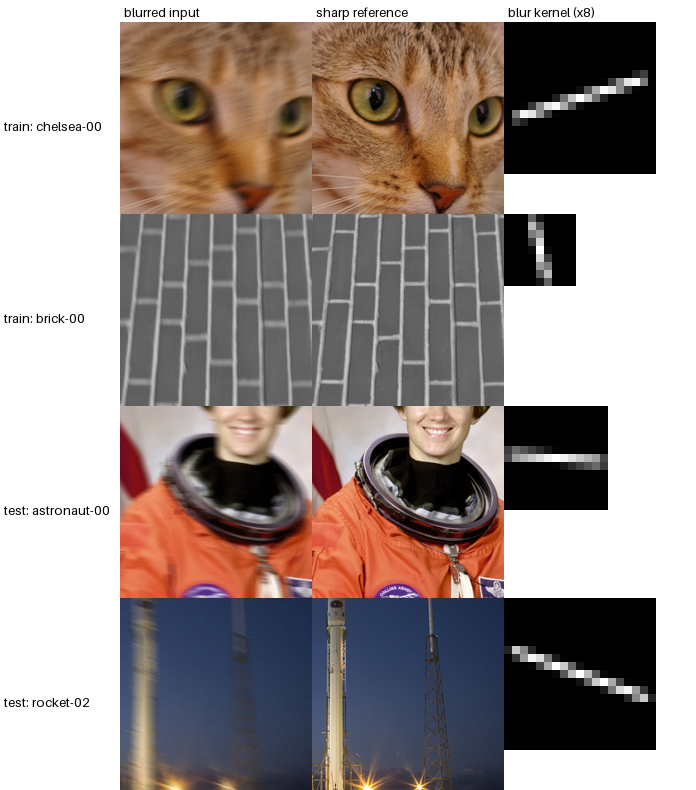

In [5]:
run_stage('prepare')
show_image('nafnet_deblurring_sample_pairs.png', 'Sample pairs: blurred input, sharp reference and the blur kernel')

**What to notice:** `disjoint_sources: True`; the five refusal probes — a pair whose two images differ in size, a 40 px image, a duplicate id, four pairs from one photograph, and a greyscale array where RGB is required — each name the rule they broke. These are the same messages a bad BYOD input produces in Section 10. `outputs/nafnet_deblurring_sample_pairs.csv` in the run directory lists every pair with its kernel and the licence of its photograph.

**Checkpoint:** a classmate proposes shuffling all 60 crops and taking 12 at random for test, "because that is how random splits work". What would that do to the test score in Section 7, and why does validation refuse four pairs from one photograph?

<details>
<summary>Check your reasoning (open after answering)</summary>

Crops of one photograph are not independent: they share the scene, its colours and textures. A shuffled split would put crops of the same photograph on both sides, and the fine-tuned model could score well on test partly because it has seen that scene — the test score would overstate how it does on a new photograph. Splitting by photograph keeps the test scenes unseen, which is the question that matters. Four pairs from one photograph cannot be split that way at all — there would be no photograph left for one side — so validation refuses them before any model runs. Validation is structural only: it cannot check that a pair shows the same scene or that the blur is motion blur.

</details>

## 5. Baselines and the pretrained model · [Evaluation practice]

**Question tested:** before any adaptation, how much does the pretrained NAFNet improve these held-out pairs, compared with doing nothing, a blind classical filter and a classical method that is told the true blur?

The `baseline` stage scores four methods on the 12 test pairs with the same two metrics.

- **PSNR** compares pixel values: 10·log10(255² / MSE) in dB over all pixels and channels, as in the upstream GoPro test configuration (RGB, no border crop). +1 dB means about 21 % less mean squared error.
- **SSIM** compares local structure — means, contrasts and correlations in 11 × 11 Gaussian windows — per RGB channel, averaged; 1 is identical. It can disagree with PSNR: a slightly shifted sharp edge loses PSNR but keeps much of its SSIM, and a smooth blurry image can have a decent PSNR and a poor SSIM. The upstream repository uses a 3-D SSIM variant, so these SSIM values are not comparable with its README table, and neither metric here reproduces that table.

The methods: **identity** (the blurred input itself — the floor); **unsharp masking** (blind; its radius and strength are chosen on the *training* pairs and then frozen); **Wiener deconvolution with the true kernel** (an *oracle*: it is given the exact blur, which a real deblurrer never knows; its noise setting is chosen on the training pairs); and the **pretrained NAFNet** (blind: it sees only the blurred image). Nothing is tuned on the test pairs.

**Predict before running:** rank the four methods by test PSNR. Will blind unsharp masking beat the blurred input? Will the blind network beat the oracle that knows the kernel?

Running stage 'baseline' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/baseline.log
{'unsharp_chosen_on_train': {'sigma': 3.0, 'amount': 0.25}, 'wiener_oracle_chosen_on_train': {'nsr': 0.03}}
{'method': 'identity', 'n': 12, 'psnr_db': 23.32, 'ssim': 0.6264}
{'method': 'unsharp', 'n': 12, 'psnr_db': 23.37, 'ssim': 0.6186}
{'method': 'wiener_oracle', 'n': 12, 'psnr_db': 25.18, 'ssim': 0.7134}
{'method': 'pretrained', 'n': 12, 'psnr_db': 26.13, 'ssim': 0.7711}
{'pretrained_vs_blurred_input': {'from': 'identity', 'to': 'pretrained', 'n': 12, 'psnr_gain_mean': 2.808, 'psnr_gain_min': -0.239, 'psnr_gain_max': 4.483, 'ssim_gain_mean': 0.145, 'records_improved_psnr': 11}}
{'comparison_sheet': '/content/outputs/nafnet_deblurring/832119f9a959/outputs/nafnet_deblurring_baselines.png', 'pretrained_inference_seconds_for_test_split': 0.74}
{'stage': 'baseline', 'status': 'ok', 'seconds': 22.3}
Test pairs: blurred input, unsharp, oracle Wiener, pretrained NAFN

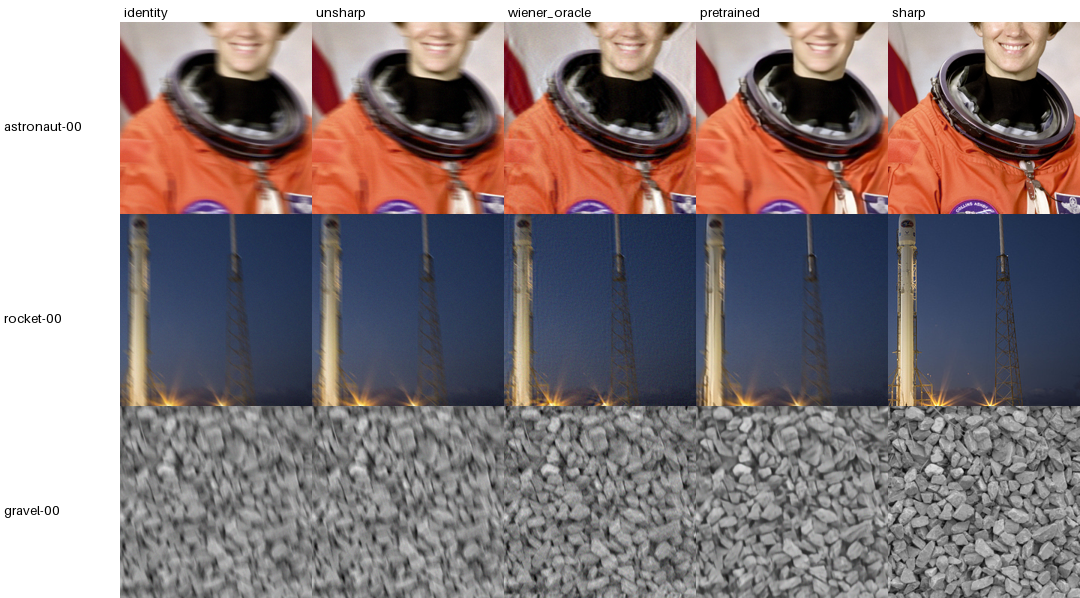

In [6]:
run_stage('baseline')
show_image('nafnet_deblurring_baselines.png', 'Test pairs: blurred input, unsharp, oracle Wiener, pretrained NAFNet and the sharp reference')

**What to notice:** the settings chosen on the training pairs; one line per method with its mean test PSNR and SSIM; and `pretrained_vs_blurred_input`, the per-pair PSNR gain of the pretrained network over the blurred input with its smallest and largest value and how many of the 12 pairs improved. Look at the sheet as well as the numbers: ringing (ripples near edges) is typical of Wiener deconvolution and of over-strong sharpening.

**Checkpoint:** unsharp masking usually stays at or below the blurred input in PSNR on this sample. Why can a filter that makes edges look crisper fail to improve PSNR, and why is the Wiener result called an *oracle* rather than a fair competitor?

<details>
<summary>Check your reasoning (open after answering)</summary>

Unsharp masking boosts the difference between an image and a blurred copy. It raises contrast at edges but does not move the light that motion blur smeared along the motion direction back to where it belongs, and it amplifies noise; PSNR counts every pixel's error, so the extra noise and overshoot can cost more than the edge contrast gains — which is why its strength had to be chosen on the training pairs and why it may still end below the identity on test. Wiener deconvolution inverts the blur in the frequency domain, but only because it is handed the exact kernel of each pair; a real photograph comes with no kernel, and estimating one is a hard problem of its own. It shows what a classical method can do with perfect knowledge, so a blind network that gets close to it, or beats it, is doing something useful; one that falls below it has room to improve. These numbers are 12 crops from 3 photographs: a tutorial measurement, not a benchmark.

</details>

## 6. Bounded fine-tuning of the decoder · [Concept]

The `adapt` stage always starts from the verified pretrained weights, so re-running this cell repeats the same experiment rather than continuing an earlier one. It updates only the parameters in `TRAINABLE_SCOPE` with gradient descent — this is ordinary fine-tuning of a parameter subset, not an adapter or PEFT method. With the default `decoder` scope the four upsampling layers, the four decoder blocks and the final convolution are trained (1,322,307 parameters, 7.7 % of 17,111,907); the intro convolution, the encoder (with its 28-block deepest level), the downsampling layers and the middle block stay frozen. Each step takes `BATCH_SIZE` random 256 × 256 crops of training pairs, each flipped or rotated at random, and minimises the upstream **PSNR loss** (10/ln 10 · mean log MSE, i.e. minus the batch PSNR) with AdamW (betas 0.9/0.9, no weight decay) at a fixed learning rate, in float32. The number of steps is fixed in advance: no model is selected on any split, so no validation split is needed and the test pairs are never used for a decision. The stage records reference outputs of the trained model while it is still in memory, then exports it as `outputs/nafnet_deblurring_artifact/` (`model.safetensors` + `manifest.json`).

**Predict before running:** will the training-batch PSNR rise smoothly from log line to log line? After 300 steps on 48 pairs, do you expect the held-out gain over the pretrained model (Section 7) to be large (several dB) or modest?

In [7]:
STEPS = 300  # @param {type:"integer"}
LEARNING_RATE = 1e-4  # @param {type:"number"}
BATCH_SIZE = 4  # @param {type:"integer"}
TRAINABLE_SCOPE = 'decoder'  # @param ["decoder", "decoder+middle", "all"]

run_stage('adapt', '--steps', STEPS, '--lr', LEARNING_RATE, '--batch-size', BATCH_SIZE, '--scope', TRAINABLE_SCOPE)

Running stage 'adapt' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/adapt.log
{'adaptation': 'gradient fine-tuning', 'scope': 'decoder', 'trainable_modules': ['ups', 'decoders', 'ending'], 'steps': 300, 'lr': 0.0001, 'batch_size': 4, 'seed': 0, 'device': 'cuda'}
{'step': 25, 'loss': -25.6601, 'train_batch_psnr_db': 25.66, 'seconds': 5.0}
{'step': 50, 'loss': -26.7476, 'train_batch_psnr_db': 26.75, 'seconds': 9.5}
{'step': 75, 'loss': -26.8591, 'train_batch_psnr_db': 26.86, 'seconds': 13.9}
{'step': 100, 'loss': -27.0327, 'train_batch_psnr_db': 27.03, 'seconds': 18.4}
{'step': 125, 'loss': -26.2118, 'train_batch_psnr_db': 26.21, 'seconds': 22.9}
{'step': 150, 'loss': -26.5507, 'train_batch_psnr_db': 26.55, 'seconds': 27.4}
{'step': 175, 'loss': -26.8727, 'train_batch_psnr_db': 26.87, 'seconds': 32.0}
{'step': 200, 'loss': -27.4211, 'train_batch_psnr_db': 27.42, 'seconds': 36.5}
{'step': 225, 'loss': -27.0043, 'train_batch_psnr_db': 27.0, 'seconds

**What to notice:** the configuration line; one log line every 25 steps with the mean PSNR loss and the equivalent training-batch PSNR in dB; the trainable, frozen and total parameter counts; the elapsed seconds; and the exported artifact with its SHA-256.

**Checkpoint:** why is a rising training-batch PSNR not evidence that the model deblurs better?

<details>
<summary>Check your reasoning (open after answering)</summary>

The training batches are crops of the six training photographs, which the model is being fitted to; a falling loss shows that the optimiser is working, not that the model generalises. It is also noisy: each log line averages 25 batches of different crops, kernels and orientations, and some crops are much harder than others, so the curve wobbles. Only the held-out comparison in Section 7, on photographs the model never trained on, speaks to quality — and even that only for this kind of synthetic blur. Freezing most of the network limits how far it can drift from the pretrained solution with only 48 pairs, which is a guard against overfitting, not a guarantee.

</details>

## 7. Held-out evaluation: the paired comparison · [Evaluation practice]

**Question tested:** on test pairs from photographs that played no part in training, does the adapted network restore better than the pretrained one and the classical baselines?

The `evaluate` stage is a fresh process: it loads the adapted network from the exported files — the artifact you would ship, not the object that was trained — after checking the manifest and the weights' SHA-256, and scores it on exactly the 12 pairs and with exactly the metrics of Section 5. Because every method sees the same inputs, a difference between two methods is a *paired* difference, not a re-draw of random data. The stage prints the full table, the per-pair gains (mean, smallest, largest, number of pairs improved) and the mean PSNR per test photograph.

**Predict before running:** will every one of the 12 pairs improve over the pretrained model, or only most? Which test photograph — the astronaut portrait, the rocket launch or the gravel texture — do you expect to gain least, and why?

Running stage 'evaluate' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/evaluate.log
{'method': 'identity', 'psnr_db': 23.32, 'ssim': 0.6264}
{'method': 'unsharp', 'psnr_db': 23.37, 'ssim': 0.6186}
{'method': 'wiener_oracle', 'psnr_db': 25.18, 'ssim': 0.7134}
{'method': 'pretrained', 'psnr_db': 26.13, 'ssim': 0.7711}
{'method': 'adapted', 'psnr_db': 26.36, 'ssim': 0.7881}
{'adapted_vs_pretrained': {'from': 'pretrained', 'to': 'adapted', 'n': 12, 'psnr_gain_mean': 0.227, 'psnr_gain_min': -0.165, 'psnr_gain_max': 0.417, 'ssim_gain_mean': 0.017, 'records_improved_psnr': 11}}
{'adapted_vs_identity': {'from': 'identity', 'to': 'adapted', 'n': 12, 'psnr_gain_mean': 3.035, 'psnr_gain_min': 0.079, 'psnr_gain_max': 4.755, 'ssim_gain_mean': 0.162, 'records_improved_psnr': 12}}
{'adapted_vs_wiener_oracle': {'from': 'wiener_oracle', 'to': 'adapted', 'n': 12, 'psnr_gain_mean': 1.179, 'psnr_gain_min': -0.178, 'psnr_gain_max': 2.473, 'ssim_gain_mean': 0.075, 'r

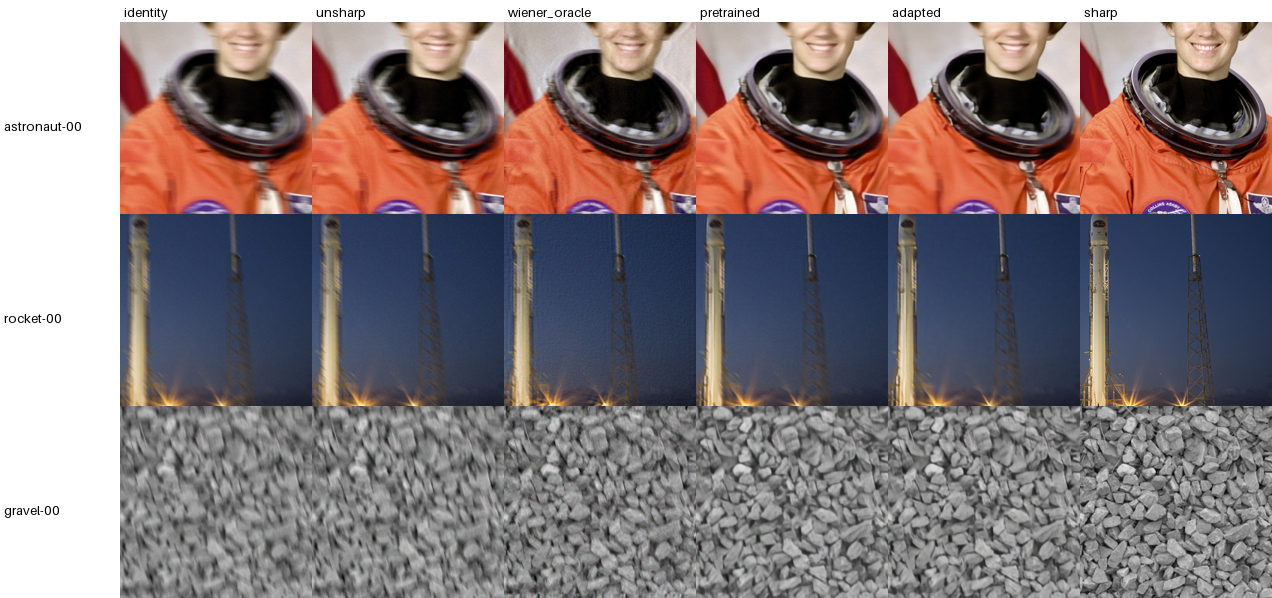

In [8]:
run_stage('evaluate')
show_image('nafnet_deblurring_evaluation.png', 'Test pairs: classical baselines, pretrained, adapted and the sharp reference')

**What to notice:** a table with five rows (identity, unsharp, wiener_oracle, pretrained, adapted) and `adapted_vs_pretrained`, the principal result: its mean, its range and how many of the 12 pairs improved. Compare the pretrained and adapted columns of the sheet: differences are often subtle at this size, so look at fine texture and straight edges. The full record is `outputs/nafnet_deblurring_evaluation_report.json` and the per-pair table `outputs/nafnet_deblurring_test_metrics.csv` in the run directory.

**Checkpoint:** write one sentence that reports the principal result honestly. What does it *not* tell you?

<details>
<summary>Check your reasoning (open after answering)</summary>

A defensible sentence has the form: "on 12 held-out 256-px crops from 3 photographs, with synthetic linear motion blur, fine-tuning the decoder for 300 steps changed mean PSNR from *a* dB (pretrained) to *b* dB, improving *k* of 12 pairs, against *c* dB for the blurred input and *d* dB for the oracle Wiener filter". It does not tell you how the model behaves on real camera blur, defocus or other noise levels, because the adaptation targeted exactly this synthetic distribution — gains here can come with losses on GoPro-like blur, which this notebook does not measure. It is one seeded run with no spread estimate; another seed would move the numbers a little. A photograph dominated by fine random texture (gravel) is the hardest to restore and often gains least, but read your own per-photograph line rather than assuming it.

</details>

## 8. Fresh reload and inference on new images · [Engineering]

The `reload` stage is a second fresh process. It verifies the artifact's manifest — format, model identity, the list of files (nothing more, nothing missing), the weights' size and SHA-256 and the upstream architecture digests — **before** reading the weights, rebuilds the network from the recorded architecture and loads them strictly. Nothing of the trained model survives in memory between processes, so this is a reload from files. It then compares the reloaded network's float outputs on two test pairs with the outputs the `adapt` stage recorded from the trained model while it was still in memory; the check passes only if the largest difference is at most 1e-5. *Loading* a file only shows that it parses; matching outputs show that the file reproduces the model.

Then both the pretrained and the reloaded adapted network deblur two images that played no part in adaptation or evaluation: `text-synthetic`, a printed-text image blurred with one fixed kernel (15 px at 30°), which has a sharp reference and so gets PSNR and SSIM; and `clock-real-motion`, a real photograph of a wall clock taken while moving the camera, which has **no** sharp reference. For it the stage reports only a *gradient-energy ratio* (how much stronger the restored image's edges are than the input's) — a sharpness proxy that noise and ringing also raise, never a quality score. Finally it writes `outputs/nafnet_deblurring_result.json` with the provenance, the runtime versions, the evaluation table and the reload check, and lists every file in `outputs/`.

**Predict before running:** will the reloaded artifact reproduce the trained model's outputs exactly, approximately, or not at all? On the real clock photograph, which model — pretrained on real camera blur, or adapted to synthetic straight-line blur — do you expect to look better?

**Expected result:** `artifact_manifest_verified: True`, a `reload_parity` dictionary whose `max_abs_float_diff` is at or near zero and within the tolerance, one line per new image, the listing of `outputs/`, and a sheet with the two images.

Running stage 'reload' in the isolated environment; log: /content/outputs/nafnet_deblurring/832119f9a959/logs/reload.log
{'artifact_manifest_verified': True, 'format': 'dimer_nafnet_restoration_artifact', 'base_checkpoint_sha256': '19394e6155d12ef6…', 'weights_sha256': '8d849bafeacdda1b…'}
{'reload_parity': {'records_compared': 2, 'max_abs_float_diff': 0.0, 'uint8_equal_fraction': 1.0, 'tolerance': 1e-05}}
{'id': 'text-synthetic', 'kind': 'paired (synthetic blur, fixed kernel)', 'size': [172, 448], 'blurred_input_psnr_db': 25.35, 'blurred_input_ssim': 0.6409, 'pretrained_psnr_db': 30.91, 'pretrained_ssim': 0.8239, 'adapted_psnr_db': 31.29, 'adapted_ssim': 0.8344}
{'id': 'clock-real-motion', 'kind': 'unpaired (real camera motion, no reference)', 'size': [300, 400], 'gradient_energy_ratio_pretrained': 1.081, 'gradient_energy_ratio_adapted': 0.807, 'note': 'no sharp reference: no PSNR/SSIM; the gradient-energy ratio is a sharpness proxy that noise and ringing also raise, not a quality sco

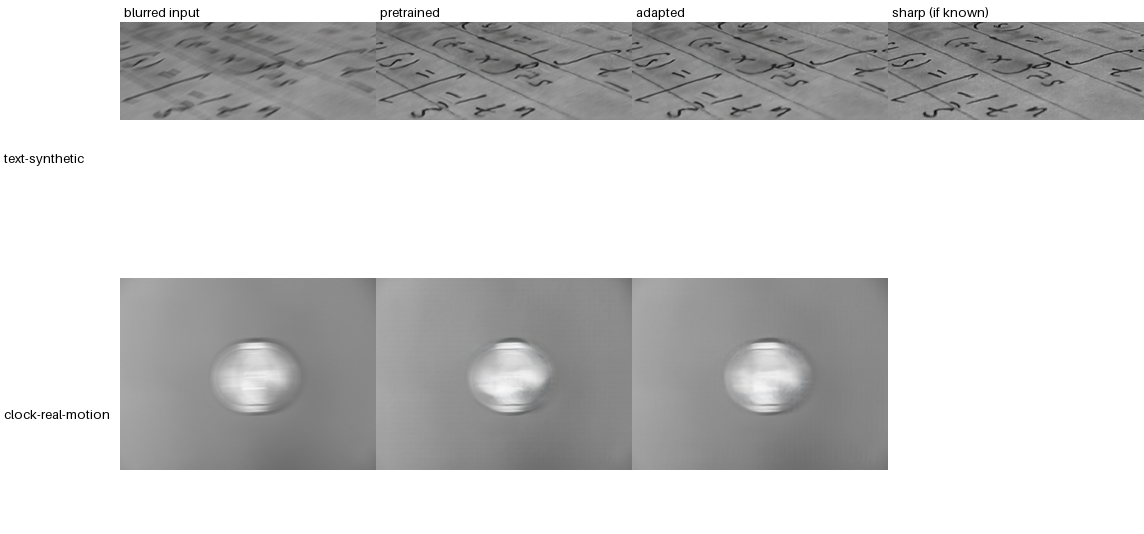

In [9]:
run_stage('reload')
show_image('nafnet_deblurring_new_images.png', 'New images: blurred input, pretrained, adapted and (if known) the sharp reference')

**What to notice:** the text image's PSNR for the blurred input, the pretrained and the adapted network — one image, so a sanity check, not an evaluation — and the clock photograph, where you must judge by eye. The real clock blur was not made by a straight-line kernel; compare how the pretrained (trained on real camera blur) and the adapted network (tuned to synthetic lines) handle it. This is the end of the canonical path; everything it produced is in `outputs/`.

**Checkpoint:** why is there no PSNR for the clock photograph, and why would a higher gradient-energy ratio not prove that one model restored it better?

<details>
<summary>Check your reasoning (open after answering)</summary>

PSNR and SSIM compare an output with the true sharp image. For a real blurred photograph nobody has that image, so any full-reference number would be invented. Gradient energy only measures how strong the edges are: amplified noise, ringing or over-sharpened halos raise it as much as genuinely restored detail does, so a model can increase it while making the image worse. Judging real blur needs a reference capture (a tripod shot, or a paired dataset such as GoPro), a no-reference metric validated for the task, or human rating — none of which this notebook provides.

</details>

## 9. Optional activity: change one thing — the trainable scope · [Concept]

**Predict → Change one thing → Run → Observe → Explain.** This activity is off by default and changes nothing the canonical path produced: with `RUN_ACTIVITY = False` the next cell only prints how to switch it on. It runs the `activity` stage, which starts again from the verified pretrained weights (never from the adapted model), fine-tunes with exactly the steps, learning rate, batch size and seed of Section 6 but a different `ACTIVITY_SCOPE`, scores the result on the same 12 test pairs, and prints it beside the Section 6 result. It exports no artifact. On a CPU-only runtime it takes as long as Section 6 or longer.

**Change one thing:** set `ACTIVITY_SCOPE` to `all` (all 17.1 M parameters) or `decoder+middle` (adds the middle block, 3.2 M trainable in total) and `RUN_ACTIVITY = True`, then run the cell.

**Predict before running:** with sixteen times as many trainable parameters (`all`), will the held-out PSNR be higher, about the same, or lower than with the decoder alone? Will training take much longer? Write your prediction down.

In [10]:
RUN_ACTIVITY = False  # @param {type:"boolean"}
ACTIVITY_SCOPE = 'all'  # @param ["decoder", "decoder+middle", "all"]

if RUN_ACTIVITY:
    run_stage('activity', '--scope', ACTIVITY_SCOPE)
else:
    print({'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and choose ACTIVITY_SCOPE, then run this cell'})

{'activity': 'skipped (optional)', 'to_run': 'set RUN_ACTIVITY = True and choose ACTIVITY_SCOPE, then run this cell'}


**Observe:** three rows — the pretrained model, the Section 6 adaptation and the activity's — each with test PSNR, SSIM, trainable parameters, training seconds and the first logged loss (which should be close for both adaptations, showing that both started from the same weights).

**Explain:** did the result match your prediction? What does it suggest about how much of the network needs to change to adapt to a new blur distribution?

<details>
<summary>Check your reasoning (open after answering)</summary>

Training every parameter gives the optimiser more freedom: on a distribution shift like this one it can fit the new blur more closely, so held-out PSNR often rises somewhat — but with only 48 training pairs from six photographs it can also start to fit those scenes, and the backward pass through the 28-block encoder costs more memory and time. The decoder-only scope keeps the encoder's features fixed and changes how they are turned back into an image, which is cheaper and changes the pretrained model less. Either outcome is an observation about one seeded run on 12 test pairs; a difference of a few hundredths of a dB is within what a different seed could produce. Because only the scope changed, any difference is caused by it.

</details>

## 10. Bring your own data (optional) · [Engineering]

Off by default; with `USE_BYOD = False` the next cell only prints how to switch it on. The `byod` stage uses the same validation, metrics, baselines, fine-tuning, artifact format and reload check as the canonical path.

**Input contract (read before choosing files).** A zip archive (or, with `BYOD_PATH`, a zip or a directory already in the runtime) containing either

- **paired data:** a folder `sharp/` and a folder `blurred/`, with each pair stored under the same file name in both (for example `sharp/street_01.png` and `blurred/street_01.png`); at least 4 and at most 200 pairs, from at least 2 different scenes; or
- **unpaired data:** blurred images only, in `blurred/` or at the top level of the zip; 1..200 images.

Images are PNG, JPEG, BMP, TIFF or WebP, 8-bit, each side 64..1024 px (larger images are refused with a message — resize or crop them first); both images of a pair must have the same size; paired fine-tuning uses crops of up to 256 px, so the training images should be at least that large. One wrapping folder is tolerated; other folders, duplicate names, unmatched files, absolute or `..` paths and symbolic links are refused with a message naming the file. Members of the zip are read in memory; nothing is extracted to disk outside the run directory.

**Paired mode** splits *by image* with a fixed seed (one in four images, at least one, goes to test — the split assumes your images are independent scenes), tunes the unsharp baseline on your training images, scores the identity, unsharp and pretrained baselines (no oracle Wiener: your kernels are unknown), fine-tunes from the pretrained weights for `BYOD_STEPS` steps with the Section 6 settings, exports its own artifact, reloads it with the equivalence check, and writes the artifact, the restored test images, `byod_test_metrics.csv` and `byod_result.json` to `outputs/byod/<mode>-<archive digest>/`, one directory per archive, so a second BYOD run never overwrites an earlier one. **Unpaired mode** deblurs every image with the pretrained model and, if Section 6 ran, the adapted sample model, and writes the PNGs and `byod_result.json`; it reports no PSNR or SSIM because there is no reference.

**Privacy:** your files stay in this runtime and are sent nowhere. Do not upload confidential, personal or regulated images unless you are authorized to process them in this environment. Leave `BYOD_PATH` empty to get the Colab upload dialog; set it to a path to skip the dialog (it works outside Colab too).

In [11]:
from pathlib import Path

USE_BYOD = False  # @param {type:"boolean"}
BYOD_PATH = ''  # @param {type:"string"}
BYOD_STEPS = 300  # @param {type:"integer"}

if USE_BYOD:
    if BYOD_PATH:
        byod_path = Path(BYOD_PATH)
    else:
        from google.colab import files
        uploaded = files.upload()
        file_name, payload = next(iter(uploaded.items()))
        byod_path = ROOT / 'byod_upload' / Path(file_name).name
        byod_path.parent.mkdir(parents=True, exist_ok=True)
        byod_path.write_bytes(payload)
    run_stage('byod', '--byod', byod_path.resolve(), '--steps', BYOD_STEPS, '--lr', LEARNING_RATE, '--batch-size', BATCH_SIZE, '--scope', TRAINABLE_SCOPE)
else:
    print({'byod': 'skipped (optional)', 'to_run': 'set USE_BYOD = True; optionally set BYOD_PATH to a zip or directory already in the runtime'})

{'byod': 'skipped (optional)', 'to_run': 'set USE_BYOD = True; optionally set BYOD_PATH to a zip or directory already in the runtime'}


**What to notice:** `byod_mode` (`paired` or `unpaired`), the validation summary and any colour conversions; for paired data the split, the baseline lines, the training log, the comparison table with `adapted_vs_pretrained`, and the reload check; for unpaired data one line per image with gradient-energy ratios. An invalid archive stops the cell with a `RuntimeError` that repeats the validator's message — for example a file without a partner, a pair whose sizes differ, or an image larger than 1024 px. With very few test images the metrics describe those images only.

## Troubleshooting · [Engineering]

| Symptom | Likely cause | What to do |
|---|---|---|
| Section 1 prints `No CUDA GPU detected` | the runtime has no GPU | The notebook still completes on the CPU, more slowly. For the documented runtime choose *Runtime → Change runtime type → T4 GPU* and run all again from the top. If Colab offers no GPU, your quota may be exhausted. |
| Section 1 stops with `This notebook needs a Linux x86_64 runtime` | a local Windows or macOS kernel, or an ARM machine | Use Google Colab, Kaggle, or a Linux x86_64 machine: the locked environment is built for manylinux x86_64 wheels. |
| Section 1 stops with `Not enough free disk` | the isolated environment needs about 9 GB | Start a fresh runtime with more free disk. |
| `Carried file integrity failure` in Section 2, or `carried upstream file … sha256 … != pinned` in a stage | a carried file was edited | Do not edit the infrastructure cells; open a fresh copy of the notebook from the repository. |
| `uv 0.12.15 wheel size/hash mismatch`, or a `URLError` / timeout while downloading it | a network failure or an unexpected response from PyPI | Re-run the Section 2 install cell. Never replace the pinned URL or digest. |
| `CalledProcessError` from `uv venv` or `uv pip install` (a hash mismatch, `Failed to download`, HTTP 5xx) | a transient PyPI or network failure | Re-run the Section 2 install cell: `uv` reuses what it already downloaded. If a hash mismatch repeats, stop and report it — never remove `--require-hashes`, a pin or a hash. |
| `DeprecationWarning: 'saved_variables' is deprecated; use 'saved_tensors'` in a stage log | the carried upstream `arch_util.py` uses an older PyTorch name that still works in torch 2.14 | Nothing: the warning is harmless and the carried file is kept verbatim on purpose. |
| `RuntimeError: Stage '…' failed (exit 2): …` | the stage raised an error; the text after the colon is the stage's own message, and its full log is printed above and kept in the run directory's `logs/` | Find the message in the rows below. A stage reads only files, so after fixing the cause you can re-run that cell and the cells after it. |
| `no mirror delivered the pinned checkpoint bytes` | the mirrors were unreachable, or served different bytes | Re-run the Section 3 cell later. If the message shows a different SHA-256, the mirror changed: the notebook correctly refuses it; report it rather than editing the digest. |
| `… is missing: run the stage that writes it before …` | a learner cell was run before an earlier stage | Run the notebook from the top, or re-run the earlier cells in order. |
| `the sample changed since 'prepare'` | the sample photographs or the package changed after Section 4 | Re-run from Section 4. |
| `CUDA out of memory` | `BATCH_SIZE` was raised, the `all` scope was chosen on a small GPU, or another program holds GPU memory | Lower `BATCH_SIZE` (for example to 2) and re-run that cell; each stage is its own process, so the failed stage's memory was released. |
| `reloaded artifact differs from the trained model` | the artifact files were modified, or a nondeterministic kernel was used | Re-run Section 6 and Section 8; report it if it repeats. |
| `ModuleNotFoundError: No module named 'google.colab'` with `USE_BYOD = True` | the upload dialog needs Google Colab | Set `BYOD_PATH` to a zip or directory already in the runtime, or use Colab. |
| `BYOD: files without a partner …` or `… is not in sharp/ or blurred/` | the archive layout differs from the contract | Put pairs in `sharp/` and `blurred/` under identical file names; Section 10 gives an example. |
| `… each side must be within 64..1024 px` or `blurred is … but sharp is …` | an image is too small or too large, or a pair's sizes differ | Resize or crop the images; both images of a pair must have identical size. |
| `at least 2 distinct sources are needed` or `4..200 are required` | too few paired images | Provide at least four pairs from at least two scenes. |

## Interpretation and limits · [Evaluation practice]

The question this notebook can answer is narrow: does fine-tuning the decoder half of a GoPro-trained NAFNet for a few hundred steps on 48 synthetic motion-blur pairs improve PSNR and SSIM on 12 pairs from three unseen photographs with the same kind of blur, compared with the pretrained model, the blurred input, a blind classical filter and a classical oracle? Your run answers it in Section 7 on identical inputs; read the direction and size of each difference there rather than from this text.

The numbers are sample-sanity evidence. The blur is synthetic (straight-line kernels, Gaussian noise, no camera response curve, no compression), the test set is 12 crops from 3 photographs with no dispersion estimate, the oracle baseline knows what no real method knows, and PSNR/SSIM do not measure perceived quality. Adapting to synthetic lines can make the model worse on real camera blur — Section 8's clock photograph is one visual hint, not a measurement. None of this reproduces or tests the upstream GoPro results.

Three things to carry to real data. **The reference defines the metric:** without a sharp image, PSNR and SSIM cannot be computed, so real deployments need paired captures or human rating. **Split by scene, not by crop:** crops of one photograph share content and leak across a random split. **The trust boundary is the digest:** the checkpoint is a pickle; it is safe to load here only because its exact bytes are pinned and read with `weights_only=True`, and the exported artifact is safetensors.

Successful execution proves that the recorded repository revision's modules, the verbatim upstream architecture and the stage runner, carried in this standalone notebook and run in an isolated hash-locked environment, can fetch and digest-verify the pinned checkpoint, convert it to safetensors with identical outputs, build and validate the sample, score classical baselines and the pretrained network, execute a bounded fine-tuning, evaluate the exported artifact on held-out pairs, reload it in a fresh process with output equivalence and emit the shown machine-readable artifacts — without the repository being reachable. It does **not** establish benchmark superiority, production fitness, or restoration quality on real blur.

## Conclude with evidence · [Evaluation practice]

Complete this in your own words, using the numbers your run printed:

> On [12 held-out 256-px crops from three photographs with synthetic linear motion blur / your BYOD test images], fine-tuning NAFNet-GoPro-width32 ([scope], [steps] steps, [trainable] of 17,111,907 parameters) changed mean test PSNR from [pretrained] dB to [adapted] dB and SSIM from [pretrained] to [adapted], improving [k] of [n] pairs. The blurred input scored [identity] dB, unsharp masking [unsharp] dB and the oracle Wiener filter, which was given the true kernels, [wiener] dB. The most important uncertainty is [for example: one seeded run on 12 crops; synthetic blur only; the hardest photograph]. These numbers do not show [behaviour on real camera blur / perceived quality / ...]. Next I would [specific next experiment].

<details>
<summary>Check your reasoning: what makes a conclusion strong? (open after writing yours)</summary>

A strong conclusion names the data (how many held-out pairs, from how many photographs, which blur), reports the pretrained model and the baselines beside the adapted number, and says how many pairs improved rather than only the mean. It says what the oracle knows, keeps the training loss out of the evidence, and limits the claim to synthetic linear motion blur. It ends with a specific next step — several seeds, more test photographs, a real paired blur dataset, or checking the adapted model on GoPro-like blur for regressions. A weak conclusion says only that "fine-tuning improved deblurring".

</details>

**Transfer:** switch on BYOD (Section 10) with paired images from your own camera — for example a tripod shot and a handheld shot of the same still scene, aligned and cropped to the same size — and write the same conclusion for them. Before running, predict whether the adapted sample model or the pretrained model will do better on real camera blur, and why.

## References

- Repository README: https://github.com/kurtvalcorza/nafnet-deblurring-pipeline/blob/main/README.md
- Repository model card: https://github.com/kurtvalcorza/nafnet-deblurring-pipeline/blob/main/MODEL_CARD.md
- Weights provenance and trust gap: https://github.com/kurtvalcorza/nafnet-deblurring-pipeline/blob/main/docs/WEIGHTS.md
- Upstream repository: https://github.com/megvii-research/NAFNet (revision `2b4af71ebe098a92a75910c233a3965a3e93ede4`)
- Checkpoint mirror: https://huggingface.co/nyanko7/nafnet-models (file `NAFNet-GoPro-width32.pth`, accepted only at the pinned SHA-256)
- Chen, L., Chu, X., Zhang, X., & Sun, J. (2022). Simple baselines for image restoration. ECCV 2022. https://doi.org/10.1007/978-3-031-20071-7_2
- Chu, X., Chen, L., Chen, C., & Lu, X. (2022). Improving image restoration by revisiting global information aggregation (TLC). ECCV 2022. https://doi.org/10.1007/978-3-031-20071-7_4
- Nah, S., Kim, T. H., & Lee, K. M. (2017). Deep multi-scale convolutional neural network for dynamic scene deblurring (GoPro dataset). CVPR 2017. https://doi.org/10.1109/CVPR.2017.35
- Wang, Z., Bovik, A. C., Sheikh, H. R., & Simoncelli, E. P. (2004). Image quality assessment: From error visibility to structural similarity. IEEE TIP, 13(4), 600–612. https://doi.org/10.1109/TIP.2003.819861
- van der Walt, S., et al. (2014). scikit-image: Image processing in Python. PeerJ, 2, e453 (the sample photographs). https://doi.org/10.7717/peerj.453
- uv (the installer that builds the isolated environment): https://docs.astral.sh/uv/
- DIMER Notebook Specification 2.2 and Model Card Specification 1.2 (in the ml-worker repository)